In [1]:
from inference import EvaluateModelOnnx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [173]:
def plot_all_metrics_single_figure(df):
    metrics = ["Precision", "Recall", "F1"]
    frequencies = ["LowerLow","Low","Medium","High","Random"]
    attacks = ["DoS","Fuzz","Replay"]

    colors = {"DoS":"tab:red","Fuzz":"tab:blue","Replay":"tab:green"}

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(8, 8),
        sharex=True
    )

    x = np.arange(len(frequencies))
    width = 0.22

    for ax, metric in zip(axes, metrics):
        for i, attack in enumerate(attacks):
            subset = (
                df[(df["Metric"] == metric) & (df["Attack"] == attack)]
                .set_index("Frequency")
                .loc[frequencies]
            )

            y = subset["Value"].values
            yerr = [
                y - subset["CI_L"].values,
                subset["CI_H"].values - y
            ]

            ax.errorbar(
                x + (i - 1) * width,
                y,
                yerr=yerr,
                fmt='o',
                capsize=7,
                color=colors[attack],
                markersize=5,
                label=attack if metric == "Precision" else None
            )

        ax.set_ylabel(metric, fontsize=16, fontweight="bold")
        ax.set_ylim(0.82, 1.01)
        ax.grid(True, linestyle="--", alpha=0.75)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(frequencies, fontsize=15, fontweight="bold")
    axes[-1].set_xlabel("Attack Frequency", fontsize=16, fontweight="bold")

    # ---- get handles from Precision axis ----
    handles, labels = axes[0].get_legend_handles_labels()

    # ---- place legend on Recall axis ----
    legend = axes[1].legend(
        handles,
        labels,
        title="Attack Type",
        fontsize=15,
        frameon=True,
        loc="lower right",
        prop={"weight": "bold"}
    )

    legend.get_title().set_fontweight("bold")
    legend.get_title().set_fontsize(15)

    plt.tight_layout()
    # plt.savefig("ids_all_metrics_ci.pdf", bbox_inches="tight")
    plt.savefig("ids_all_metrics_ci.png", dpi=1000, bbox_inches="tight")
    plt.show()

## Tran on Kia

## Test on Tesla DoS

In [3]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainKiaOnnx"
TIME_GAP = 83.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:03<00:00, 13.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.8986  (95% CI: 0.8759, 0.9176)
Precision: 0.8626  (95% CI: 0.8235, 0.8942)
Recall   : 0.9075  (95% CI: 0.8724, 0.9337)
F1-score : 0.8845  (95% CI: 0.8579, 0.9076)


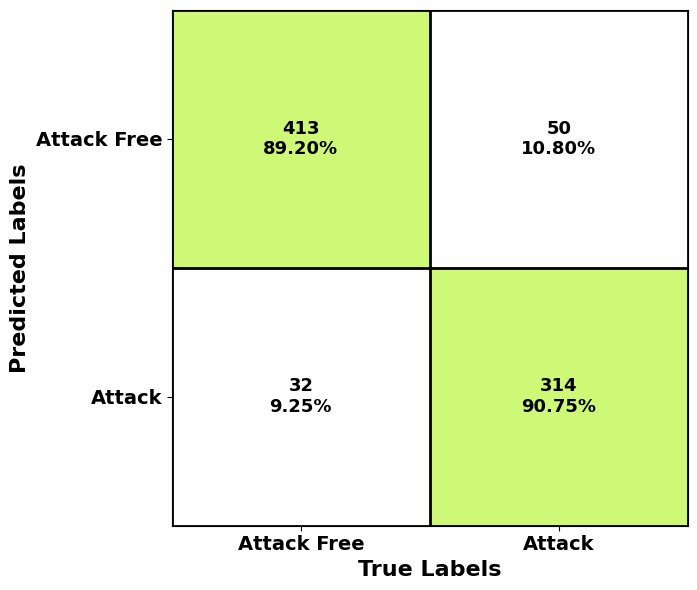

In [4]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:06<00:00,  3.22s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.23it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


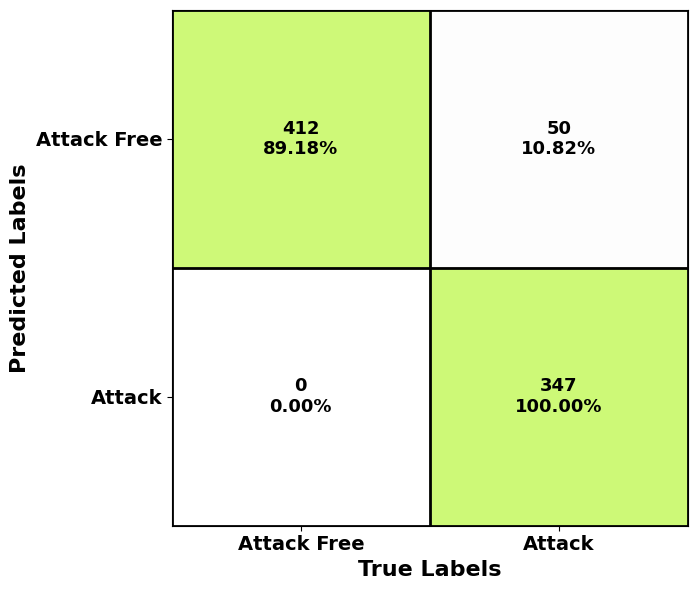

In [5]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:03<00:00,  1.74s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


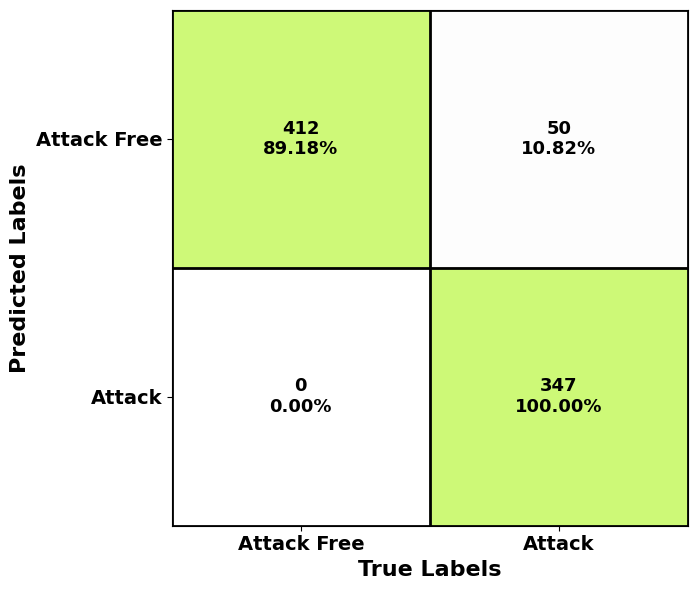

In [6]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:08<00:00,  4.42s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


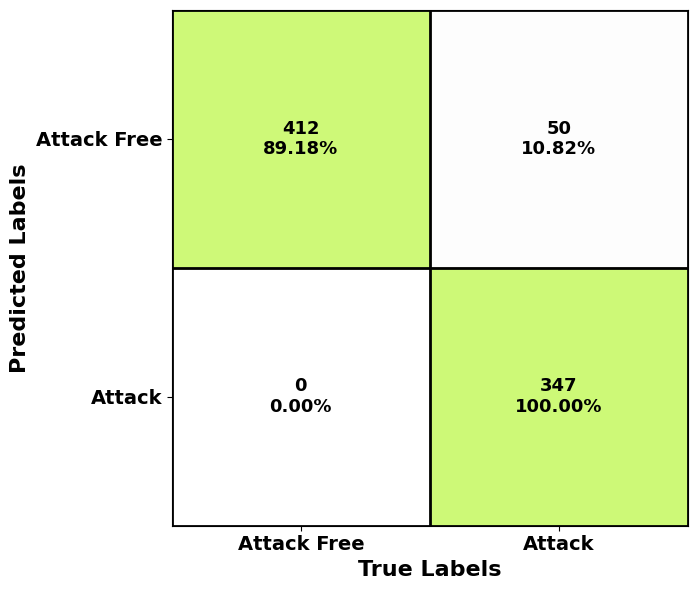

In [7]:
DATA_DIR = "Split_data/Test/Tesla/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)



--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.39s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9135, 0.9507)


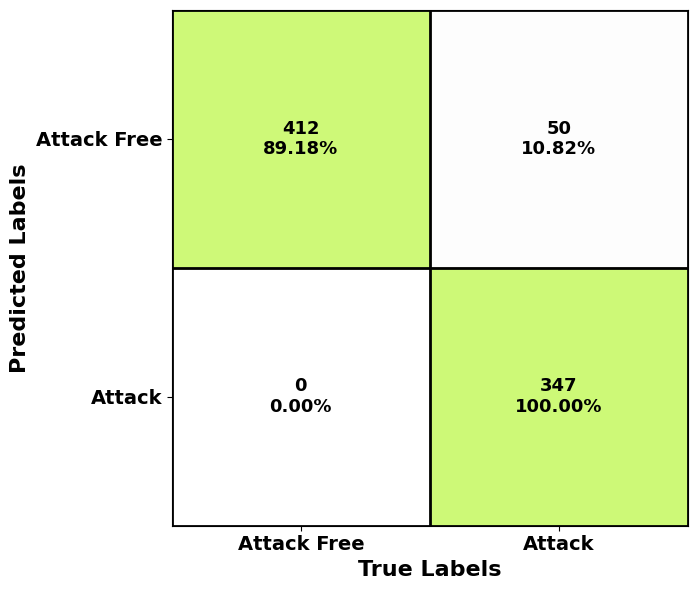

In [8]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


## Test on Tesla Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.82s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9308  (95% CI: 0.9112, 0.9463)
Precision: 0.8718  (95% CI: 0.8350, 0.9014)
Recall   : 0.9827  (95% CI: 0.9627, 0.9920)
F1-score : 0.9239  (95% CI: 0.9038, 0.9427)


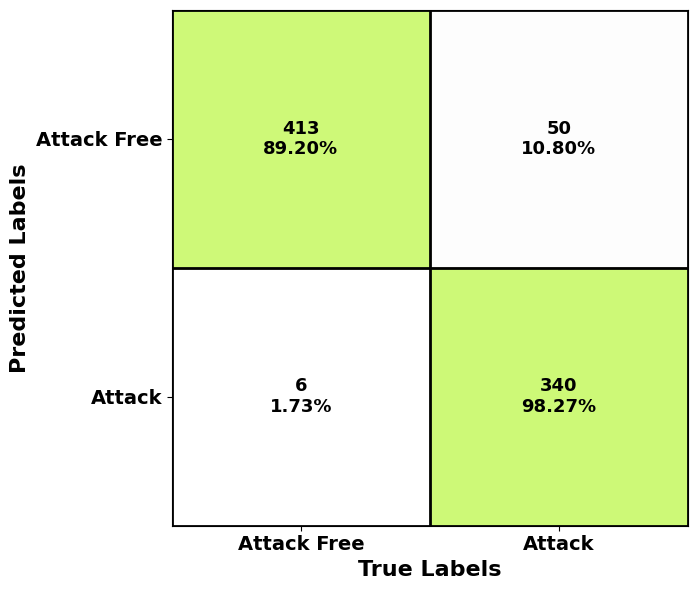

In [9]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.27s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9370  (95% CI: 0.9181, 0.9517)
Precision: 0.8737  (95% CI: 0.8374, 0.9029)
Recall   : 0.9971  (95% CI: 0.9839, 0.9995)
F1-score : 0.9314  (95% CI: 0.9125, 0.9493)


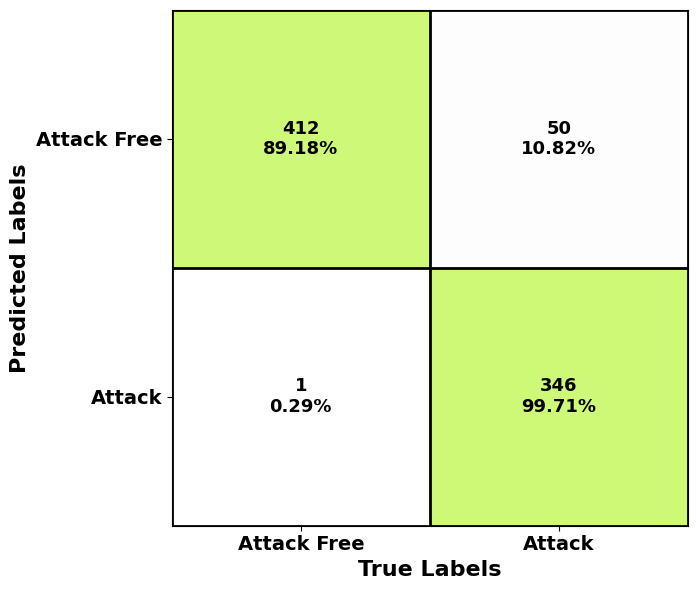

In [10]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:03<00:00,  1.86s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


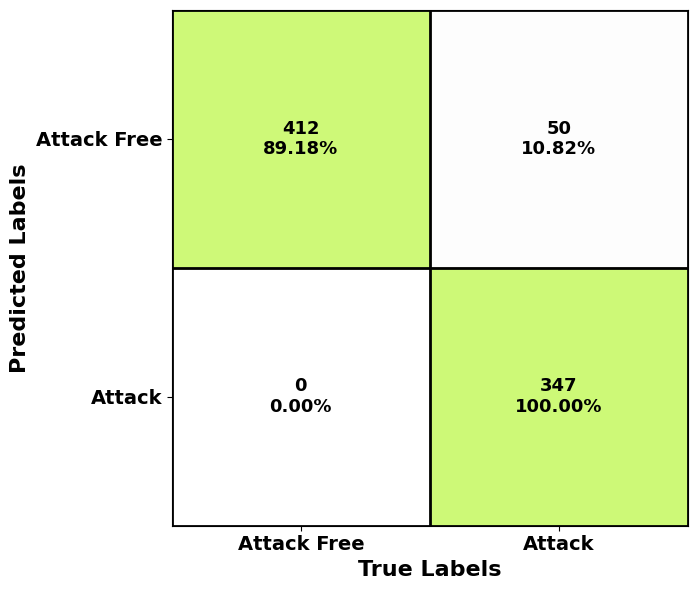

In [11]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.66s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


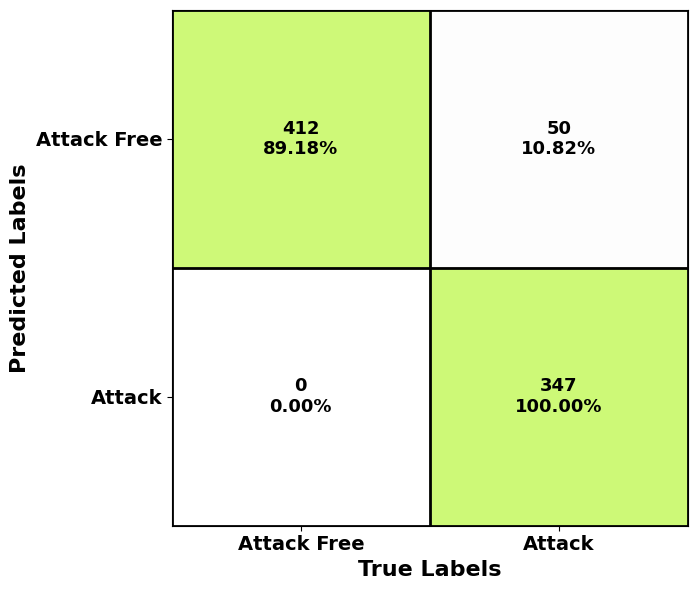

In [12]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:07<00:00,  3.57s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


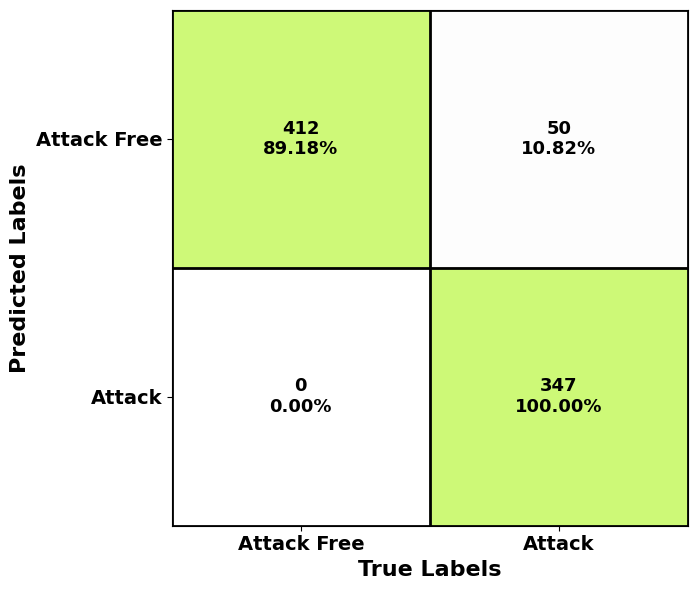

In [13]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Test on Tesla Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:06<00:00,  3.38s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.24it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8737  (95% CI: 0.8374, 0.9029)
Recall   : 1.0000  (95% CI: 0.9890, 1.0000)
F1-score : 0.9326  (95% CI: 0.9139, 0.9503)


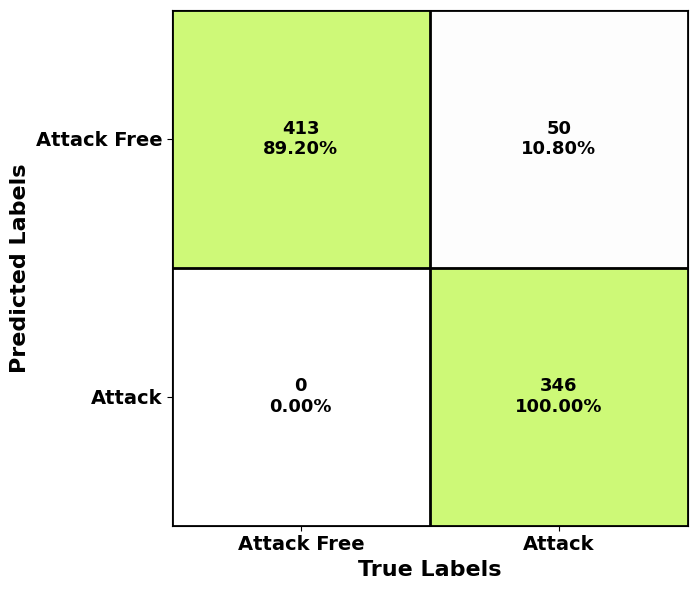

In [14]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.25s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.19it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


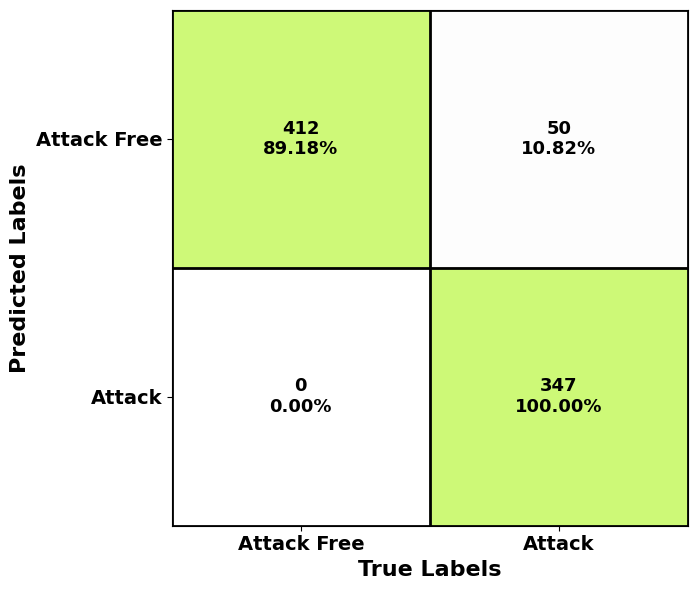

In [15]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.19s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.19it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


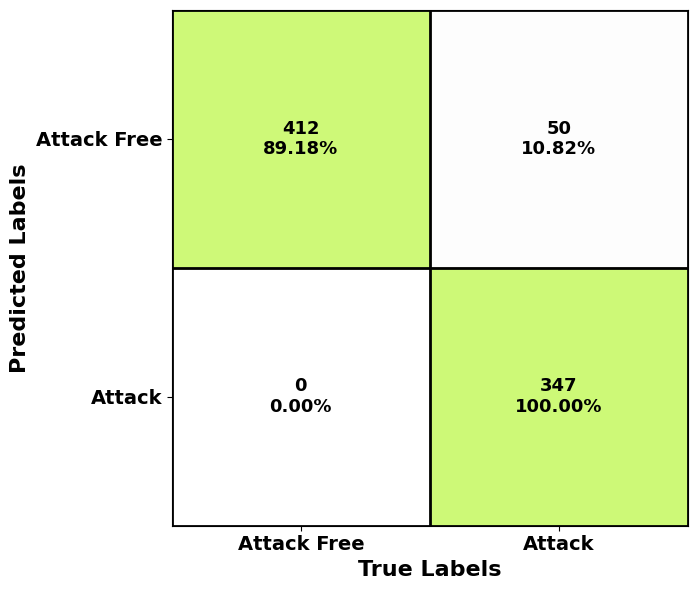

In [16]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:04<00:00,  2.38s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.18it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


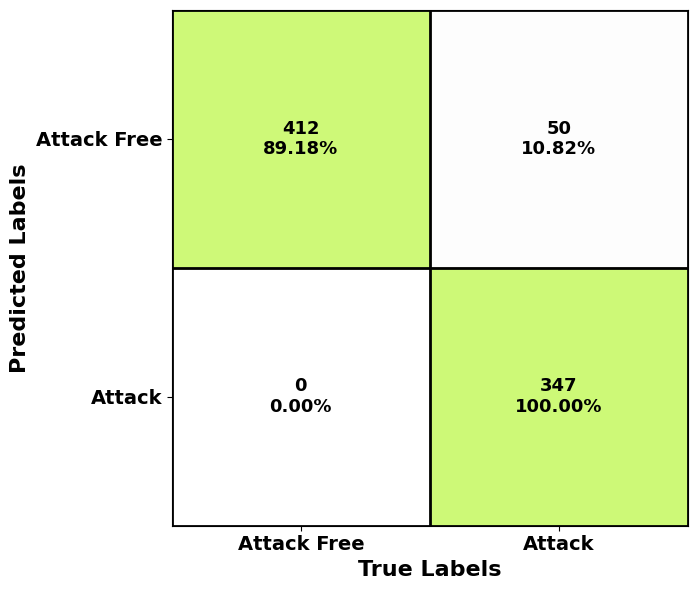

In [17]:
DATA_DIR = "Split_data/Test/Tesla/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:05<00:00,  2.68s/it]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8741  (95% CI: 0.8378, 0.9031)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9328  (95% CI: 0.9143, 0.9505)


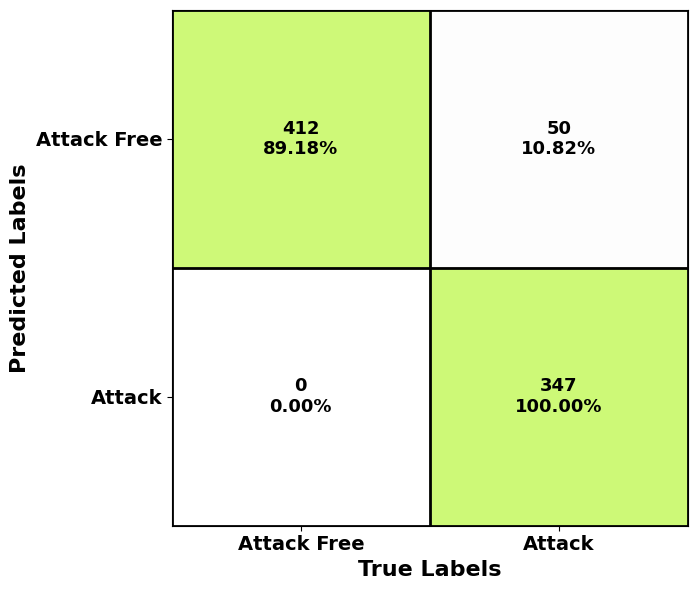

In [18]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

In [101]:
df = pd.DataFrame([
    # Attack, Frequency, Metric, Value, CI_low, CI_high

    # ---- DoS ----
    ("DoS","LowerLow","Precision",0.8626,0.8235,0.8942),
    ("DoS","LowerLow","Recall",0.9075,0.8724,0.9337),
    ("DoS","LowerLow","F1",0.8845,0.8579,0.9076),

    ("DoS","Low","Precision",0.8741,0.8378,0.9031),
    ("DoS","Low","Recall",1.0000,0.9891,1.0000),
    ("DoS","Low","F1",0.9328,0.9135,0.9507),

    ("DoS","Medium","Precision",0.8741,0.8378,0.9031),
    ("DoS","Medium","Recall",1.0000,0.9891,1.0000),
    ("DoS","Medium","F1",0.9328,0.9143,0.9505),

    ("DoS","High","Precision",0.8741,0.8378,0.9031),
    ("DoS","High","Recall",1.0000,0.9891,1.0000),
    ("DoS","High","F1",0.9328,0.9135,0.9507),

    ("DoS","Random","Precision",0.8741,0.8378,0.9031),
    ("DoS","Random","Recall",1.0000,0.9891,1.0000),
    ("DoS","Random","F1",0.9328,0.9135,0.9507),

    # ---- Fuzz ----
    ("Fuzz","LowerLow","Precision",0.8718,0.8350,0.9014),
    ("Fuzz","LowerLow","Recall",0.9827,0.9627,0.9920),
    ("Fuzz","LowerLow","F1",0.9239,0.9038,0.9427),

    ("Fuzz","Low","Precision",0.8737,0.8374,0.9029),
    ("Fuzz","Low","Recall",0.9971,0.9839,0.9995),
    ("Fuzz","Low","F1",0.9314,0.9125,0.9493),

    ("Fuzz","Medium","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","Medium","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","Medium","F1",0.9328,0.9143,0.9505),

    ("Fuzz","High","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","High","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","High","F1",0.9328,0.9143,0.9505),

    ("Fuzz","Random","Precision",0.8741,0.8378,0.9031),
    ("Fuzz","Random","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","Random","F1",0.9328,0.9143,0.9505),

    # ---- Replay ----
    ("Replay","LowerLow","Precision",0.8737,0.8374,0.9029),
    ("Replay","LowerLow","Recall",1.0000,0.9890,1.0000),
    ("Replay","LowerLow","F1",0.9326,0.9139,0.9503),

    ("Replay","Low","Precision",0.8741,0.8378,0.9031),
    ("Replay","Low","Recall",1.0000,0.9891,1.0000),
    ("Replay","Low","F1",0.9328,0.9143,0.9505),

    ("Replay","Medium","Precision",0.8741,0.8378,0.9031),
    ("Replay","Medium","Recall",1.0000,0.9891,1.0000),
    ("Replay","Medium","F1",0.9328,0.9143,0.9505),

    ("Replay","High","Precision",0.8741,0.8378,0.9031),
    ("Replay","High","Recall",1.0000,0.9891,1.0000),
    ("Replay","High","F1",0.9328,0.9143,0.9505),

    ("Replay","Random","Precision",0.8741,0.8378,0.9031),
    ("Replay","Random","Recall",1.0000,0.9891,1.0000),
    ("Replay","Random","F1",0.9328,0.9143,0.9505),
], columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"])

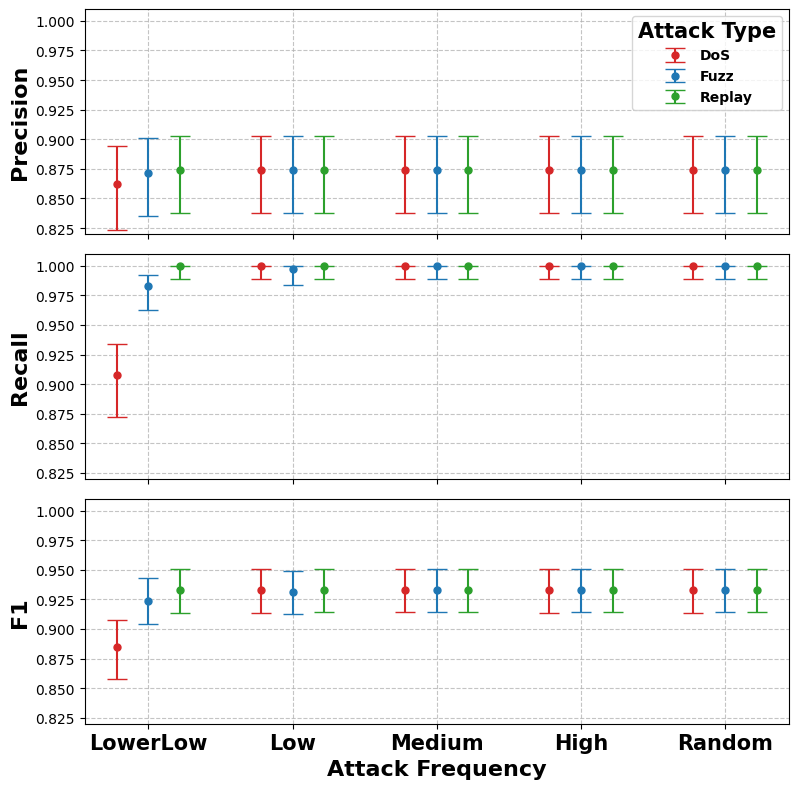

In [102]:
plot_all_metrics_single_figure(df)

## Test on Tesla Gennesis

## DoS

In [33]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainKiaOnnx"
TIME_GAP = 105.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.51it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.01it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9458  (95% CI: 0.9278, 0.9595)
Precision: 0.9685  (95% CI: 0.9429, 0.9828)
Recall   : 0.9029  (95% CI: 0.8668, 0.9301)
F1-score : 0.9346  (95% CI: 0.9144, 0.9527)


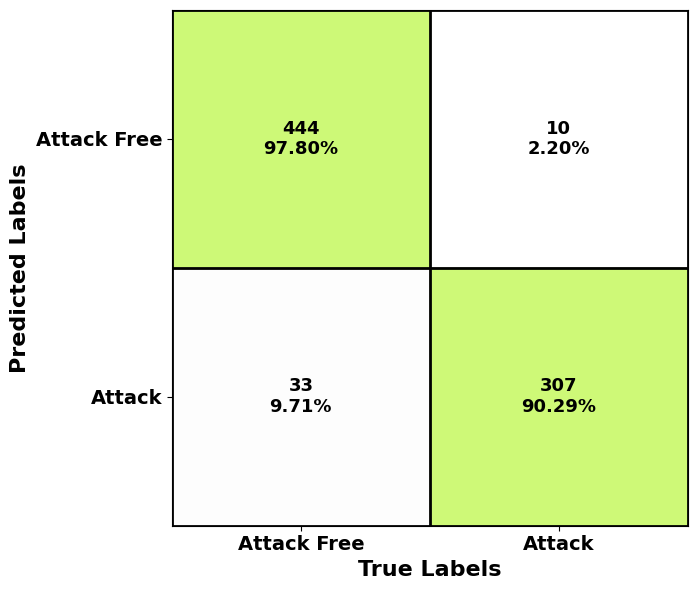

In [34]:
DATA_DIR = "Split_data/Test/Gen/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.47it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


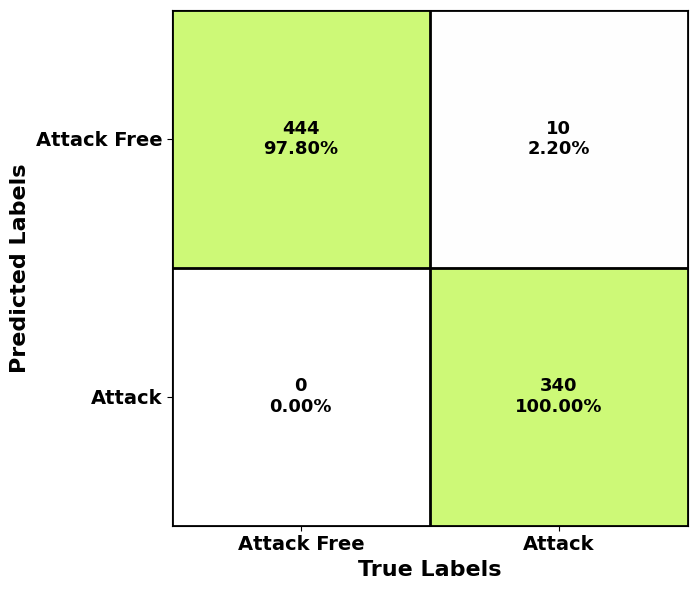

In [35]:
DATA_DIR = "Split_data/Test/Gen/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.24it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.95it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


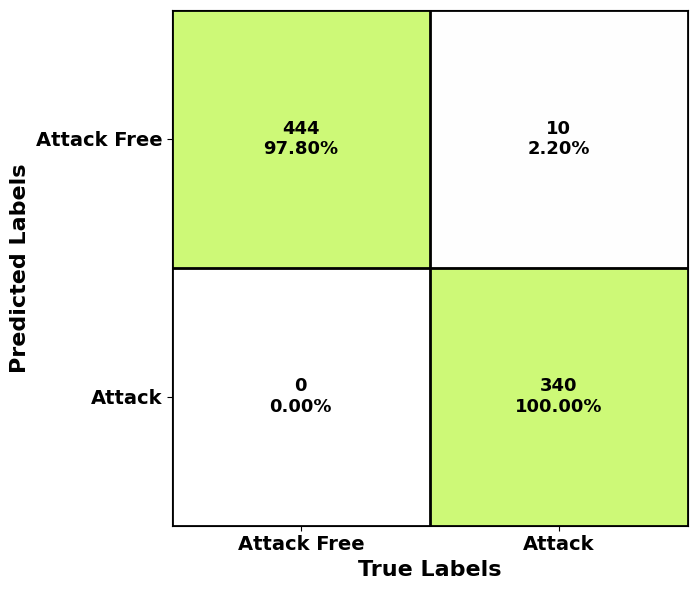

In [36]:
DATA_DIR = "Split_data/Test/Gen/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.37it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


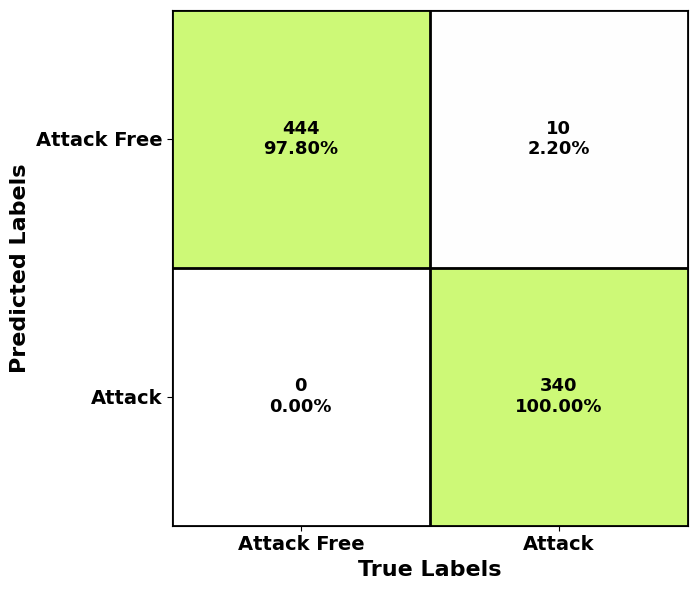

In [37]:
DATA_DIR = "Split_data/Test/Gen/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.61it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.96it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


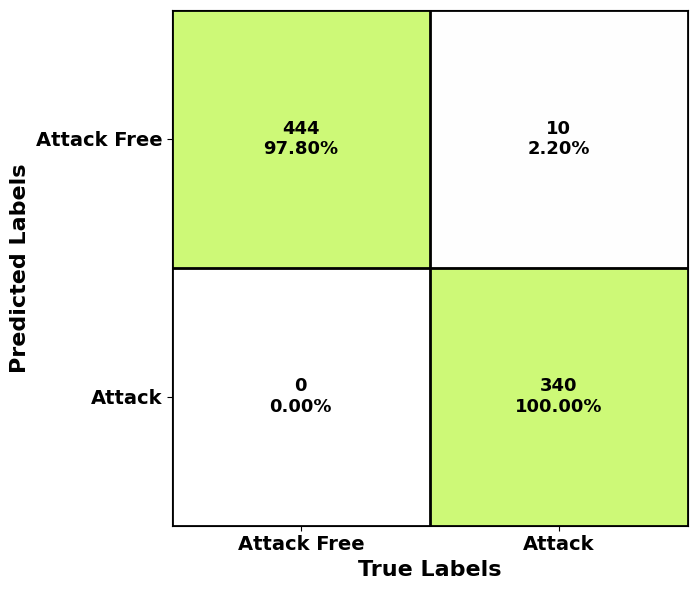

In [38]:
DATA_DIR = "Split_data/Test/Gen/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.54it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.53it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9761  (95% CI: 0.9629, 0.9846)
Precision: 0.9707  (95% CI: 0.9469, 0.9840)
Recall   : 0.9735  (95% CI: 0.9505, 0.9860)
F1-score : 0.9721  (95% CI: 0.9583, 0.9841)


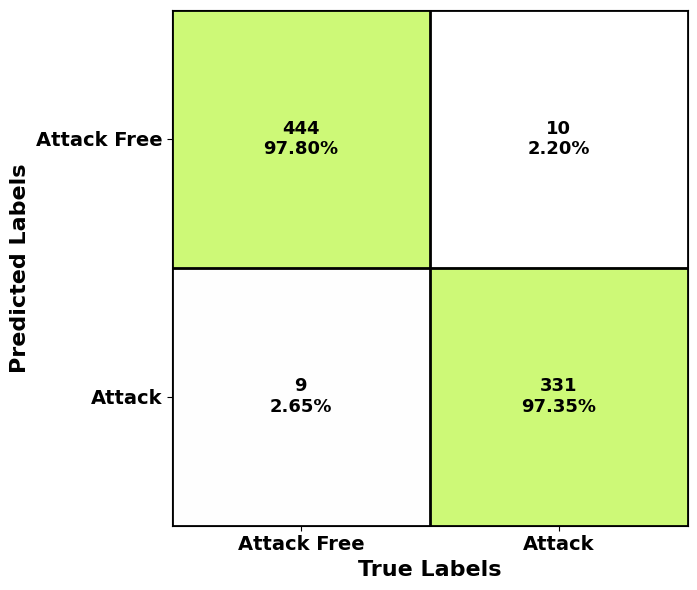

In [39]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.25it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.40it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.09it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


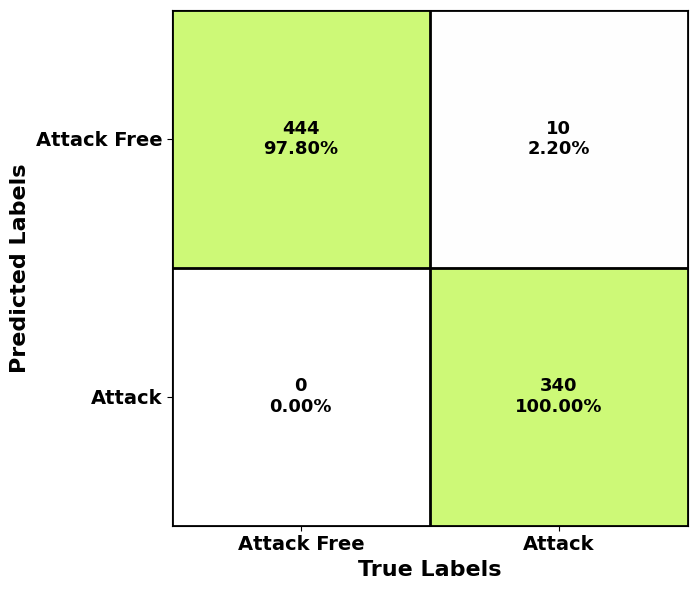

In [40]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.19it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.87it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


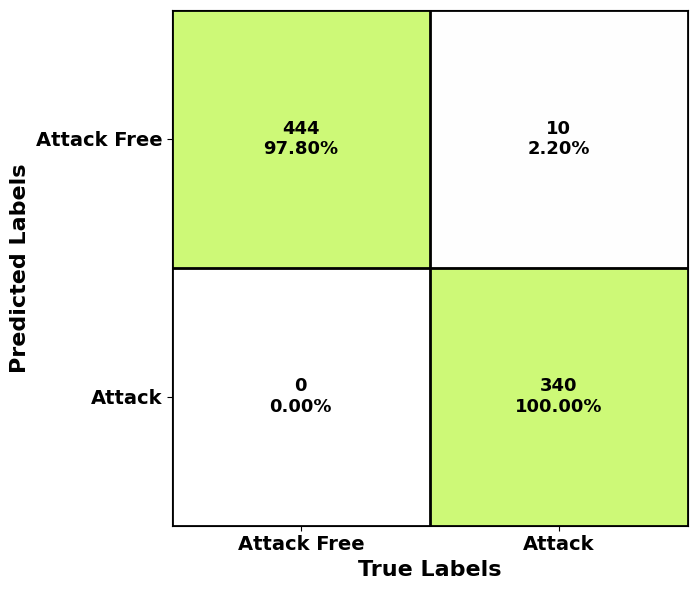

In [41]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.07it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.26it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


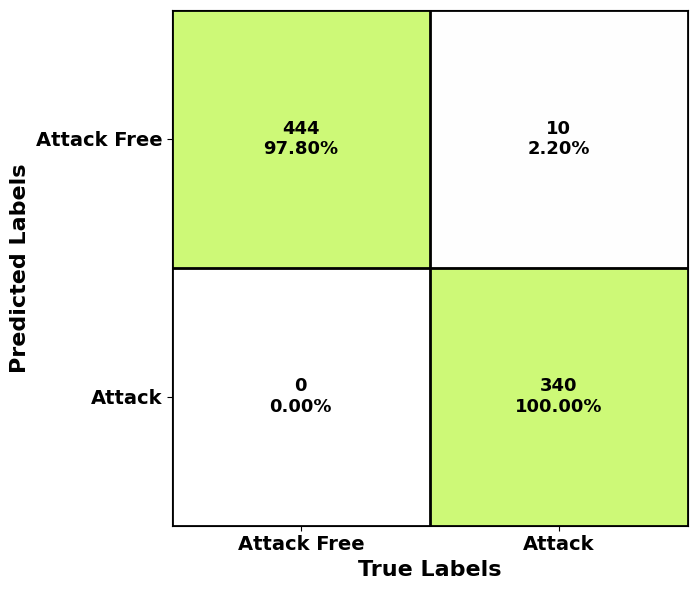

In [42]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.46it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.54it/s]


Total validation samples: 795


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.93it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9932)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9755, 0.9942)


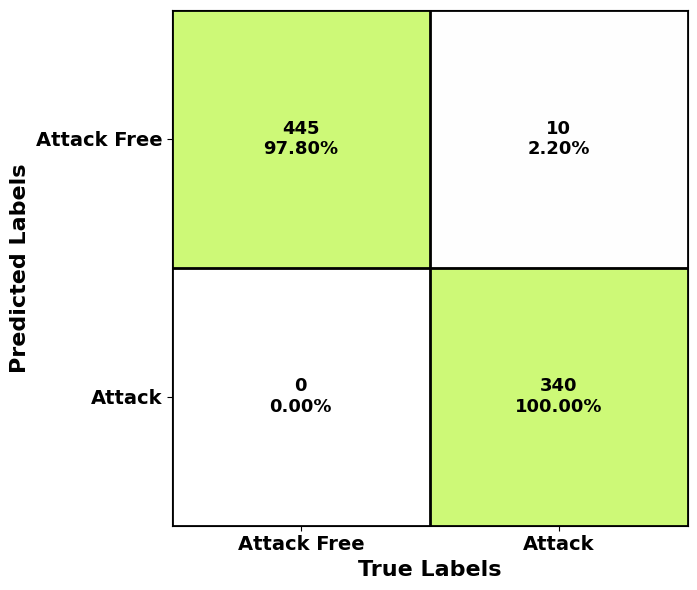

In [43]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.75it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


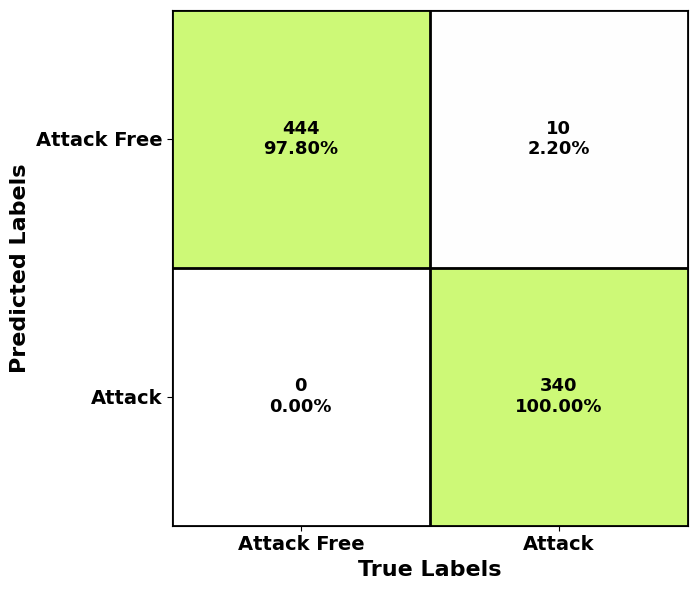

In [44]:
DATA_DIR = "Split_data/Test/Gen/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.85it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.72it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.09it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


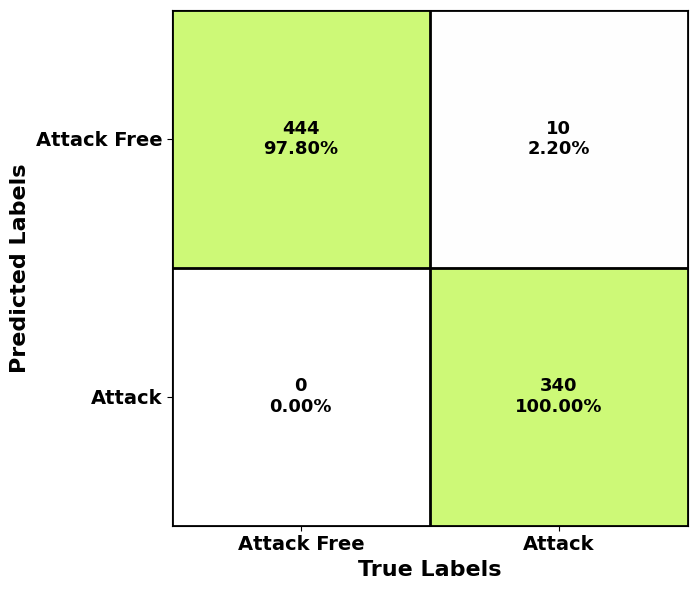

In [45]:
DATA_DIR = "Split_data/Test/Gen/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.67it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.83it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


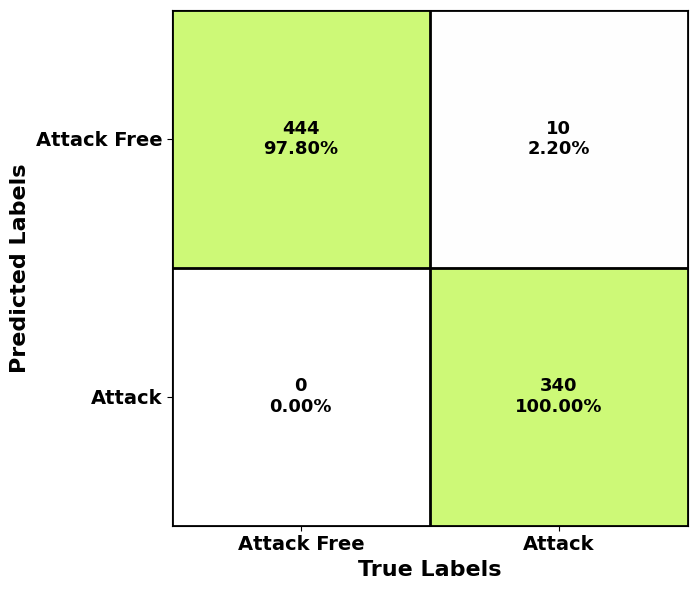

In [46]:
DATA_DIR = "Split_data/Test/Gen/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.64it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  8.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9752, 0.9938)


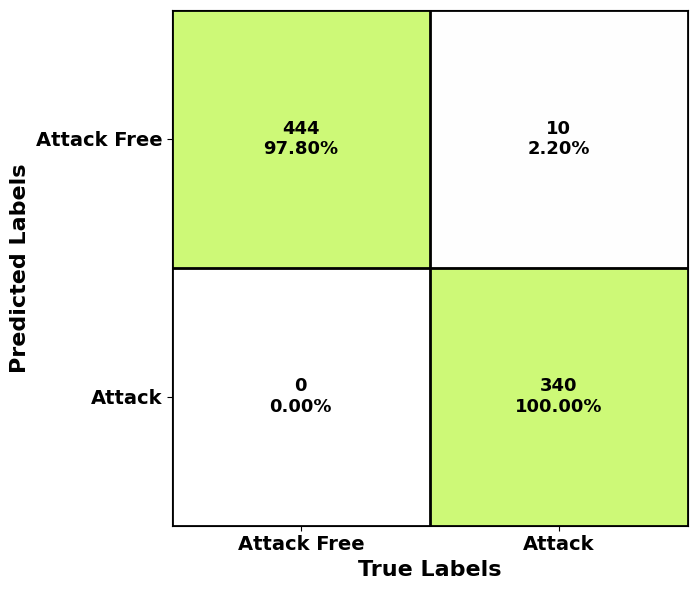

In [47]:
DATA_DIR = "Split_data/Test/Gen/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.75it/s]


Total validation samples: 794


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9874  (95% CI: 0.9770, 0.9931)
Precision: 0.9714  (95% CI: 0.9482, 0.9844)
Recall   : 1.0000  (95% CI: 0.9888, 1.0000)
F1-score : 0.9855  (95% CI: 0.9763, 0.9941)


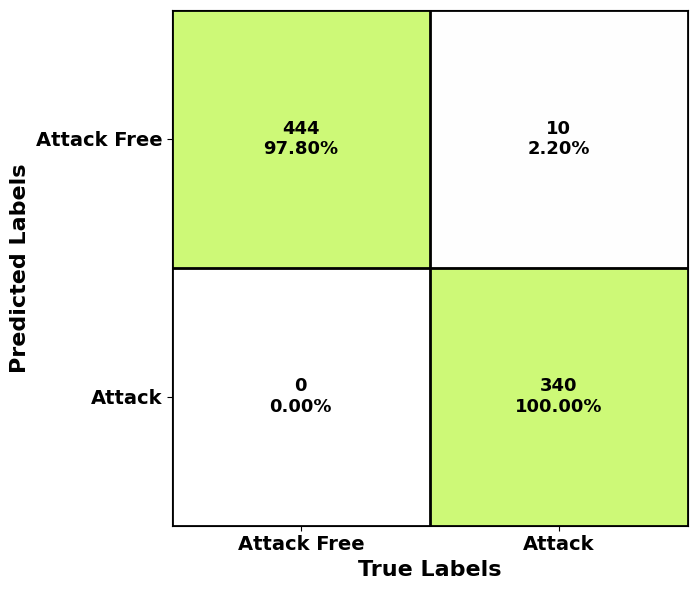

In [48]:
DATA_DIR = "Split_data/Test/Gen/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

In [104]:
import pandas as pd

df = pd.DataFrame([
    # =====================================================
    # DoS
    # =====================================================
    ("DoS","LowerLow","Accuracy",0.9458,0.9278,0.9595),
    ("DoS","LowerLow","Precision",0.9685,0.9429,0.9828),
    ("DoS","LowerLow","Recall",0.9029,0.8668,0.9301),
    ("DoS","LowerLow","F1",0.9346,0.9144,0.9527),

    ("DoS","Low","Accuracy",0.9874,0.9770,0.9931),
    ("DoS","Low","Precision",0.9714,0.9482,0.9844),
    ("DoS","Low","Recall",1.0000,0.9888,1.0000),
    ("DoS","Low","F1",0.9855,0.9763,0.9941),

    ("DoS","Medium","Accuracy",0.9874,0.9770,0.9931),
    ("DoS","Medium","Precision",0.9714,0.9482,0.9844),
    ("DoS","Medium","Recall",1.0000,0.9888,1.0000),
    ("DoS","Medium","F1",0.9855,0.9752,0.9938),

    ("DoS","High","Accuracy",0.9874,0.9770,0.9931),
    ("DoS","High","Precision",0.9714,0.9482,0.9844),
    ("DoS","High","Recall",1.0000,0.9888,1.0000),
    ("DoS","High","F1",0.9855,0.9763,0.9941),

    ("DoS","Random","Accuracy",0.9874,0.9770,0.9931),
    ("DoS","Random","Precision",0.9714,0.9482,0.9844),
    ("DoS","Random","Recall",1.0000,0.9888,1.0000),
    ("DoS","Random","F1",0.9855,0.9752,0.9938),

    # =====================================================
    # Fuzz
    # =====================================================
    ("Fuzz","LowerLow","Accuracy",0.9761,0.9629,0.9846),
    ("Fuzz","LowerLow","Precision",0.9707,0.9469,0.9840),
    ("Fuzz","LowerLow","Recall",0.9735,0.9505,0.9860),
    ("Fuzz","LowerLow","F1",0.9721,0.9583,0.9841),

    ("Fuzz","Low","Accuracy",0.9874,0.9770,0.9931),
    ("Fuzz","Low","Precision",0.9714,0.9482,0.9844),
    ("Fuzz","Low","Recall",1.0000,0.9888,1.0000),
    ("Fuzz","Low","F1",0.9855,0.9752,0.9938),

    ("Fuzz","Medium","Accuracy",0.9874,0.9770,0.9931),
    ("Fuzz","Medium","Precision",0.9714,0.9482,0.9844),
    ("Fuzz","Medium","Recall",1.0000,0.9888,1.0000),
    ("Fuzz","Medium","F1",0.9855,0.9752,0.9938),

    ("Fuzz","High","Accuracy",0.9874,0.9770,0.9931),
    ("Fuzz","High","Precision",0.9714,0.9482,0.9844),
    ("Fuzz","High","Recall",1.0000,0.9888,1.0000),
    ("Fuzz","High","F1",0.9855,0.9752,0.9938),

    ("Fuzz","Random","Accuracy",0.9874,0.9770,0.9932),
    ("Fuzz","Random","Precision",0.9714,0.9482,0.9844),
    ("Fuzz","Random","Recall",1.0000,0.9888,1.0000),
    ("Fuzz","Random","F1",0.9855,0.9755,0.9942),

    # =====================================================
    # Replay
    # =====================================================
    ("Replay","LowerLow","Accuracy",0.9874,0.9770,0.9931),
    ("Replay","LowerLow","Precision",0.9714,0.9482,0.9844),
    ("Replay","LowerLow","Recall",1.0000,0.9890,1.0000),
    ("Replay","LowerLow","F1",0.9855,0.9763,0.9941),

    ("Replay","Low","Accuracy",0.9874,0.9770,0.9931),
    ("Replay","Low","Precision",0.9714,0.9482,0.9844),
    ("Replay","Low","Recall",1.0000,0.9888,1.0000),
    ("Replay","Low","F1",0.9855,0.9752,0.9938),

    ("Replay","Medium","Accuracy",0.9874,0.9770,0.9931),
    ("Replay","Medium","Precision",0.9714,0.9482,0.9844),
    ("Replay","Medium","Recall",1.0000,0.9888,1.0000),
    ("Replay","Medium","F1",0.9855,0.9752,0.9938),

    ("Replay","High","Accuracy",0.9874,0.9770,0.9931),
    ("Replay","High","Precision",0.9714,0.9482,0.9844),
    ("Replay","High","Recall",1.0000,0.9888,1.0000),
    ("Replay","High","F1",0.9855,0.9752,0.9938),

    ("Replay","Random","Accuracy",0.9874,0.9770,0.9931),
    ("Replay","Random","Precision",0.9714,0.9482,0.9844),
    ("Replay","Random","Recall",1.0000,0.9888,1.0000),
    ("Replay","Random","F1",0.9855,0.9763,0.9941),
], columns=["Attack", "Frequency", "Metric", "Value", "CI_L", "CI_H"])

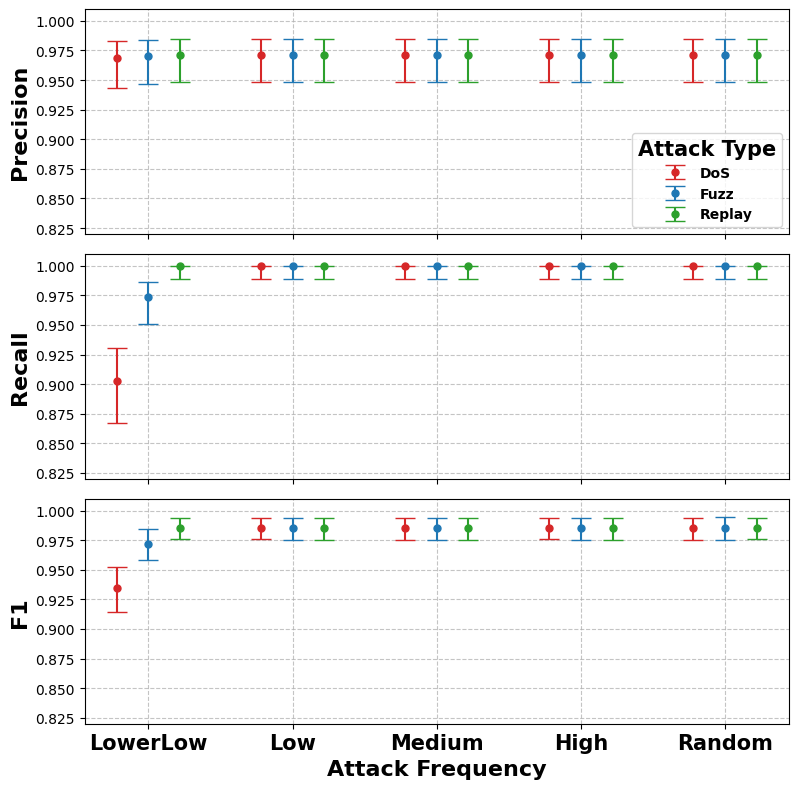

In [105]:
plot_all_metrics_single_figure(df)

## Test on Tesla Silverado

## DoS

In [60]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainKiaOnnx"
TIME_GAP = 90.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.15it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  9.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9097  (95% CI: 0.8893, 0.9266)
Precision: 0.8790  (95% CI: 0.8436, 0.9073)
Recall   : 0.9152  (95% CI: 0.8833, 0.9390)
F1-score : 0.8967  (95% CI: 0.8742, 0.9181)


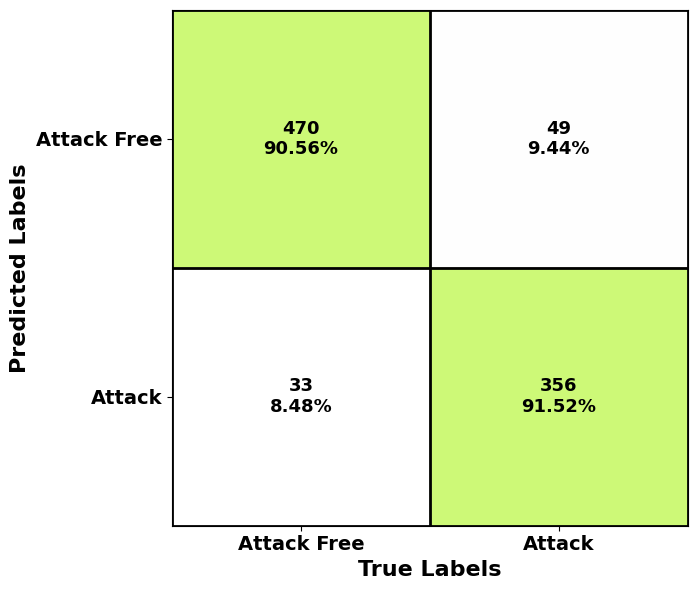

In [61]:
DATA_DIR = "Split_data/Test/Sil/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.23it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9238, 0.9560)


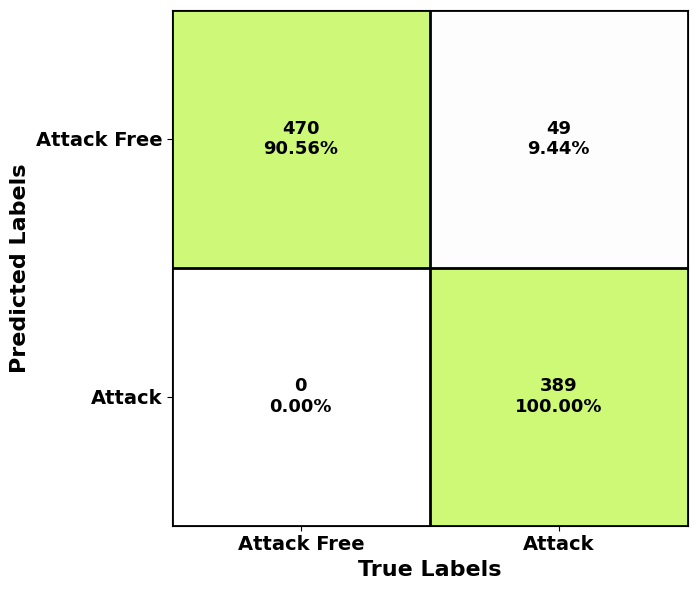

In [62]:
DATA_DIR = "Split_data/Test/Sil/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.17it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  9.07it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9242, 0.9561)


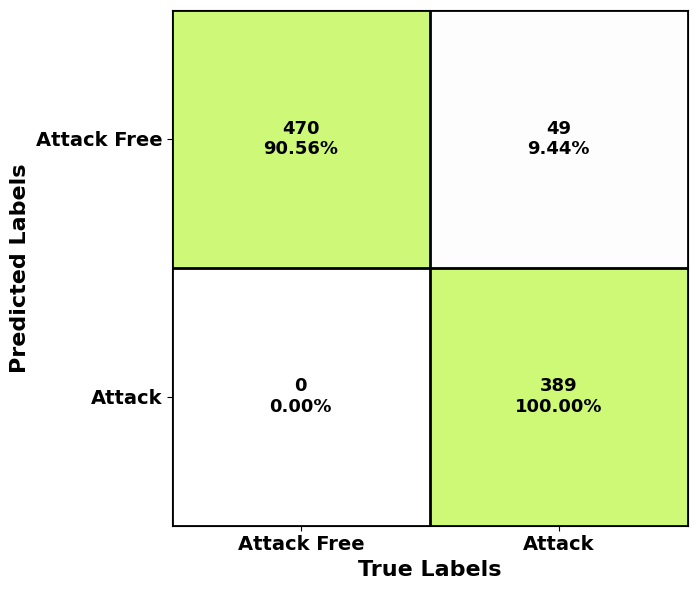

In [63]:
DATA_DIR = "Split_data/Test/Sil/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  9.08it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9242, 0.9561)


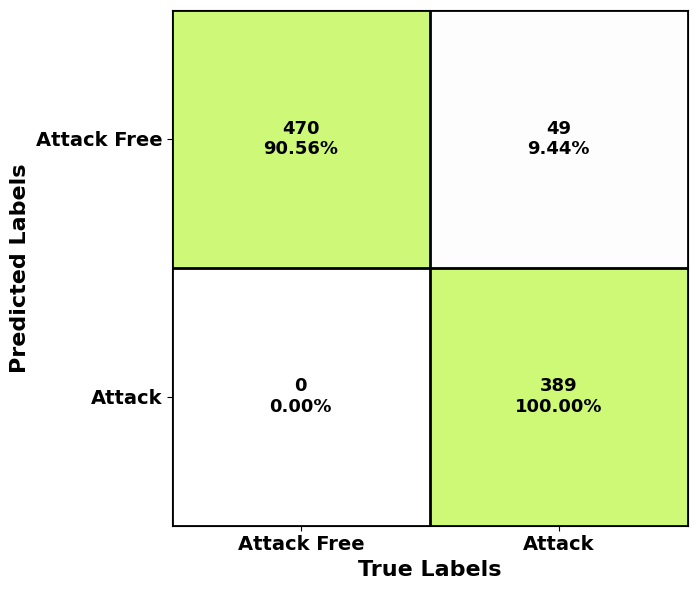

In [64]:
DATA_DIR = "Split_data/Test/Sil/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.13it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9238, 0.9560)


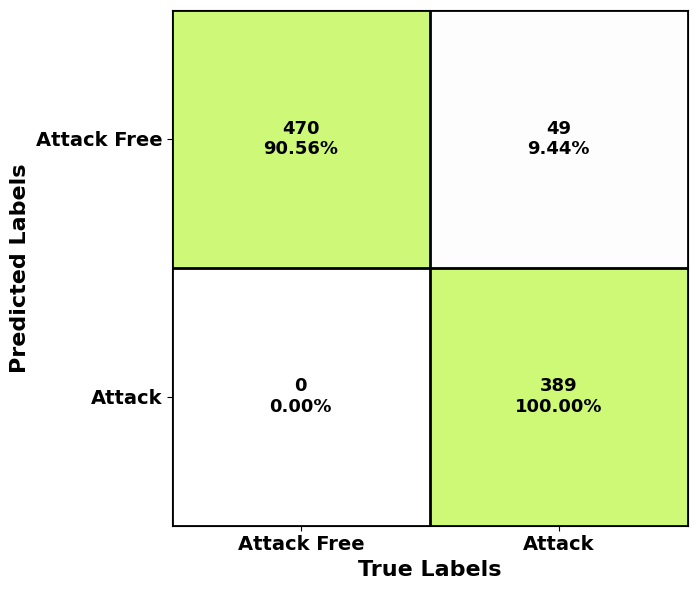

In [65]:
DATA_DIR = "Split_data/Test/Sil/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.87it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9185  (95% CI: 0.8989, 0.9346)
Precision: 0.8814  (95% CI: 0.8466, 0.9091)
Recall   : 0.9357  (95% CI: 0.9069, 0.9561)
F1-score : 0.9077  (95% CI: 0.8868, 0.9278)


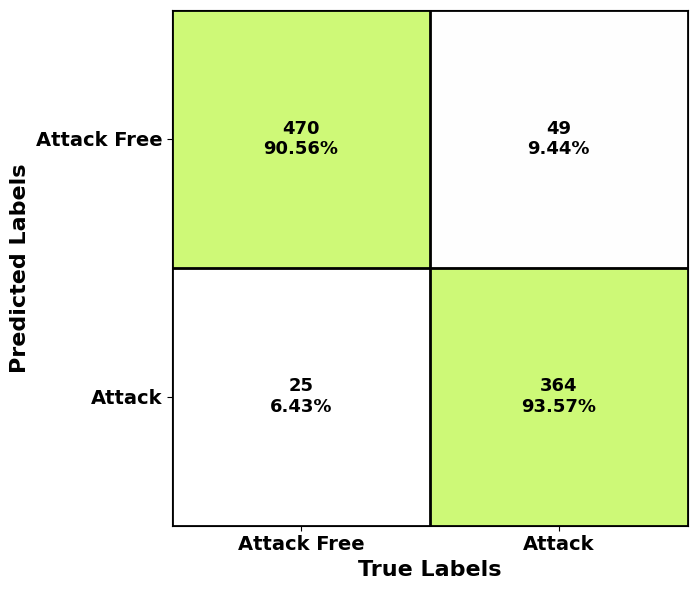

In [73]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.07it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.88it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9238, 0.9560)


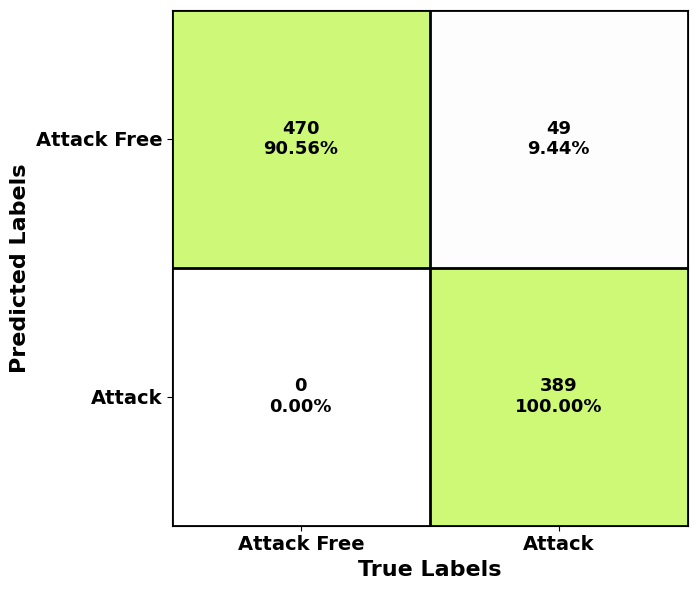

In [74]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.07it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.86it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9242, 0.9561)


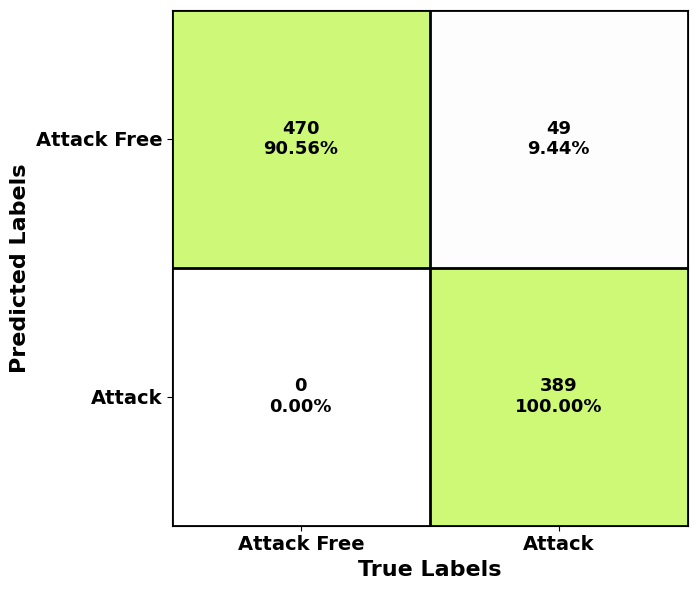

In [75]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.08it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  9.01it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9238, 0.9560)


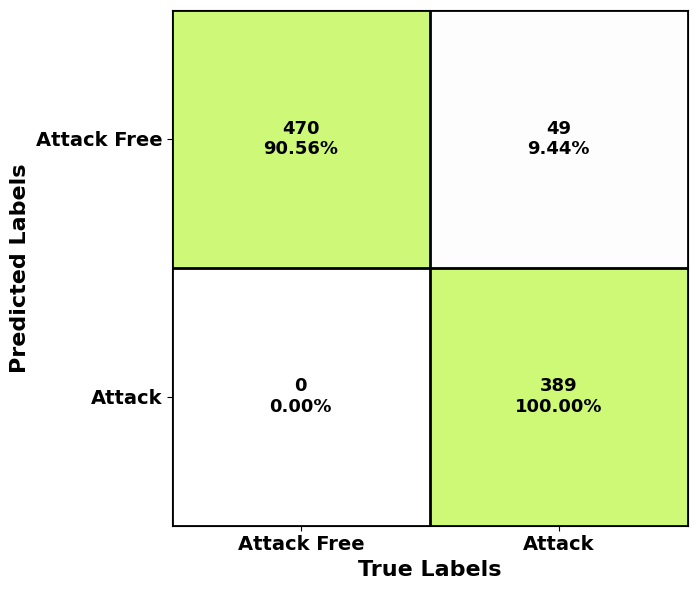

In [76]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.96it/s]


Total validation samples: 909


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.92it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9461  (95% CI: 0.9294, 0.9590)
Precision: 0.8884  (95% CI: 0.8555, 0.9145)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9409  (95% CI: 0.9241, 0.9558)


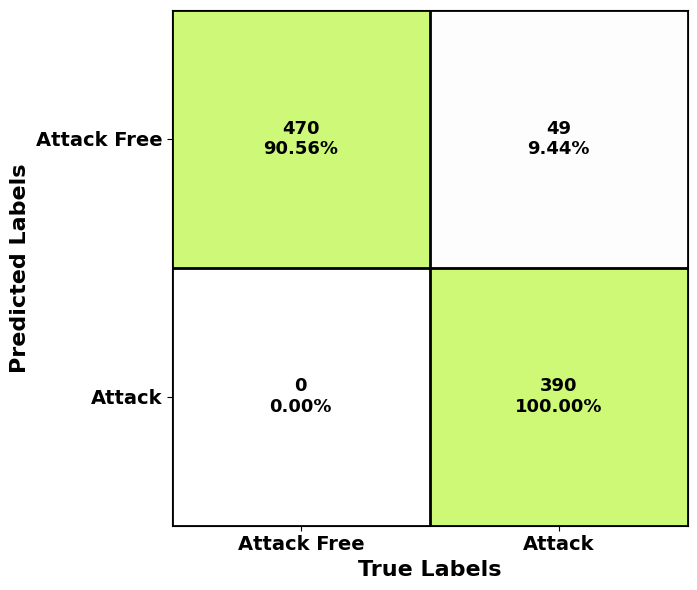

In [77]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9427  (95% CI: 0.9257, 0.9561)
Precision: 0.8874  (95% CI: 0.8542, 0.9137)
Recall   : 0.9923  (95% CI: 0.9776, 0.9974)
F1-score : 0.9369  (95% CI: 0.9189, 0.9524)


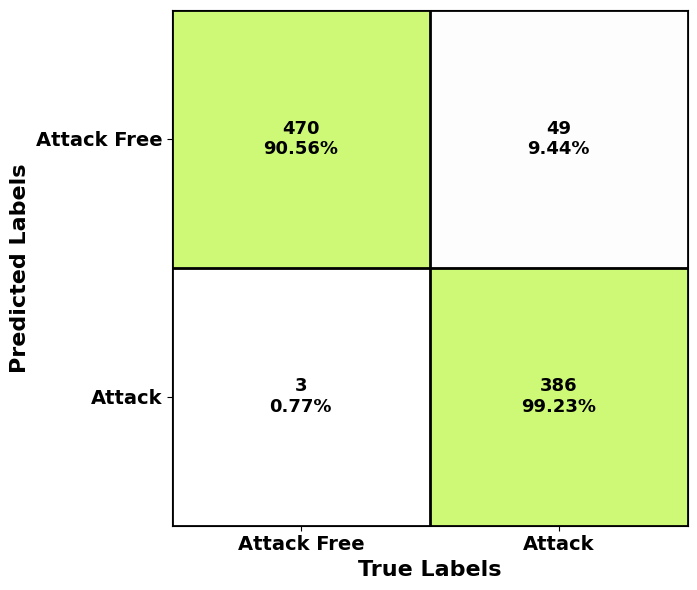

In [78]:
DATA_DIR = "Split_data/Test/Sil/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.06it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  9.07it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9238, 0.9560)


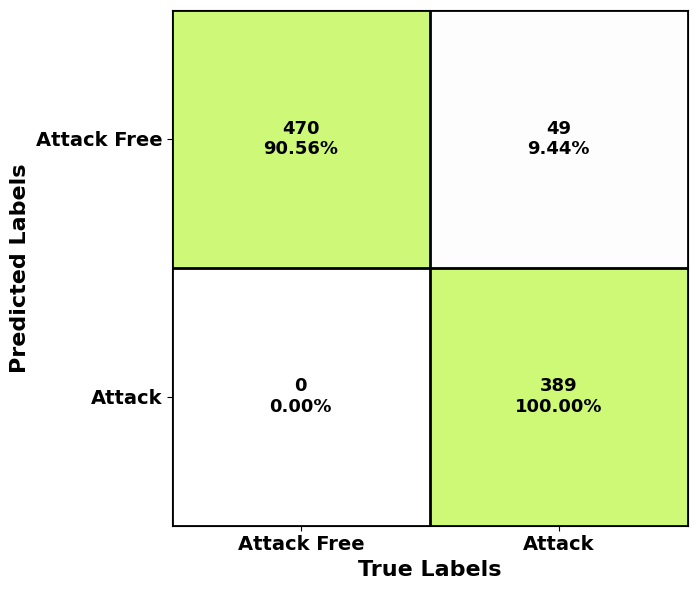

In [79]:
DATA_DIR = "Split_data/Test/Sil/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.01it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.94it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9242, 0.9561)


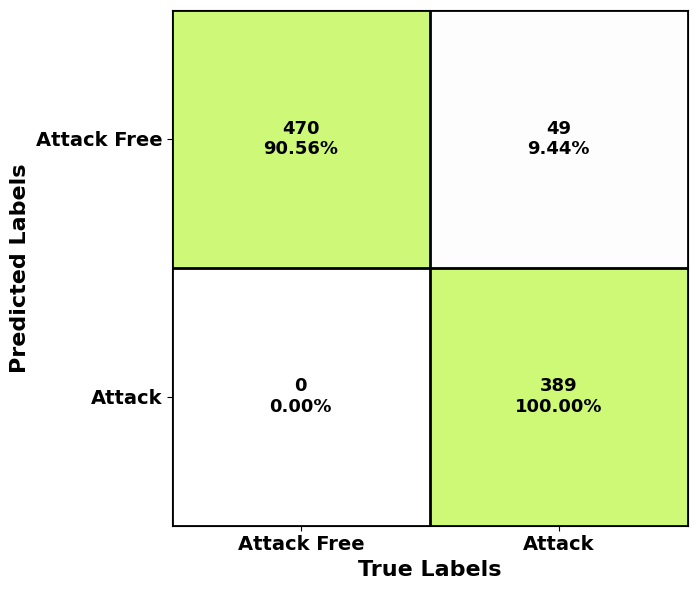

In [80]:
DATA_DIR = "Split_data/Test/Sil/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.98it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.92it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9460  (95% CI: 0.9294, 0.9589)
Precision: 0.8881  (95% CI: 0.8552, 0.9143)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9407  (95% CI: 0.9242, 0.9561)


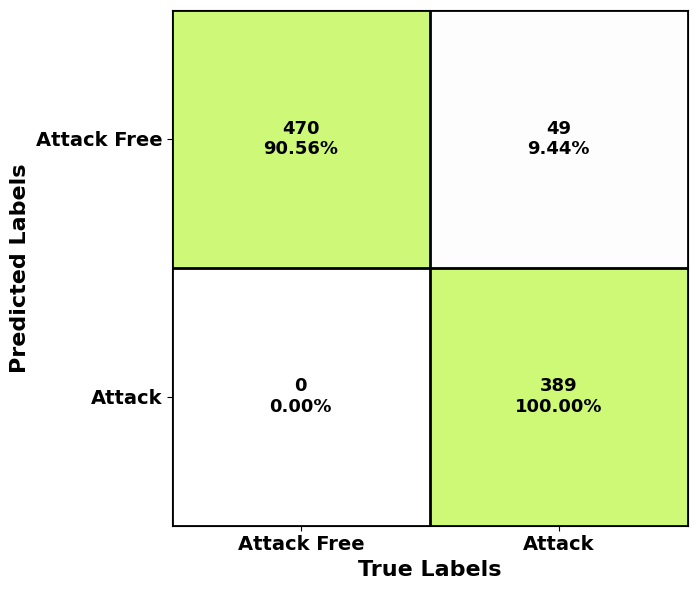

In [81]:
DATA_DIR = "Split_data/Test/Sil/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainKiaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.02it/s]


Total validation samples: 909


ONNX Inference: 100%|██████████| 57/57 [00:06<00:00,  8.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9461  (95% CI: 0.9294, 0.9590)
Precision: 0.8884  (95% CI: 0.8555, 0.9145)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9409  (95% CI: 0.9241, 0.9558)


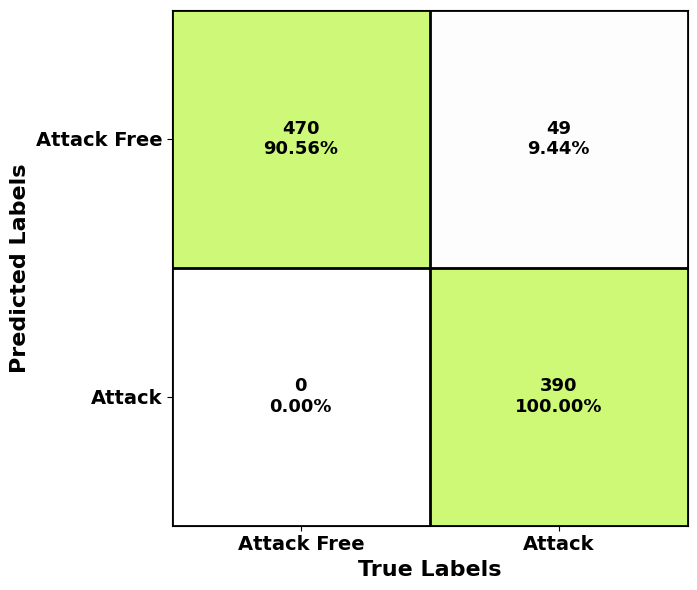

In [82]:
DATA_DIR = "Split_data/Test/Sil/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

In [109]:
df = pd.DataFrame([
    # =====================================================
    # DoS
    # =====================================================
    ("DoS","LowerLow","Accuracy",0.9097,0.8893,0.9266),
    ("DoS","LowerLow","Precision",0.8790,0.8436,0.9073),
    ("DoS","LowerLow","Recall",0.9152,0.8833,0.9390),
    ("DoS","LowerLow","F1",0.8967,0.8742,0.9181),

    ("DoS","Low","Accuracy",0.9460,0.9294,0.9589),
    ("DoS","Low","Precision",0.8881,0.8552,0.9143),
    ("DoS","Low","Recall",1.0000,0.9902,1.0000),
    ("DoS","Low","F1",0.9407,0.9238,0.9560),

    ("DoS","Medium","Accuracy",0.9460,0.9294,0.9589),
    ("DoS","Medium","Precision",0.8881,0.8552,0.9143),
    ("DoS","Medium","Recall",1.0000,0.9902,1.0000),
    ("DoS","Medium","F1",0.9407,0.9242,0.9561),

    ("DoS","High","Accuracy",0.9460,0.9294,0.9589),
    ("DoS","High","Precision",0.8881,0.8552,0.9143),
    ("DoS","High","Recall",1.0000,0.9902,1.0000),
    ("DoS","High","F1",0.9407,0.9242,0.9561),

    ("DoS","Random","Accuracy",0.9460,0.9294,0.9589),
    ("DoS","Random","Precision",0.8881,0.8552,0.9143),
    ("DoS","Random","Recall",1.0000,0.9902,1.0000),
    ("DoS","Random","F1",0.9407,0.9238,0.9560),

    # =====================================================
    # Fuzz
    # =====================================================
    ("Fuzz","LowerLow","Accuracy",0.9185,0.8989,0.9346),
    ("Fuzz","LowerLow","Precision",0.8814,0.8466,0.9091),
    ("Fuzz","LowerLow","Recall",0.9357,0.9069,0.9561),
    ("Fuzz","LowerLow","F1",0.9077,0.8868,0.9278),

    ("Fuzz","Low","Accuracy",0.9460,0.9294,0.9589),
    ("Fuzz","Low","Precision",0.8881,0.8552,0.9143),
    ("Fuzz","Low","Recall",1.0000,0.9902,1.0000),
    ("Fuzz","Low","F1",0.9407,0.9238,0.9560),

    ("Fuzz","Medium","Accuracy",0.9460,0.9294,0.9589),
    ("Fuzz","Medium","Precision",0.8881,0.8552,0.9143),
    ("Fuzz","Medium","Recall",1.0000,0.9902,1.0000),
    ("Fuzz","Medium","F1",0.9407,0.9242,0.9561),

    ("Fuzz","High","Accuracy",0.9460,0.9294,0.9589),
    ("Fuzz","High","Precision",0.8881,0.8552,0.9143),
    ("Fuzz","High","Recall",1.0000,0.9902,1.0000),
    ("Fuzz","High","F1",0.9407,0.9238,0.9560),

    ("Fuzz","Random","Accuracy",0.9461,0.9294,0.9590),
    ("Fuzz","Random","Precision",0.8884,0.8555,0.9145),
    ("Fuzz","Random","Recall",1.0000,0.9902,1.0000),
    ("Fuzz","Random","F1",0.9409,0.9241,0.9558),

    # =====================================================
    # Replay
    # =====================================================
    ("Replay","LowerLow","Accuracy",0.9427,0.9257,0.9561),
    ("Replay","LowerLow","Precision",0.8874,0.8542,0.9137),
    ("Replay","LowerLow","Recall",0.9923,0.9776,0.9974),
    ("Replay","LowerLow","F1",0.9369,0.9189,0.9524),

    ("Replay","Low","Accuracy",0.9460,0.9294,0.9589),
    ("Replay","Low","Precision",0.8881,0.8552,0.9143),
    ("Replay","Low","Recall",1.0000,0.9902,1.0000),
    ("Replay","Low","F1",0.9407,0.9238,0.9560),

    ("Replay","Medium","Accuracy",0.9460,0.9294,0.9589),
    ("Replay","Medium","Precision",0.8881,0.8552,0.9143),
    ("Replay","Medium","Recall",1.0000,0.9902,1.0000),
    ("Replay","Medium","F1",0.9407,0.9242,0.9561),

    ("Replay","High","Accuracy",0.9460,0.9294,0.9589),
    ("Replay","High","Precision",0.8881,0.8552,0.9143),
    ("Replay","High","Recall",1.0000,0.9902,1.0000),
    ("Replay","High","F1",0.9407,0.9242,0.9561),

    ("Replay","Random","Accuracy",0.9461,0.9294,0.9590),
    ("Replay","Random","Precision",0.8884,0.8555,0.9145),
    ("Replay","Random","Recall",1.0000,0.9902,1.0000),
    ("Replay","Random","F1",0.9409,0.9241,0.9558),
], columns=["Attack", "Frequency", "Metric", "Value", "CI_L", "CI_H"])


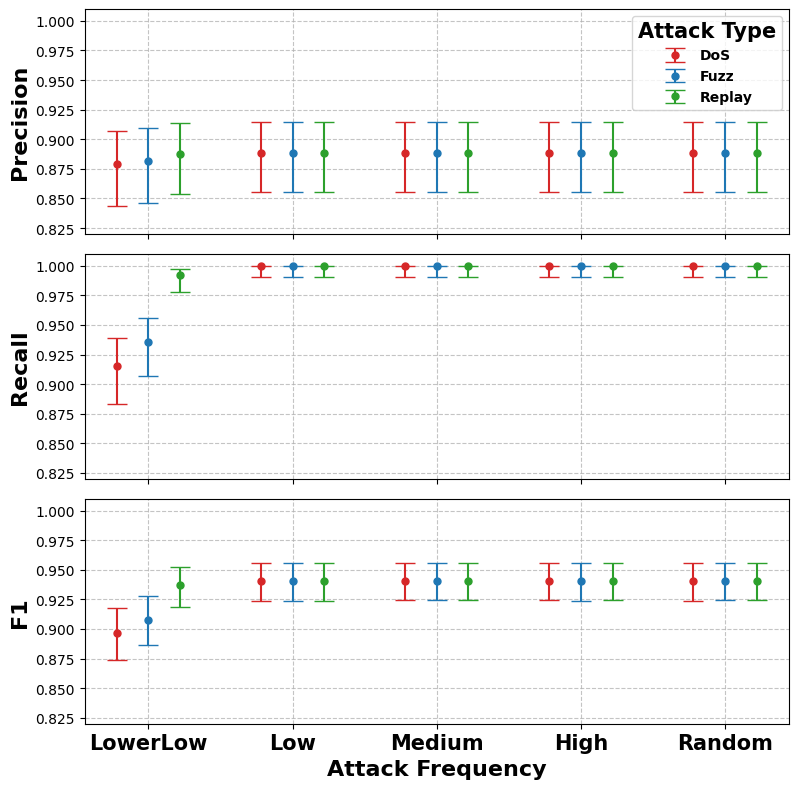

In [110]:
plot_all_metrics_single_figure(df)

## Train on Tesla

## Test on Kia

## DoS

In [111]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainTeslaOnnx"
TIME_GAP = 100.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:05<00:00,  9.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9313  (95% CI: 0.9116, 0.9468)
Precision: 0.9364  (95% CI: 0.9047, 0.9580)
Recall   : 0.9009  (95% CI: 0.8647, 0.9282)
F1-score : 0.9183  (95% CI: 0.8954, 0.9381)


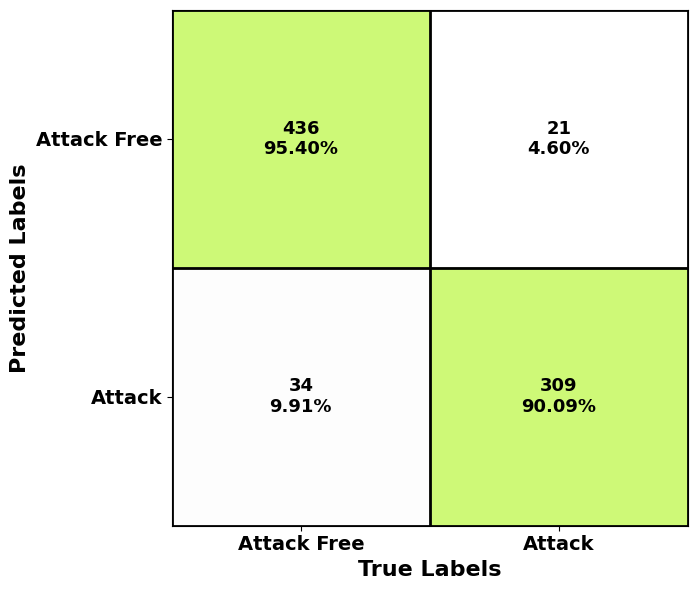

In [118]:
DATA_DIR = "Split_data/Test/Kia/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.07it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.69it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


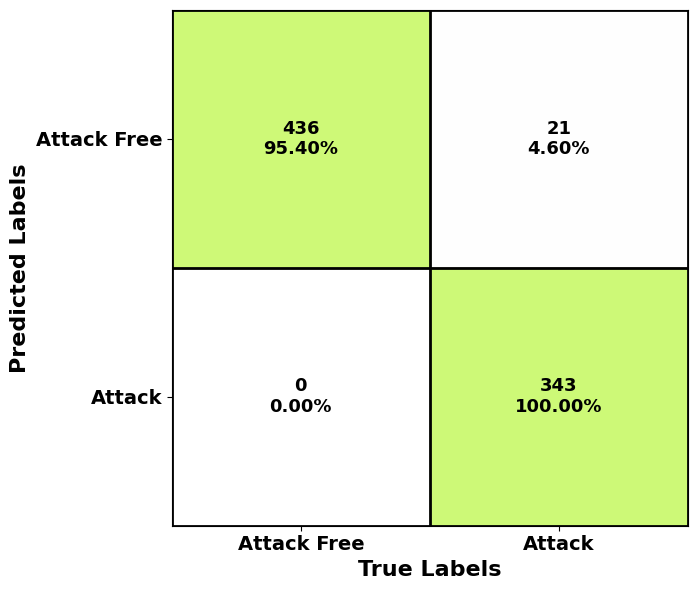

In [119]:
DATA_DIR = "Split_data/Test/Kia/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.45it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.77it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9568, 0.9825)


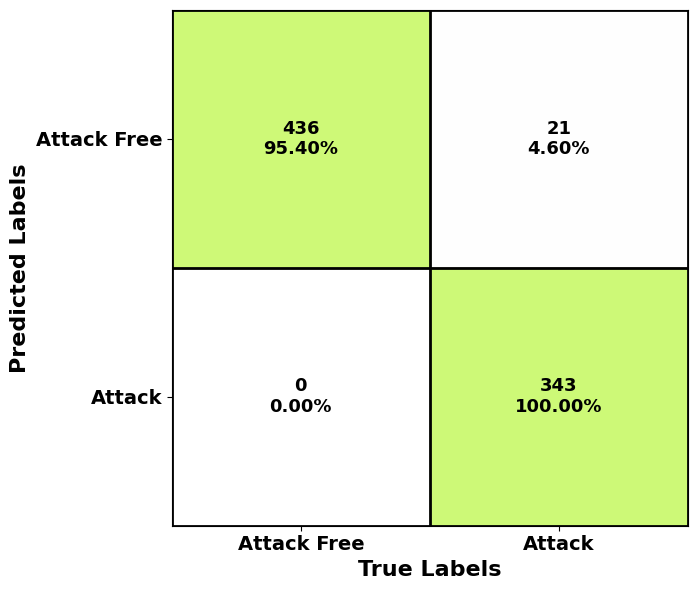

In [120]:
DATA_DIR = "Split_data/Test/Kia/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.68it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


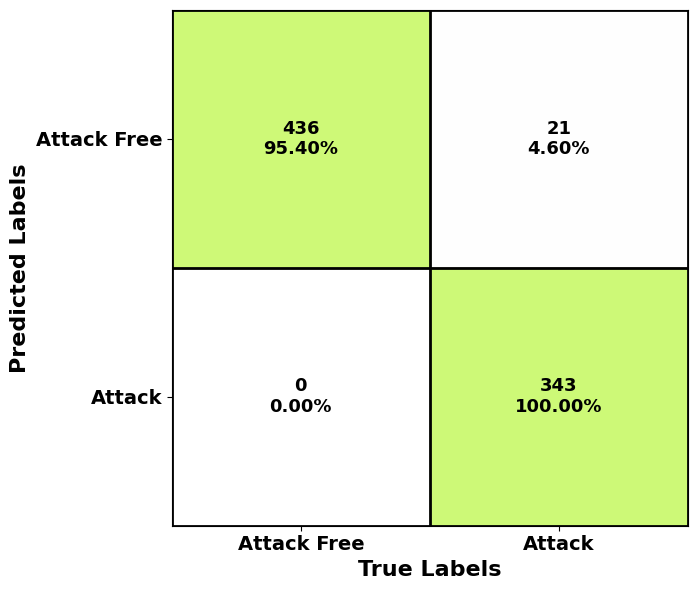

In [121]:
DATA_DIR = "Split_data/Test/Kia/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.45it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.76it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9816)


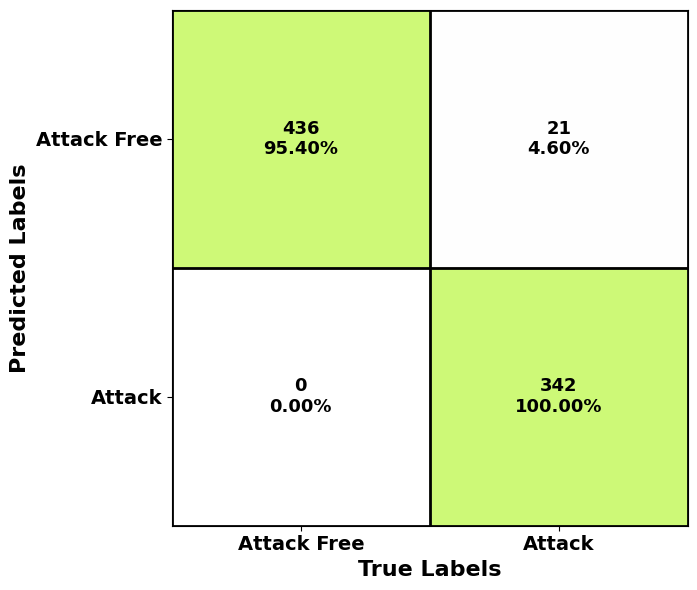

In [122]:
DATA_DIR = "Split_data/Test/Kia/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.35it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9513  (95% CI: 0.9341, 0.9641)
Precision: 0.9393  (95% CI: 0.9090, 0.9600)
Recall   : 0.9475  (95% CI: 0.9186, 0.9666)
F1-score : 0.9434  (95% CI: 0.9242, 0.9598)


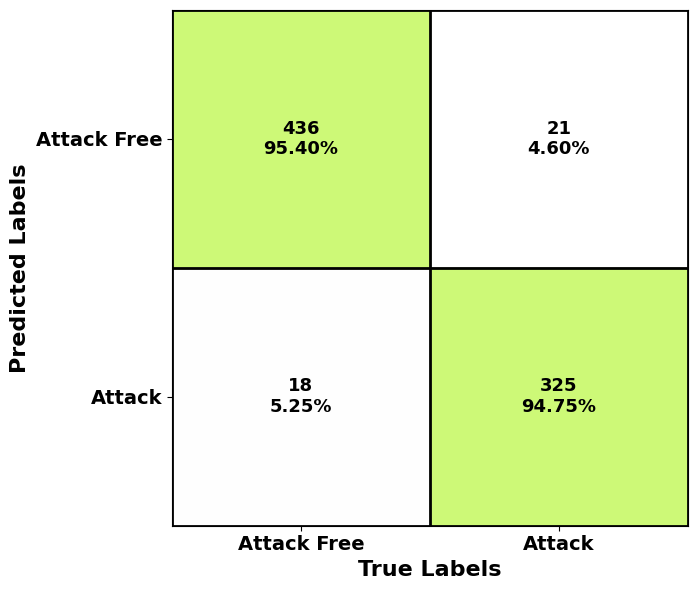

In [123]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.92it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9725  (95% CI: 0.9587, 0.9818)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 0.9971  (95% CI: 0.9837, 0.9995)
F1-score : 0.9688  (95% CI: 0.9551, 0.9811)


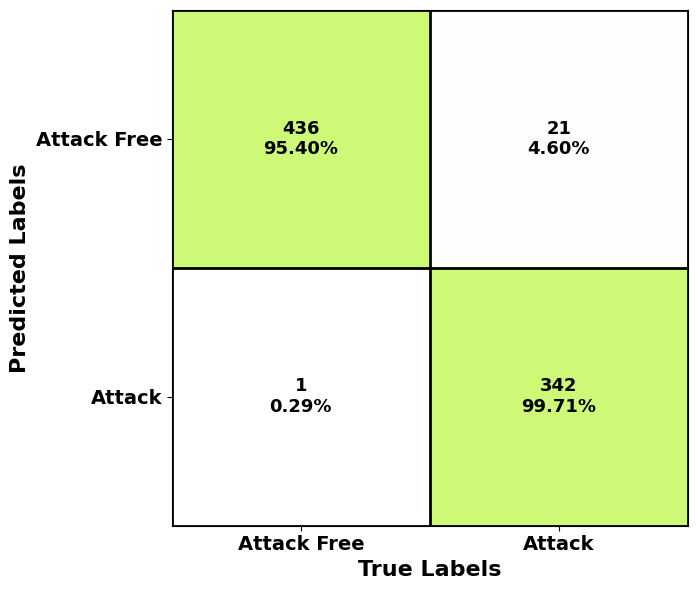

In [124]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.33it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.88it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


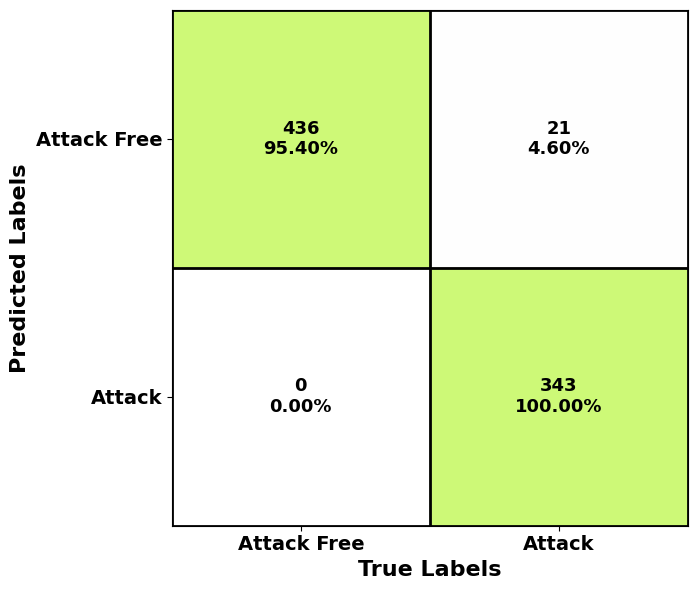

In [125]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.87it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


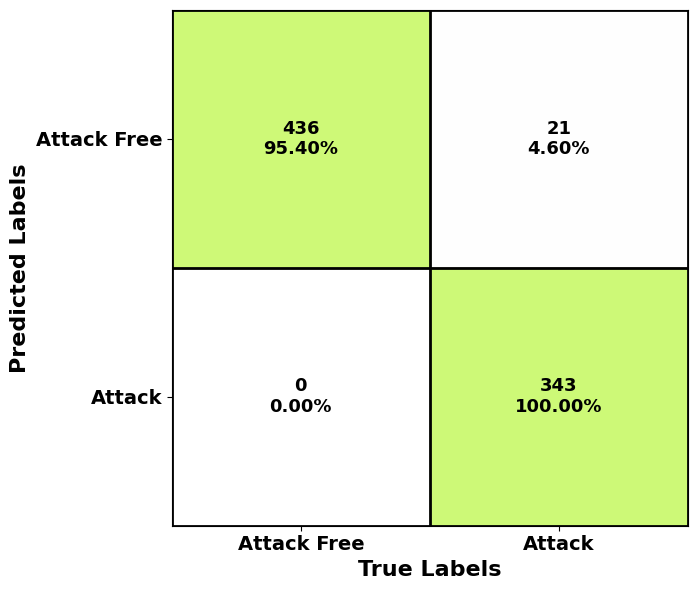

In [126]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.85it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9831)


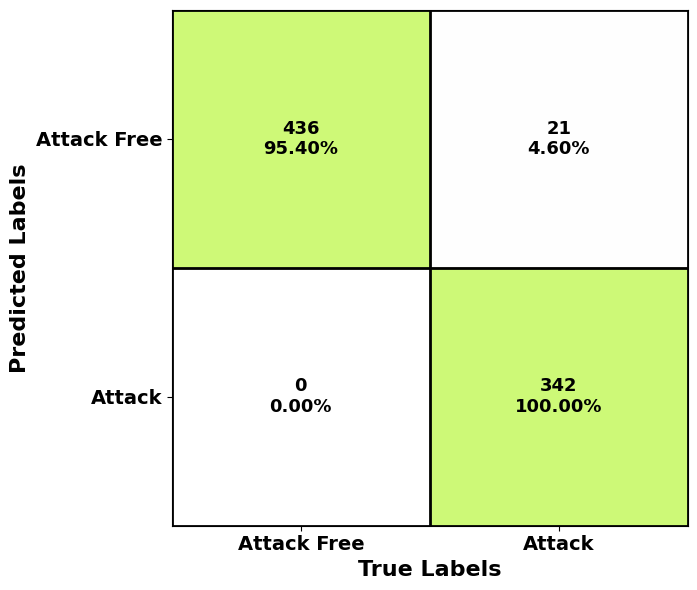

In [127]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.35it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.86it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9712  (95% CI: 0.9572, 0.9808)
Precision: 0.9420  (95% CI: 0.9129, 0.9617)
Recall   : 0.9942  (95% CI: 0.9790, 0.9984)
F1-score : 0.9674  (95% CI: 0.9532, 0.9795)


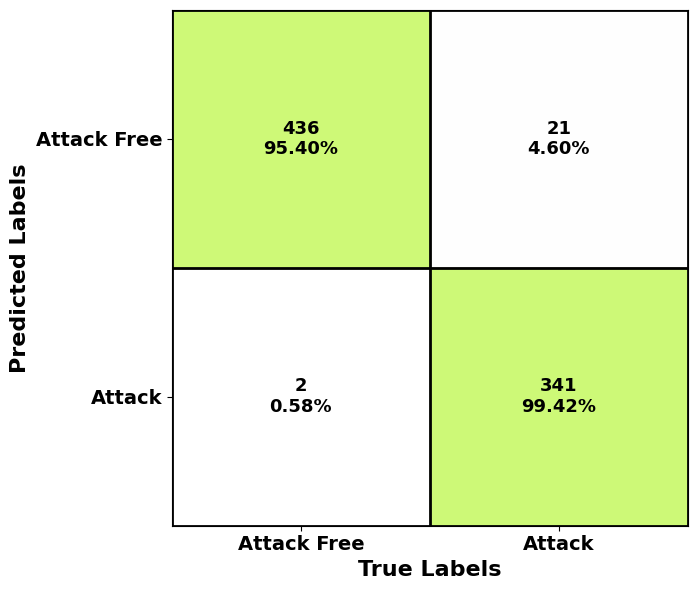

In [128]:
DATA_DIR = "Split_data/Test/Kia/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.89it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


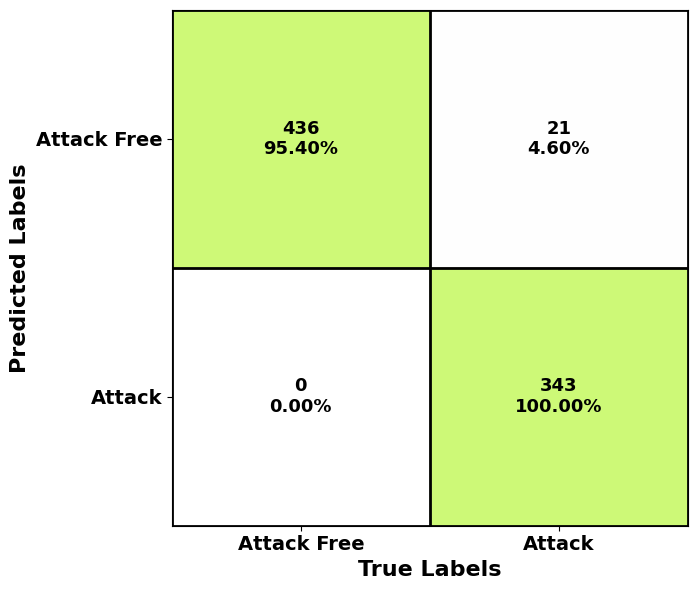

In [129]:
DATA_DIR = "Split_data/Test/Kia/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.02it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.81it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


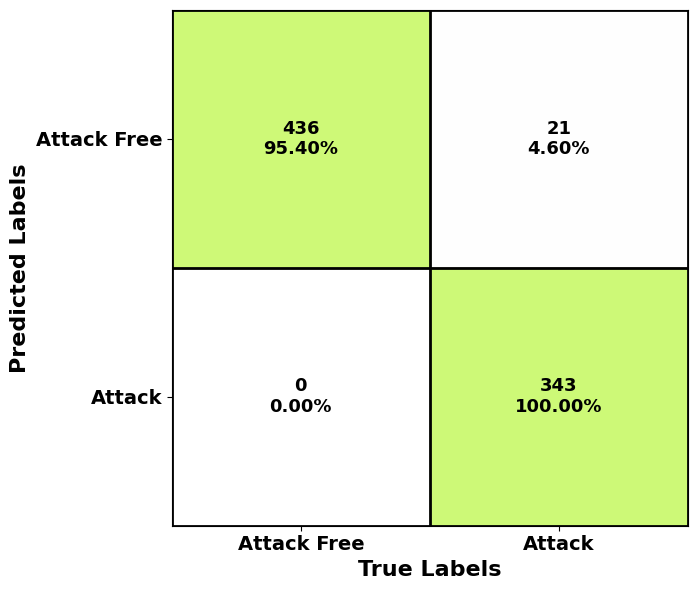

In [130]:
DATA_DIR = "Split_data/Test/Kia/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.84it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


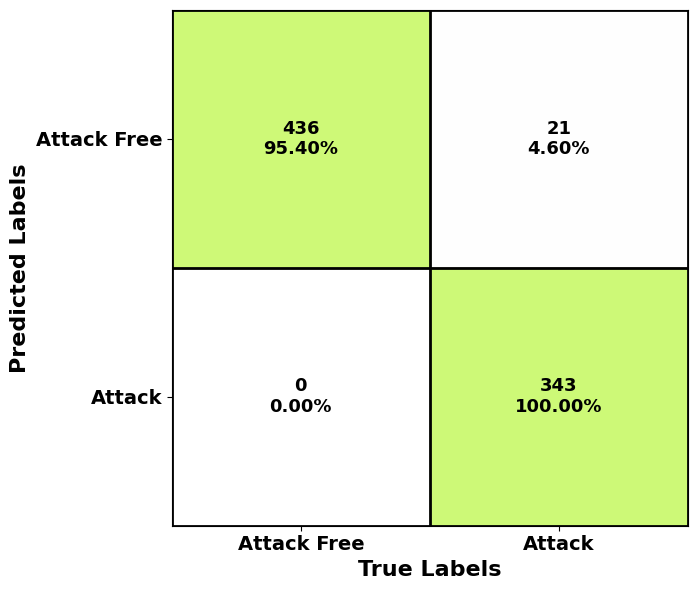

In [131]:
DATA_DIR = "Split_data/Test/Kia/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


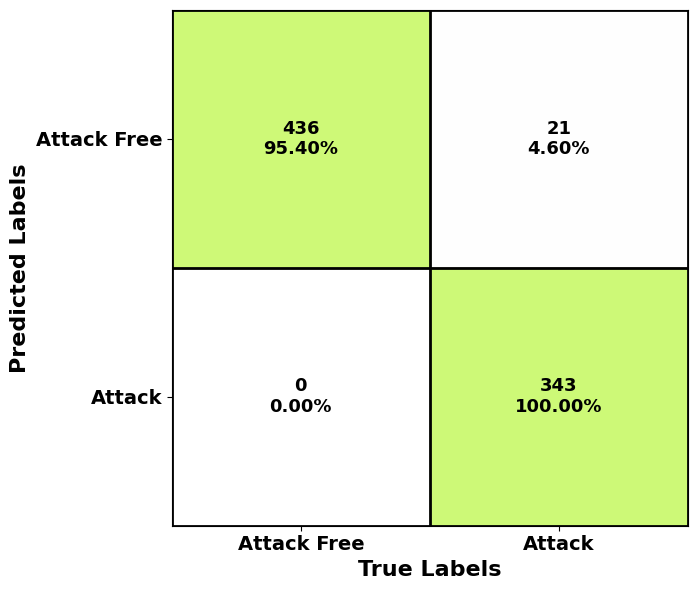

In [132]:
DATA_DIR = "Split_data/Test/Kia/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

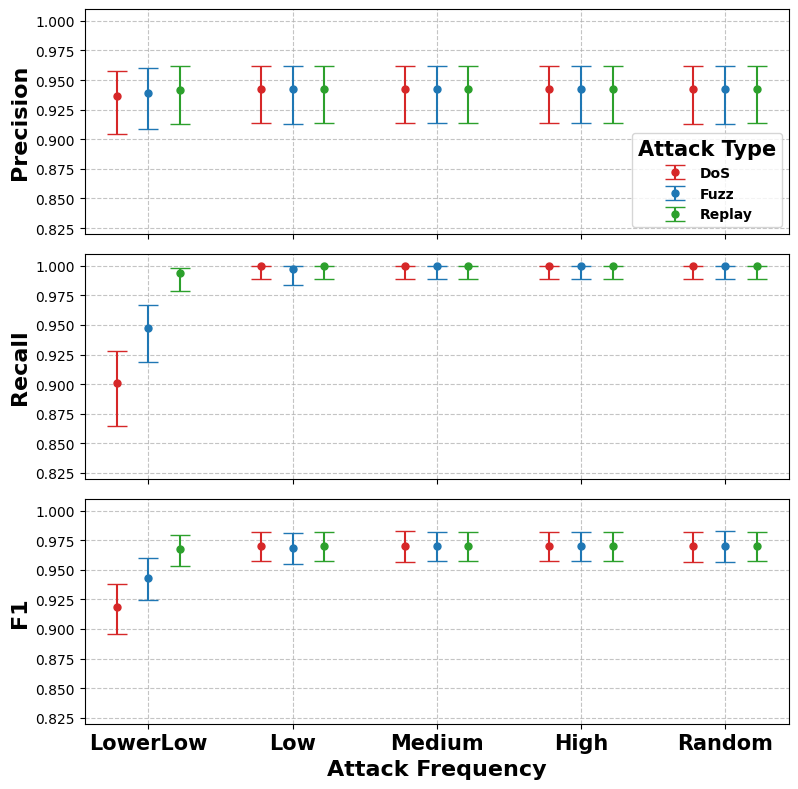

In [135]:
df = pd.DataFrame([
    # =====================================================
    # DoS
    # =====================================================
    ("DoS","LowerLow","Accuracy",0.9313,0.9116,0.9468),
    ("DoS","LowerLow","Precision",0.9364,0.9047,0.9580),
    ("DoS","LowerLow","Recall",0.9009,0.8647,0.9282),
    ("DoS","LowerLow","F1",0.9183,0.8954,0.9381),

    ("DoS","Low","Accuracy",0.9738,0.9602,0.9828),
    ("DoS","Low","Precision",0.9423,0.9134,0.9620),
    ("DoS","Low","Recall",1.0000,0.9889,1.0000),
    ("DoS","Low","F1",0.9703,0.9574,0.9823),

    ("DoS","Medium","Accuracy",0.9738,0.9602,0.9828),
    ("DoS","Medium","Precision",0.9423,0.9134,0.9620),
    ("DoS","Medium","Recall",1.0000,0.9889,1.0000),
    ("DoS","Medium","F1",0.9703,0.9568,0.9825),

    ("DoS","High","Accuracy",0.9738,0.9602,0.9828),
    ("DoS","High","Precision",0.9423,0.9134,0.9620),
    ("DoS","High","Recall",1.0000,0.9889,1.0000),
    ("DoS","High","F1",0.9703,0.9574,0.9823),

    ("DoS","Random","Accuracy",0.9737,0.9602,0.9827),
    ("DoS","Random","Precision",0.9421,0.9132,0.9619),
    ("DoS","Random","Recall",1.0000,0.9889,1.0000),
    ("DoS","Random","F1",0.9702,0.9568,0.9816),

    # =====================================================
    # Fuzz
    # =====================================================
    ("Fuzz","LowerLow","Accuracy",0.9513,0.9341,0.9641),
    ("Fuzz","LowerLow","Precision",0.9393,0.9090,0.9600),
    ("Fuzz","LowerLow","Recall",0.9475,0.9186,0.9666),
    ("Fuzz","LowerLow","F1",0.9434,0.9242,0.9598),

    ("Fuzz","Low","Accuracy",0.9725,0.9587,0.9818),
    ("Fuzz","Low","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Low","Recall",0.9971,0.9837,0.9995),
    ("Fuzz","Low","F1",0.9688,0.9551,0.9811),

    ("Fuzz","Medium","Accuracy",0.9738,0.9602,0.9828),
    ("Fuzz","Medium","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","Medium","Recall",1.0000,0.9889,1.0000),
    ("Fuzz","Medium","F1",0.9703,0.9574,0.9823),

    ("Fuzz","High","Accuracy",0.9738,0.9602,0.9828),
    ("Fuzz","High","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","High","Recall",1.0000,0.9889,1.0000),
    ("Fuzz","High","F1",0.9703,0.9574,0.9823),

    ("Fuzz","Random","Accuracy",0.9737,0.9602,0.9827),
    ("Fuzz","Random","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Random","Recall",1.0000,0.9889,1.0000),
    ("Fuzz","Random","F1",0.9702,0.9568,0.9831),

    # =====================================================
    # Replay
    # =====================================================
    ("Replay","LowerLow","Accuracy",0.9712,0.9572,0.9808),
    ("Replay","LowerLow","Precision",0.9420,0.9129,0.9617),
    ("Replay","LowerLow","Recall",0.9942,0.9790,0.9984),
    ("Replay","LowerLow","F1",0.9674,0.9532,0.9795),

    ("Replay","Low","Accuracy",0.9738,0.9602,0.9828),
    ("Replay","Low","Precision",0.9423,0.9134,0.9620),
    ("Replay","Low","Recall",1.0000,0.9889,1.0000),
    ("Replay","Low","F1",0.9703,0.9574,0.9823),

    ("Replay","Medium","Accuracy",0.9738,0.9602,0.9828),
    ("Replay","Medium","Precision",0.9423,0.9134,0.9620),
    ("Replay","Medium","Recall",1.0000,0.9889,1.0000),
    ("Replay","Medium","F1",0.9703,0.9574,0.9823),

    ("Replay","High","Accuracy",0.9738,0.9602,0.9828),
    ("Replay","High","Precision",0.9423,0.9134,0.9620),
    ("Replay","High","Recall",1.0000,0.9889,1.0000),
    ("Replay","High","F1",0.9703,0.9574,0.9823),

    ("Replay","Random","Accuracy",0.9738,0.9602,0.9828),
    ("Replay","Random","Precision",0.9423,0.9134,0.9620),
    ("Replay","Random","Recall",1.0000,0.9889,1.0000),
    ("Replay","Random","F1",0.9703,0.9574,0.9823),
], columns=["Attack", "Frequency", "Metric", "Value", "CI_L", "CI_H"])

plot_all_metrics_single_figure(df)

## Test on Gennesis

## DoS

In [175]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainTeslaOnnx"
TIME_GAP = 105.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.68it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.31it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9736  (95% CI: 0.9604, 0.9825)
Precision: 1.0000  (95% CI: 0.9887, 1.0000)
Recall   : 0.9384  (95% CI: 0.9085, 0.9590)
F1-score : 0.9682  (95% CI: 0.9543, 0.9813)


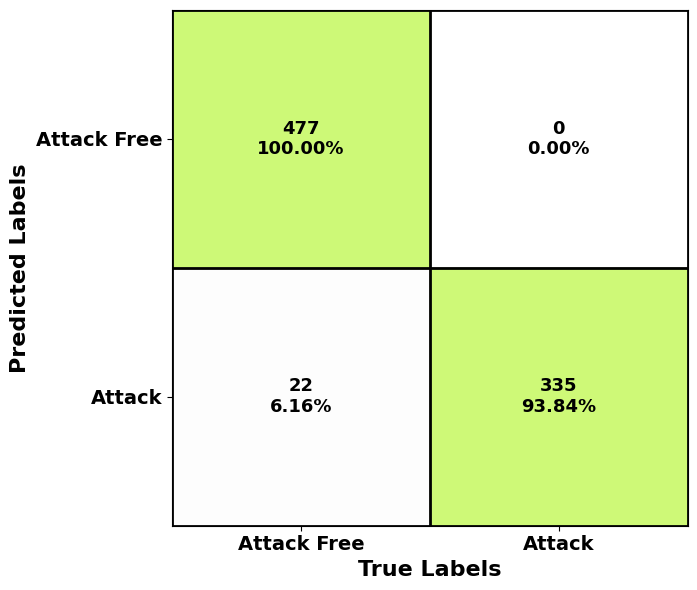

In [136]:
DATA_DIR = "Split_data/Test/Gen/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.46it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.32it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


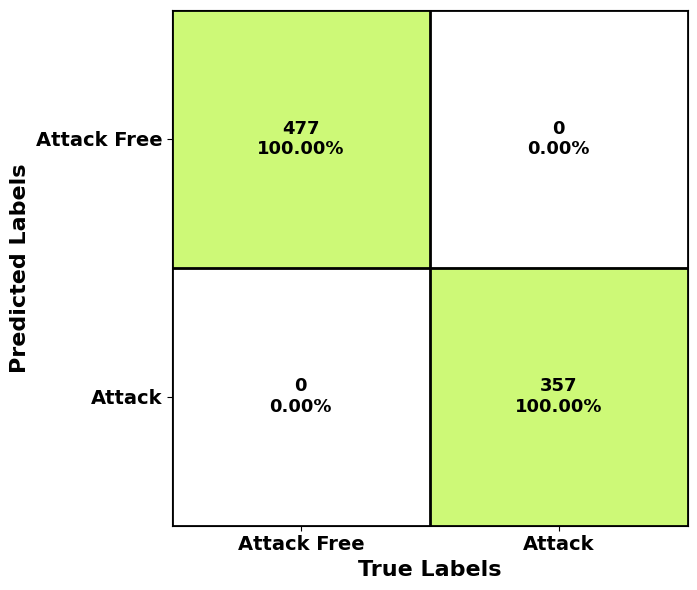

In [137]:
DATA_DIR = "Split_data/Test/Gen/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.32it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.47it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


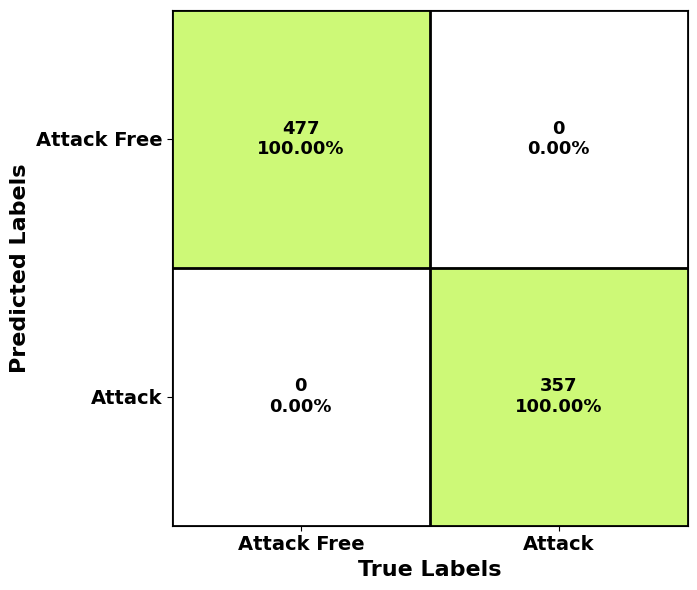

In [138]:
DATA_DIR = "Split_data/Test/Gen/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.44it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.28it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


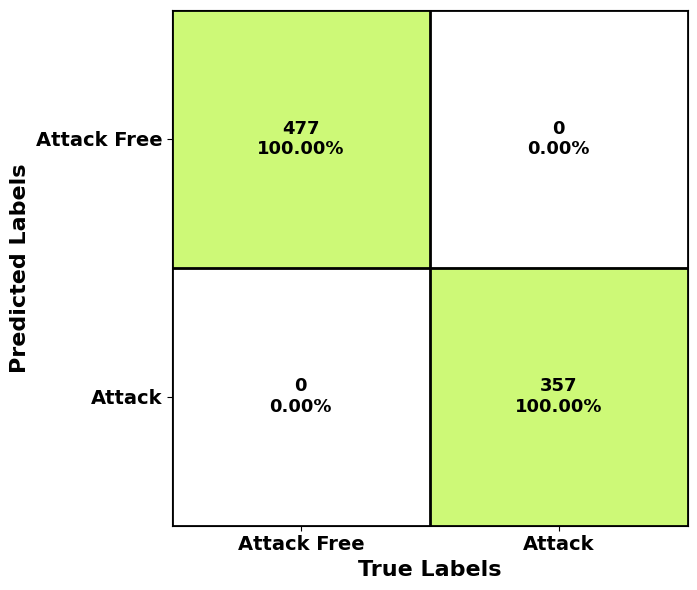

In [139]:
DATA_DIR = "Split_data/Test/Gen/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.67it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.69it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.29it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


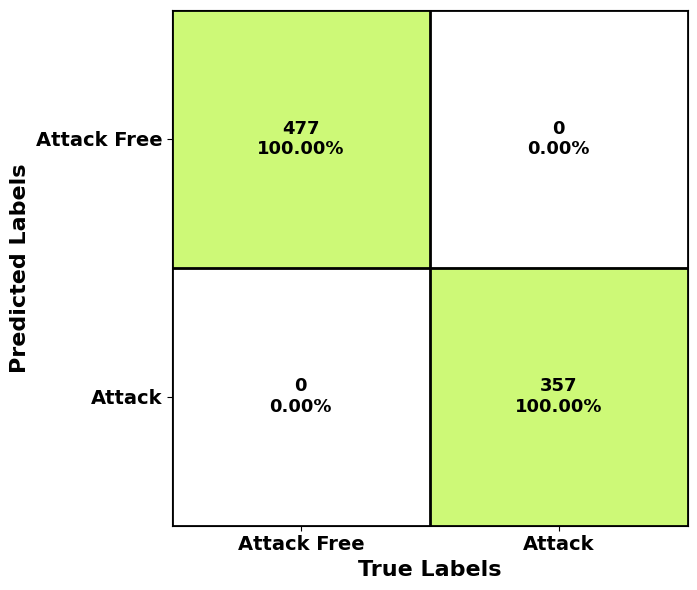

In [140]:
DATA_DIR = "Split_data/Test/Gen/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.56it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.34it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9880  (95% CI: 0.9781, 0.9935)
Precision: 1.0000  (95% CI: 0.9891, 1.0000)
Recall   : 0.9720  (95% CI: 0.9492, 0.9847)
F1-score : 0.9858  (95% CI: 0.9762, 0.9941)


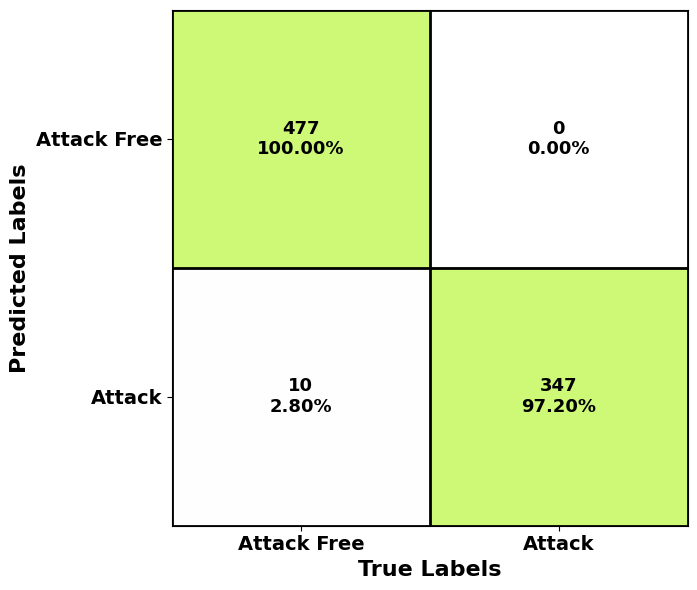

In [141]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.38it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.52it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.36it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


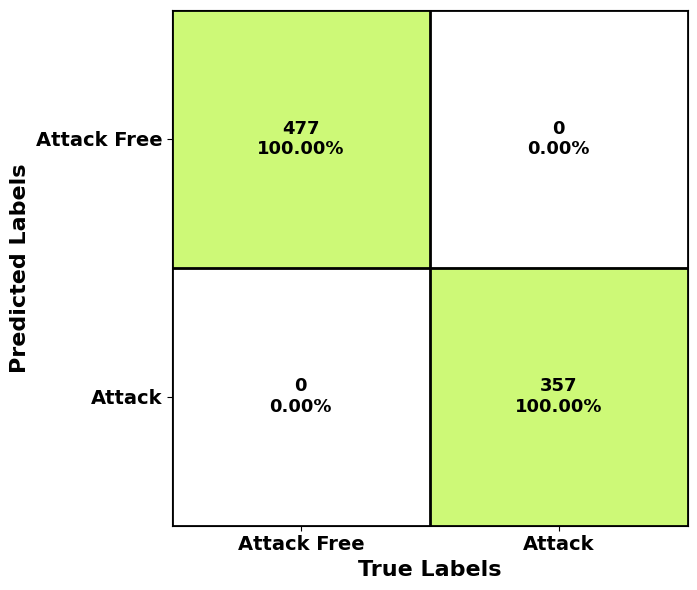

In [142]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.25it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.42it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.29it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


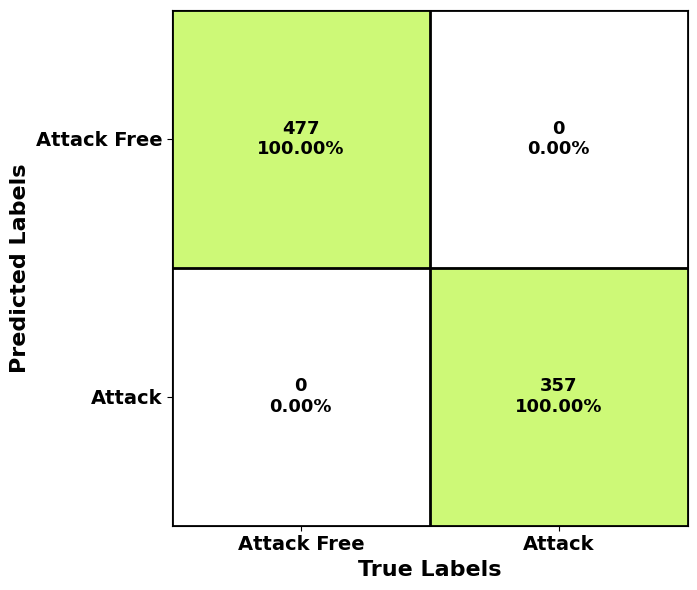

In [143]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.18it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.25it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


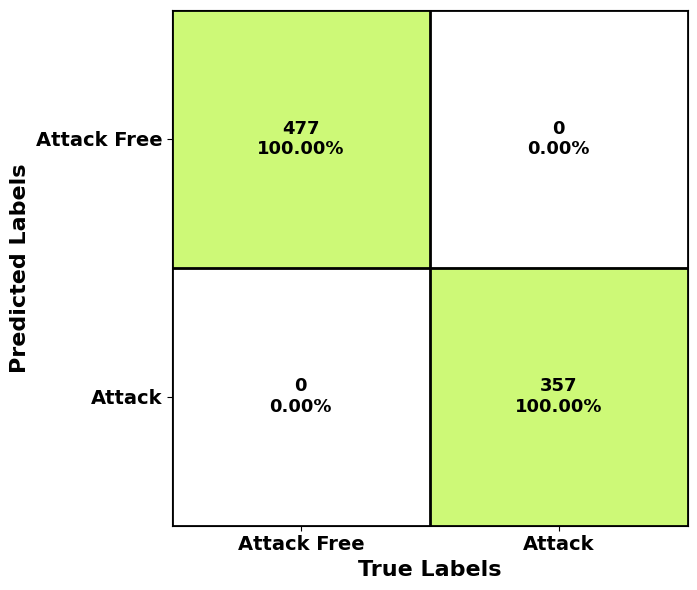

In [144]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.53it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]


Total validation samples: 835


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.28it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


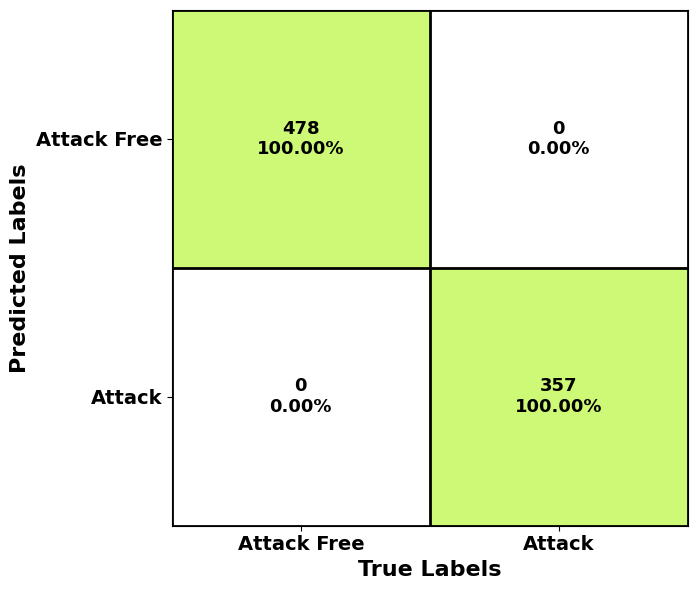

In [145]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.82it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.34it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9988  (95% CI: 0.9932, 0.9998)
Precision: 1.0000  (95% CI: 0.9893, 1.0000)
Recall   : 0.9972  (95% CI: 0.9843, 0.9995)
F1-score : 0.9986  (95% CI: 0.9955, 1.0000)


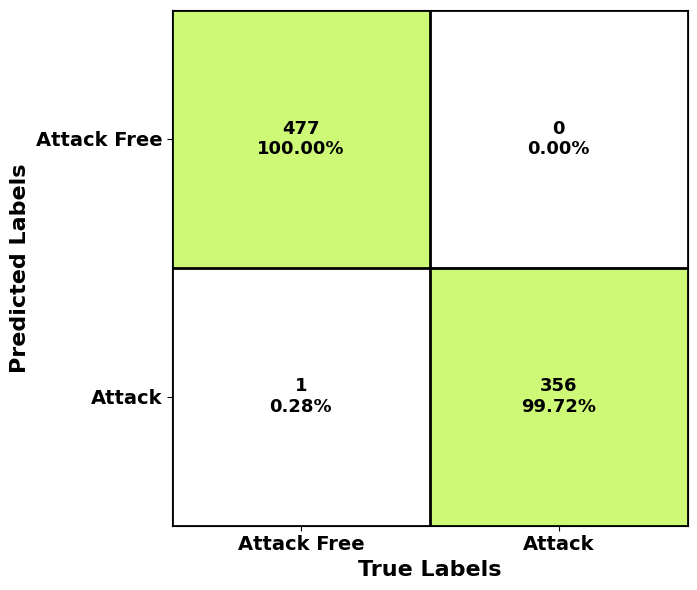

In [146]:
DATA_DIR = "Split_data/Test/Gen/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  2.00it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.84it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.29it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


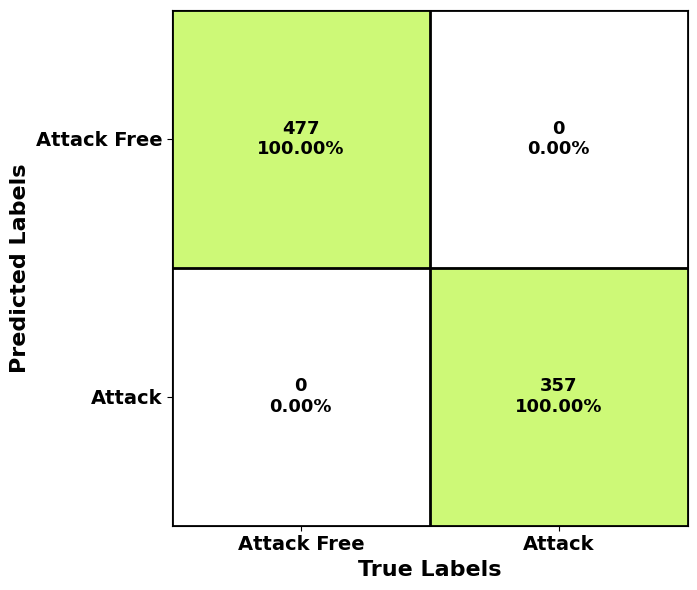

In [147]:
DATA_DIR = "Split_data/Test/Gen/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.76it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.73it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.28it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


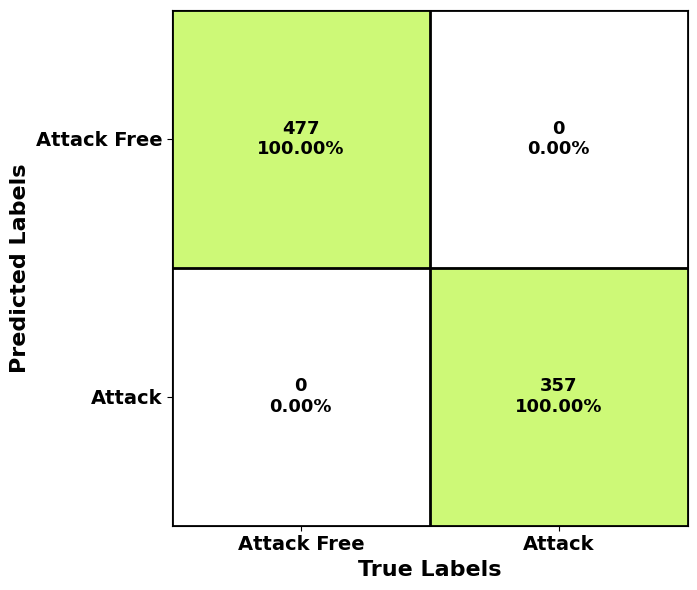

In [148]:
DATA_DIR = "Split_data/Test/Gen/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.77it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.70it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.27it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


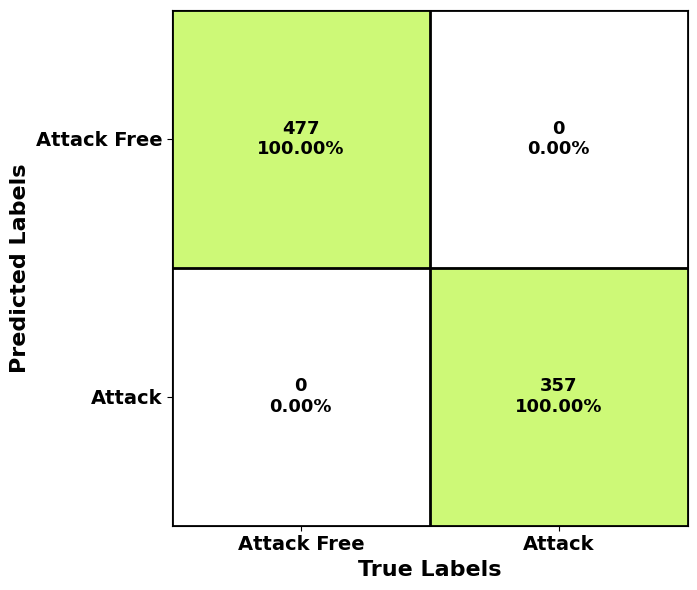

In [149]:
DATA_DIR = "Split_data/Test/Gen/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.80it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:03<00:00, 17.25it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


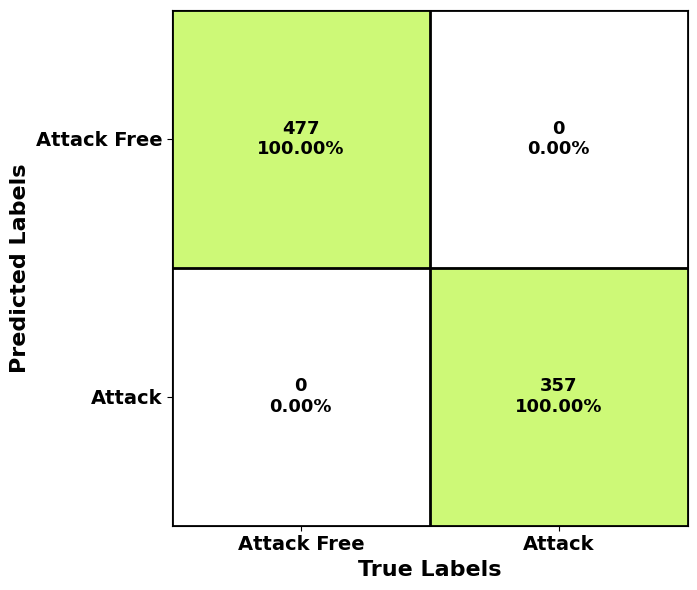

In [150]:
DATA_DIR = "Split_data/Test/Gen/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

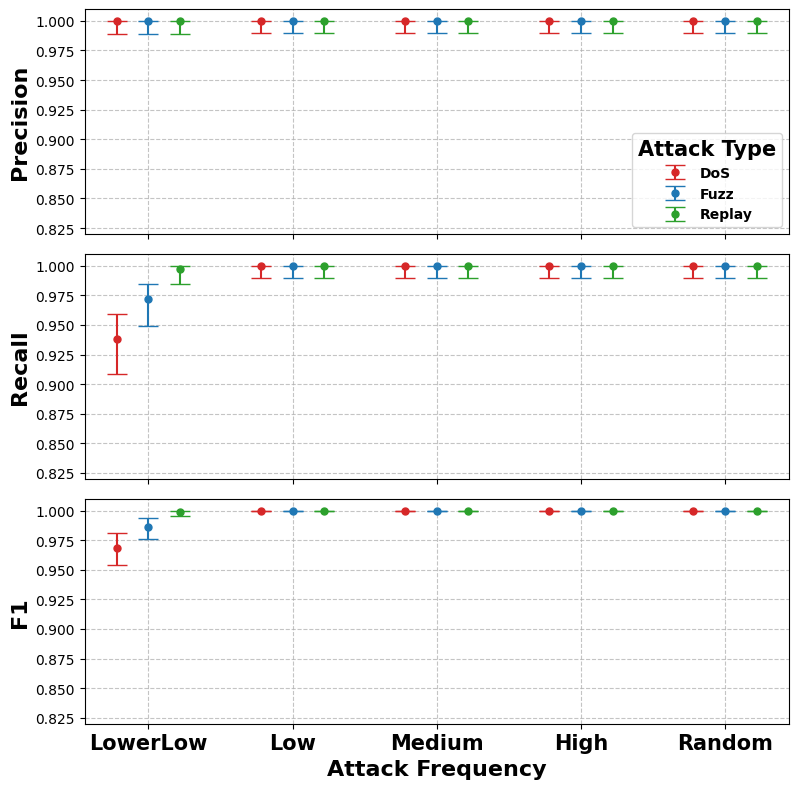

In [151]:
df = pd.DataFrame([
    # =====================================================
    # DoS
    # =====================================================
    ("DoS","LowerLow","Accuracy",0.9736,0.9604,0.9825),
    ("DoS","LowerLow","Precision",1.0000,0.9887,1.0000),
    ("DoS","LowerLow","Recall",0.9384,0.9085,0.9590),
    ("DoS","LowerLow","F1",0.9682,0.9543,0.9813),

    ("DoS","Low","Accuracy",1.0000,0.9954,1.0000),
    ("DoS","Low","Precision",1.0000,0.9894,1.0000),
    ("DoS","Low","Recall",1.0000,0.9894,1.0000),
    ("DoS","Low","F1",1.0000,1.0000,1.0000),

    ("DoS","Medium","Accuracy",1.0000,0.9954,1.0000),
    ("DoS","Medium","Precision",1.0000,0.9894,1.0000),
    ("DoS","Medium","Recall",1.0000,0.9894,1.0000),
    ("DoS","Medium","F1",1.0000,1.0000,1.0000),

    ("DoS","High","Accuracy",1.0000,0.9954,1.0000),
    ("DoS","High","Precision",1.0000,0.9894,1.0000),
    ("DoS","High","Recall",1.0000,0.9894,1.0000),
    ("DoS","High","F1",1.0000,1.0000,1.0000),

    ("DoS","Random","Accuracy",1.0000,0.9954,1.0000),
    ("DoS","Random","Precision",1.0000,0.9894,1.0000),
    ("DoS","Random","Recall",1.0000,0.9894,1.0000),
    ("DoS","Random","F1",1.0000,1.0000,1.0000),

    # =====================================================
    # Fuzz
    # =====================================================
    ("Fuzz","LowerLow","Accuracy",0.9880,0.9781,0.9935),
    ("Fuzz","LowerLow","Precision",1.0000,0.9891,1.0000),
    ("Fuzz","LowerLow","Recall",0.9720,0.9492,0.9847),
    ("Fuzz","LowerLow","F1",0.9858,0.9762,0.9941),

    ("Fuzz","Low","Accuracy",1.0000,0.9954,1.0000),
    ("Fuzz","Low","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","Low","Recall",1.0000,0.9894,1.0000),
    ("Fuzz","Low","F1",1.0000,1.0000,1.0000),

    ("Fuzz","Medium","Accuracy",1.0000,0.9954,1.0000),
    ("Fuzz","Medium","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","Medium","Recall",1.0000,0.9894,1.0000),
    ("Fuzz","Medium","F1",1.0000,1.0000,1.0000),

    ("Fuzz","High","Accuracy",1.0000,0.9954,1.0000),
    ("Fuzz","High","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","High","Recall",1.0000,0.9894,1.0000),
    ("Fuzz","High","F1",1.0000,1.0000,1.0000),

    ("Fuzz","Random","Accuracy",1.0000,0.9954,1.0000),
    ("Fuzz","Random","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","Random","Recall",1.0000,0.9894,1.0000),
    ("Fuzz","Random","F1",1.0000,1.0000,1.0000),

    # =====================================================
    # Replay
    # =====================================================
    ("Replay","LowerLow","Accuracy",0.9988,0.9932,0.9998),
    ("Replay","LowerLow","Precision",1.0000,0.9893,1.0000),
    ("Replay","LowerLow","Recall",0.9972,0.9843,0.9995),
    ("Replay","LowerLow","F1",0.9986,0.9955,1.0000),

    ("Replay","Low","Accuracy",1.0000,0.9954,1.0000),
    ("Replay","Low","Precision",1.0000,0.9894,1.0000),
    ("Replay","Low","Recall",1.0000,0.9894,1.0000),
    ("Replay","Low","F1",1.0000,1.0000,1.0000),

    ("Replay","Medium","Accuracy",1.0000,0.9954,1.0000),
    ("Replay","Medium","Precision",1.0000,0.9894,1.0000),
    ("Replay","Medium","Recall",1.0000,0.9894,1.0000),
    ("Replay","Medium","F1",1.0000,1.0000,1.0000),

    ("Replay","High","Accuracy",1.0000,0.9954,1.0000),
    ("Replay","High","Precision",1.0000,0.9894,1.0000),
    ("Replay","High","Recall",1.0000,0.9894,1.0000),
    ("Replay","High","F1",1.0000,1.0000,1.0000),

    ("Replay","Random","Accuracy",1.0000,0.9954,1.0000),
    ("Replay","Random","Precision",1.0000,0.9894,1.0000),
    ("Replay","Random","Recall",1.0000,0.9894,1.0000),
    ("Replay","Random","F1",1.0000,1.0000,1.0000),
], columns=["Attack", "Frequency", "Metric", "Value", "CI_L", "CI_H"])

plot_all_metrics_single_figure(df)

## Test on Silverado

## DoS

In [177]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainTeslaOnnx"
TIME_GAP = 90.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.17it/s]


Total validation samples: 817


ONNX Inference: 100%|██████████| 52/52 [00:06<00:00,  7.77it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9302  (95% CI: 0.9107, 0.9458)
Precision: 0.9036  (95% CI: 0.8689, 0.9299)
Recall   : 0.9371  (95% CI: 0.9067, 0.9581)
F1-score : 0.9201  (95% CI: 0.8982, 0.9379)


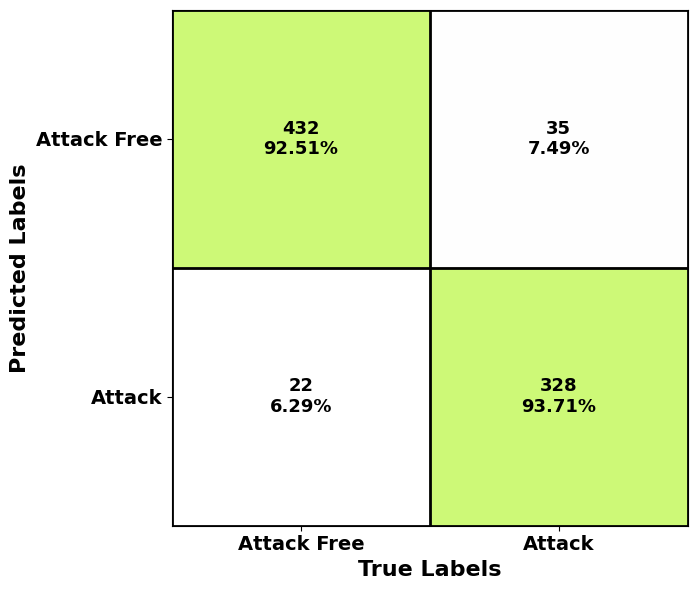

In [152]:
DATA_DIR = "Split_data/Test/Sil/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.25it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.76it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9358, 0.9687)


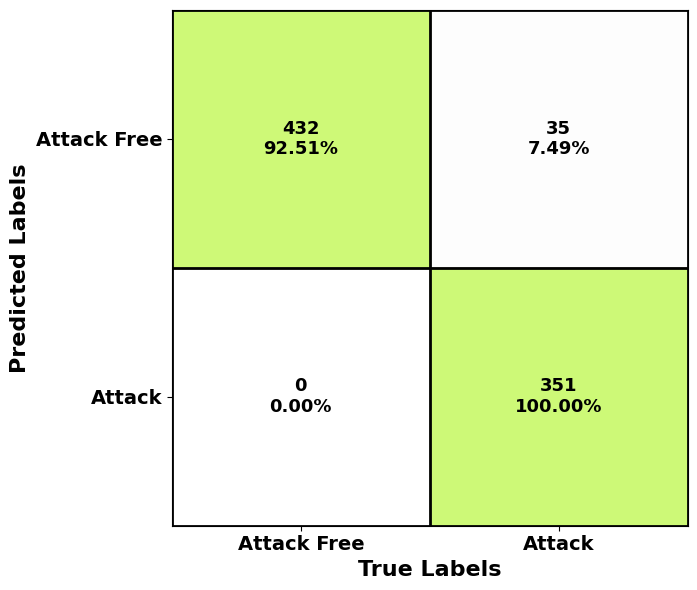

In [153]:
DATA_DIR = "Split_data/Test/Sil/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


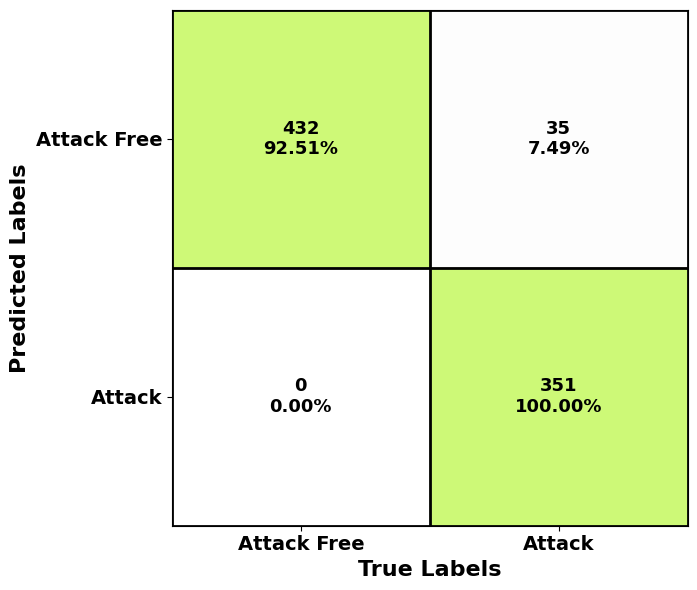

In [154]:
DATA_DIR = "Split_data/Test/Sil/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  9.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


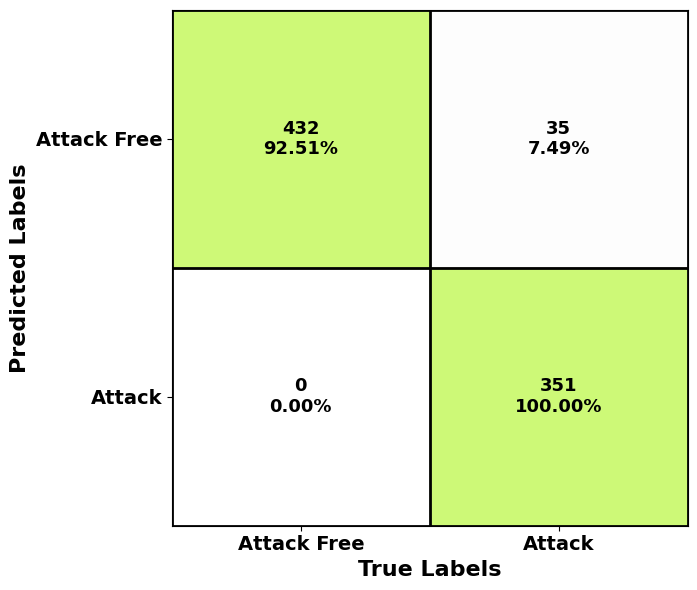

In [155]:
DATA_DIR = "Split_data/Test/Sil/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.89it/s]


Total validation samples: 817


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  9.08it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9410, 0.9690)
Precision: 0.9091  (95% CI: 0.8762, 0.9339)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9524  (95% CI: 0.9352, 0.9678)


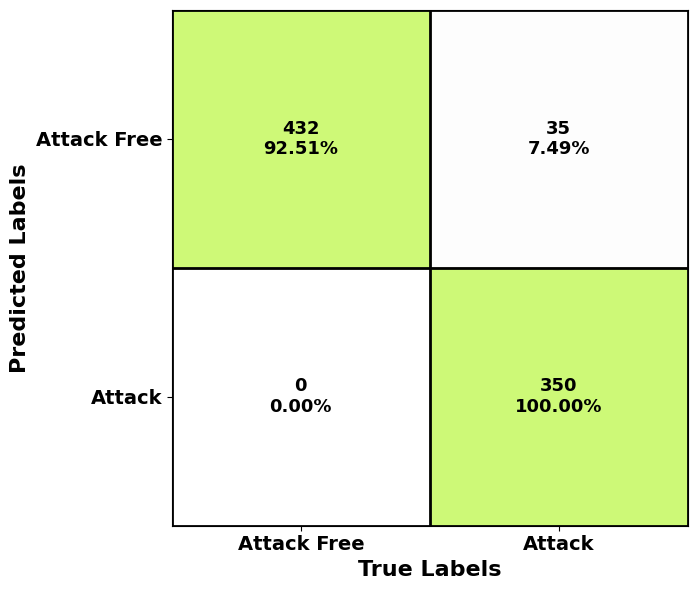

In [156]:
DATA_DIR = "Split_data/Test/Sil/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.74it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9401  (95% CI: 0.9217, 0.9544)
Precision: 0.9057  (95% CI: 0.8716, 0.9314)
Recall   : 0.9600  (95% CI: 0.9340, 0.9760)
F1-score : 0.9320  (95% CI: 0.9141, 0.9502)


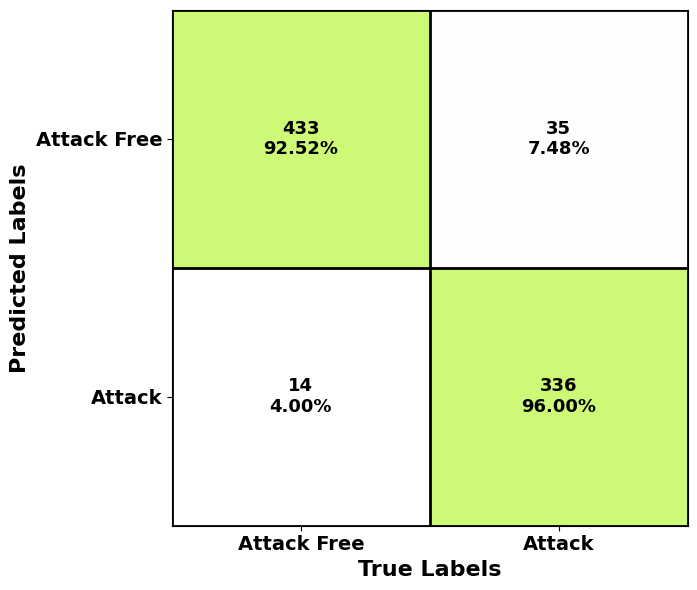

In [157]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.81it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9560  (95% CI: 0.9397, 0.9680)
Precision: 0.9091  (95% CI: 0.8762, 0.9339)
Recall   : 0.9972  (95% CI: 0.9840, 0.9995)
F1-score : 0.9511  (95% CI: 0.9341, 0.9674)


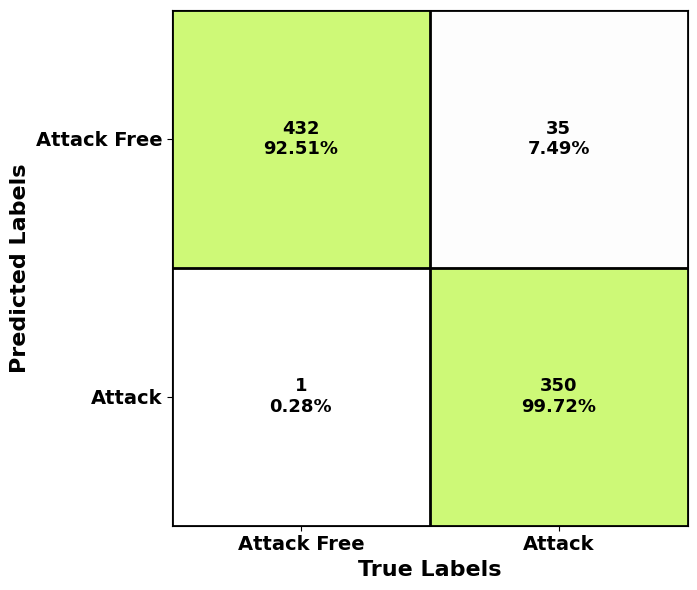

In [158]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.77it/s]


Total validation samples: 817


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.93it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9410, 0.9690)
Precision: 0.9091  (95% CI: 0.8762, 0.9339)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9524  (95% CI: 0.9348, 0.9665)


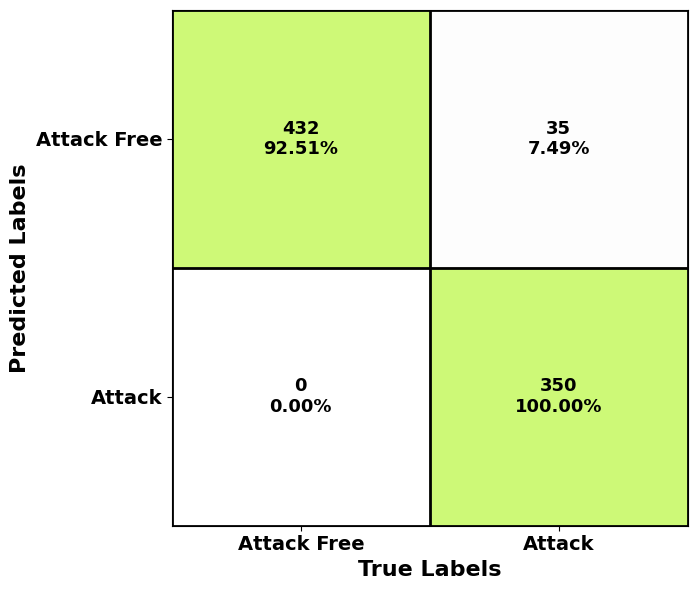

In [159]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.75it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.77it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9091  (95% CI: 0.8762, 0.9339)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9524  (95% CI: 0.9354, 0.9685)


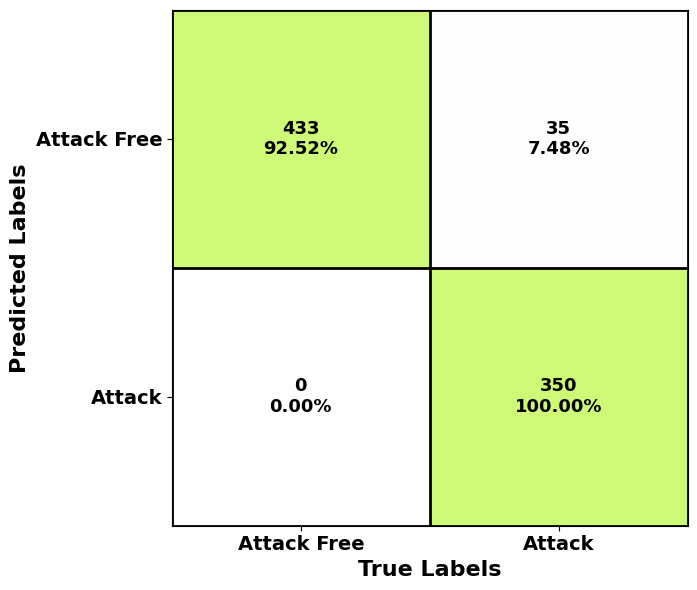

In [160]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.83it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.93it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


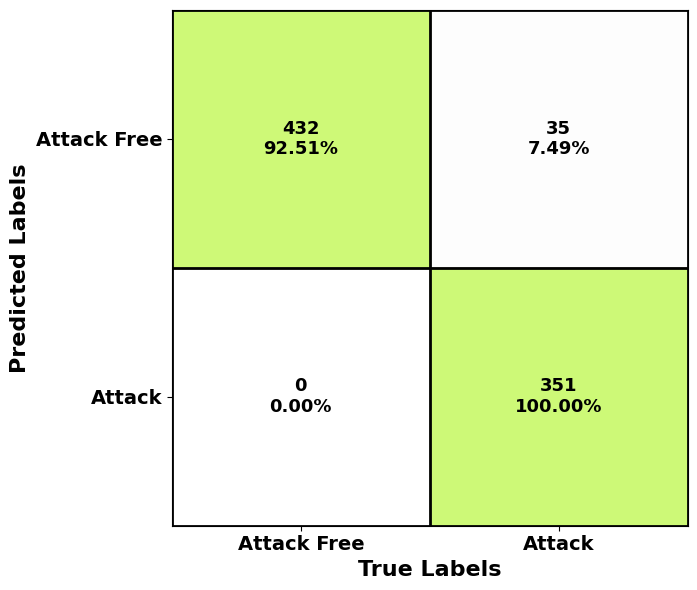

In [161]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]


Total validation samples: 817


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.82it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9510  (95% CI: 0.9340, 0.9638)
Precision: 0.9079  (95% CI: 0.8746, 0.9330)
Recall   : 0.9857  (95% CI: 0.9670, 0.9939)
F1-score : 0.9452  (95% CI: 0.9274, 0.9617)


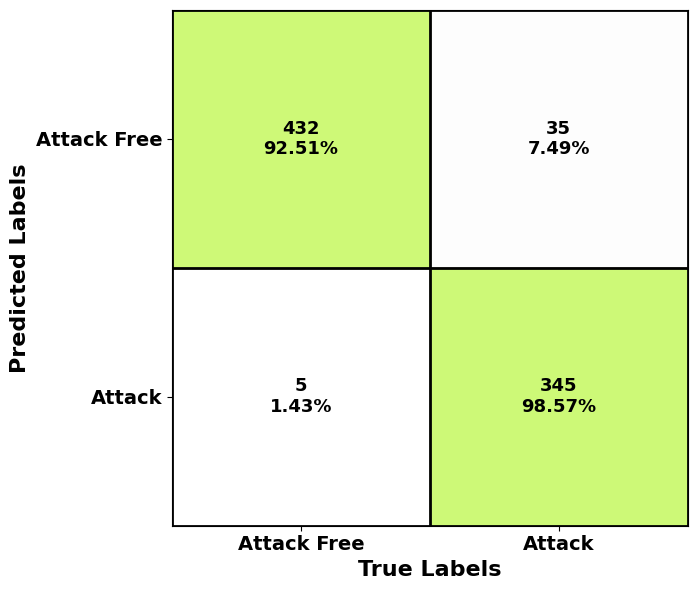

In [162]:
DATA_DIR = "Split_data/Test/Sil/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.87it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.90it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9091  (95% CI: 0.8762, 0.9339)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9524  (95% CI: 0.9354, 0.9685)


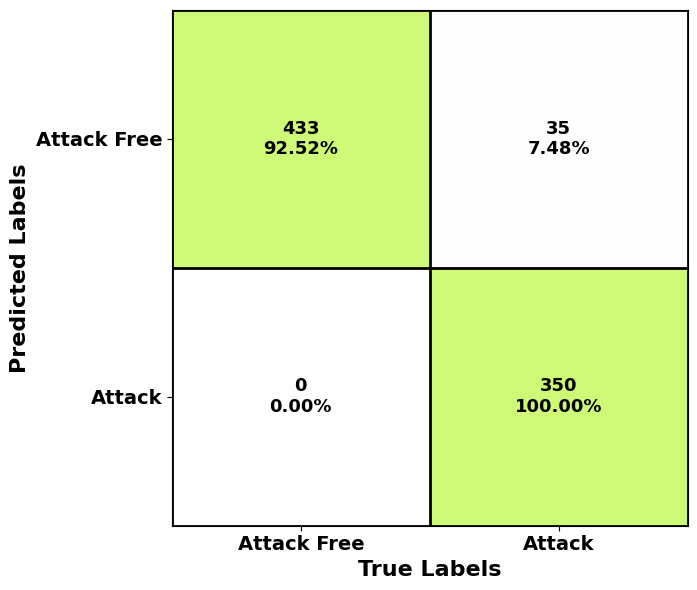

In [163]:
DATA_DIR = "Split_data/Test/Sil/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.84it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  9.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


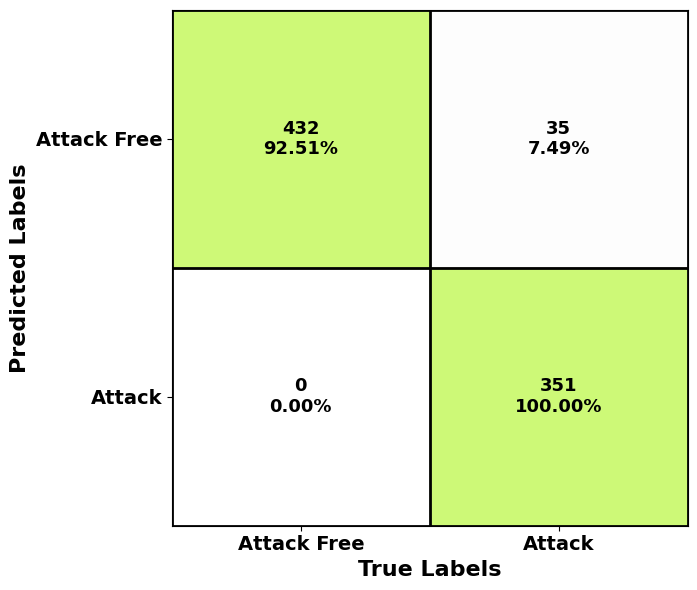

In [164]:
DATA_DIR = "Split_data/Test/Sil/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  8.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


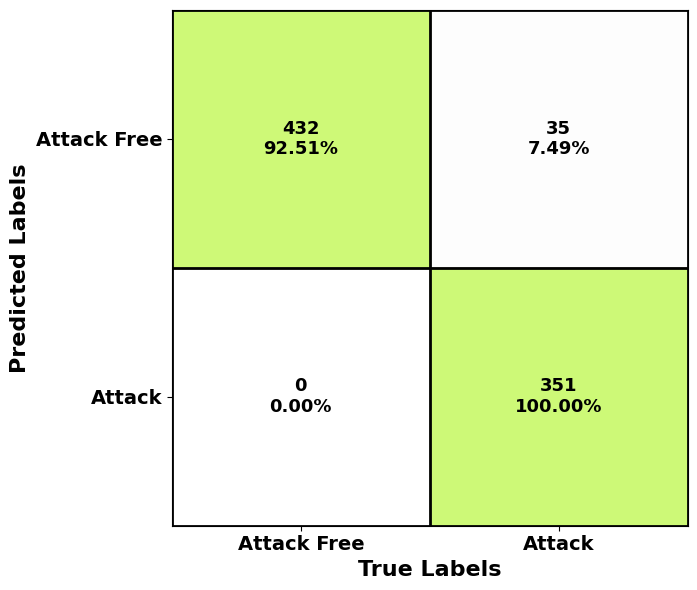

In [165]:
DATA_DIR = "Split_data/Test/Sil/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainTeslaOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.70it/s]


Total validation samples: 818


ONNX Inference: 100%|██████████| 52/52 [00:05<00:00,  9.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9572  (95% CI: 0.9411, 0.9691)
Precision: 0.9093  (95% CI: 0.8765, 0.9341)
Recall   : 1.0000  (95% CI: 0.9892, 1.0000)
F1-score : 0.9525  (95% CI: 0.9363, 0.9670)


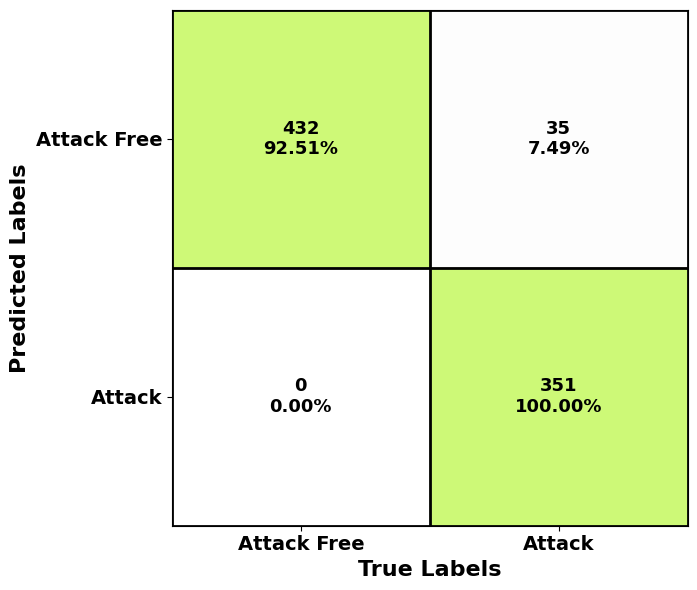

In [166]:
DATA_DIR = "Split_data/Test/Sil/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

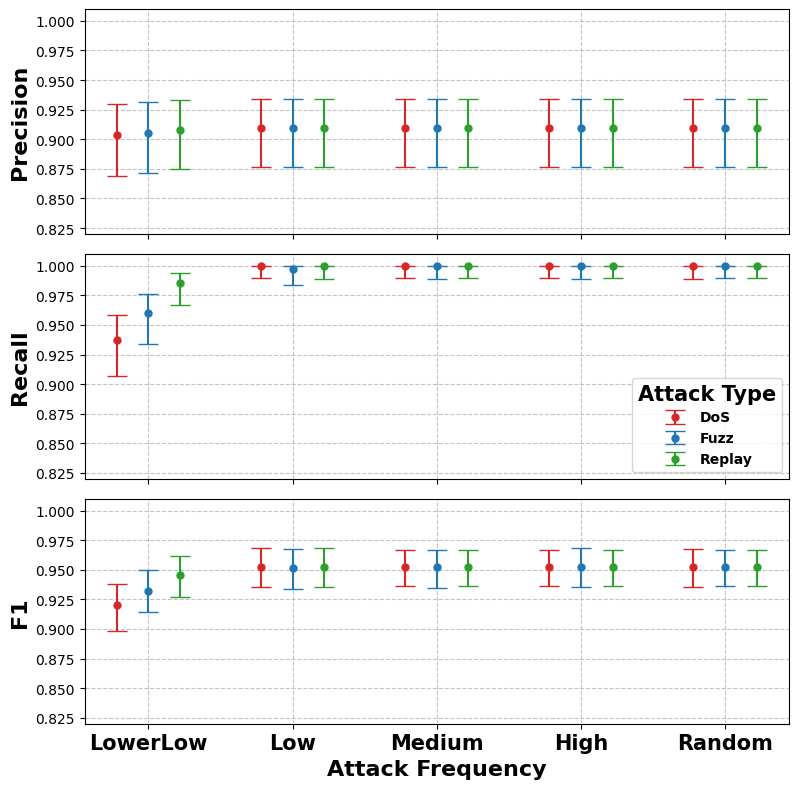

In [174]:
df = pd.DataFrame([
    # =====================================================
    # DoS
    # =====================================================
    ("DoS","LowerLow","Accuracy",0.9302,0.9107,0.9458),
    ("DoS","LowerLow","Precision",0.9036,0.8689,0.9299),
    ("DoS","LowerLow","Recall",0.9371,0.9067,0.9581),
    ("DoS","LowerLow","F1",0.9201,0.8982,0.9379),

    ("DoS","Low","Accuracy",0.9572,0.9411,0.9691),
    ("DoS","Low","Precision",0.9093,0.8765,0.9341),
    ("DoS","Low","Recall",1.0000,0.9892,1.0000),
    ("DoS","Low","F1",0.9525,0.9358,0.9687),

    ("DoS","Medium","Accuracy",0.9572,0.9411,0.9691),
    ("DoS","Medium","Precision",0.9093,0.8765,0.9341),
    ("DoS","Medium","Recall",1.0000,0.9892,1.0000),
    ("DoS","Medium","F1",0.9525,0.9363,0.9670),

    ("DoS","High","Accuracy",0.9572,0.9411,0.9691),
    ("DoS","High","Precision",0.9093,0.8765,0.9341),
    ("DoS","High","Recall",1.0000,0.9892,1.0000),
    ("DoS","High","F1",0.9525,0.9363,0.9670),

    ("DoS","Random","Accuracy",0.9572,0.9410,0.9690),
    ("DoS","Random","Precision",0.9091,0.8762,0.9339),
    ("DoS","Random","Recall",1.0000,0.9891,1.0000),
    ("DoS","Random","F1",0.9524,0.9352,0.9678),

    # =====================================================
    # Fuzz
    # =====================================================
    ("Fuzz","LowerLow","Accuracy",0.9401,0.9217,0.9544),
    ("Fuzz","LowerLow","Precision",0.9057,0.8716,0.9314),
    ("Fuzz","LowerLow","Recall",0.9600,0.9340,0.9760),
    ("Fuzz","LowerLow","F1",0.9320,0.9141,0.9502),

    ("Fuzz","Low","Accuracy",0.9560,0.9397,0.9680),
    ("Fuzz","Low","Precision",0.9091,0.8762,0.9339),
    ("Fuzz","Low","Recall",0.9972,0.9840,0.9995),
    ("Fuzz","Low","F1",0.9511,0.9341,0.9674),

    ("Fuzz","Medium","Accuracy",0.9572,0.9410,0.9690),
    ("Fuzz","Medium","Precision",0.9091,0.8762,0.9339),
    ("Fuzz","Medium","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","Medium","F1",0.9524,0.9348,0.9665),

    ("Fuzz","High","Accuracy",0.9572,0.9411,0.9691),
    ("Fuzz","High","Precision",0.9091,0.8762,0.9339),
    ("Fuzz","High","Recall",1.0000,0.9891,1.0000),
    ("Fuzz","High","F1",0.9524,0.9354,0.9685),

    ("Fuzz","Random","Accuracy",0.9572,0.9411,0.9691),
    ("Fuzz","Random","Precision",0.9093,0.8765,0.9341),
    ("Fuzz","Random","Recall",1.0000,0.9892,1.0000),
    ("Fuzz","Random","F1",0.9525,0.9363,0.9670),

    # =====================================================
    # Replay
    # =====================================================
    ("Replay","LowerLow","Accuracy",0.9510,0.9340,0.9638),
    ("Replay","LowerLow","Precision",0.9079,0.8746,0.9330),
    ("Replay","LowerLow","Recall",0.9857,0.9670,0.9939),
    ("Replay","LowerLow","F1",0.9452,0.9274,0.9617),

    ("Replay","Low","Accuracy",0.9572,0.9411,0.9691),
    ("Replay","Low","Precision",0.9091,0.8762,0.9339),
    ("Replay","Low","Recall",1.0000,0.9891,1.0000),
    ("Replay","Low","F1",0.9524,0.9354,0.9685),

    ("Replay","Medium","Accuracy",0.9572,0.9411,0.9691),
    ("Replay","Medium","Precision",0.9093,0.8765,0.9341),
    ("Replay","Medium","Recall",1.0000,0.9892,1.0000),
    ("Replay","Medium","F1",0.9525,0.9363,0.9670),

    ("Replay","High","Accuracy",0.9572,0.9411,0.9691),
    ("Replay","High","Precision",0.9093,0.8765,0.9341),
    ("Replay","High","Recall",1.0000,0.9892,1.0000),
    ("Replay","High","F1",0.9525,0.9363,0.9670),

    ("Replay","Random","Accuracy",0.9572,0.9411,0.9691),
    ("Replay","Random","Precision",0.9093,0.8765,0.9341),
    ("Replay","Random","Recall",1.0000,0.9892,1.0000),
    ("Replay","Random","F1",0.9525,0.9363,0.9670),
], columns=["Attack", "Frequency", "Metric", "Value", "CI_L", "CI_H"])


plot_all_metrics_single_figure(df)

## Train on Gnnesis

## Test on Kia

## DoS

In [178]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainGenOnnx"
TIME_GAP = 100.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.42it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9313  (95% CI: 0.9116, 0.9468)
Precision: 0.9364  (95% CI: 0.9047, 0.9580)
Recall   : 0.9009  (95% CI: 0.8647, 0.9282)
F1-score : 0.9183  (95% CI: 0.8954, 0.9381)


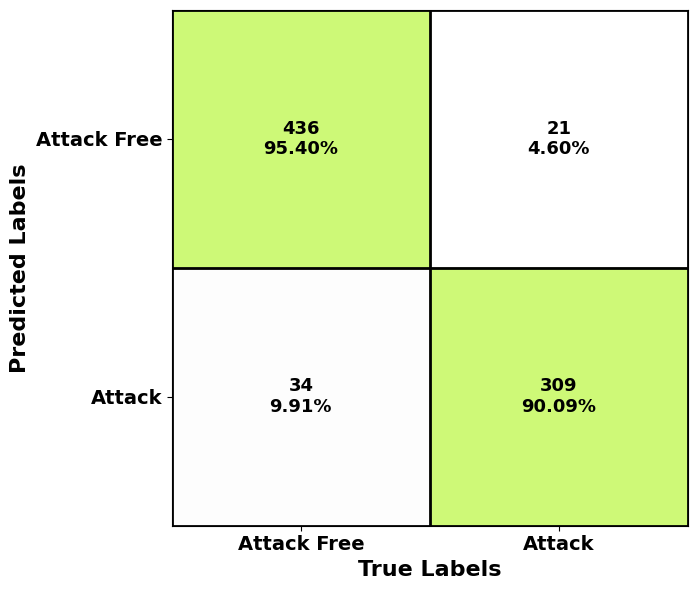

In [179]:
DATA_DIR = "Split_data/Test/Kia/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.56it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


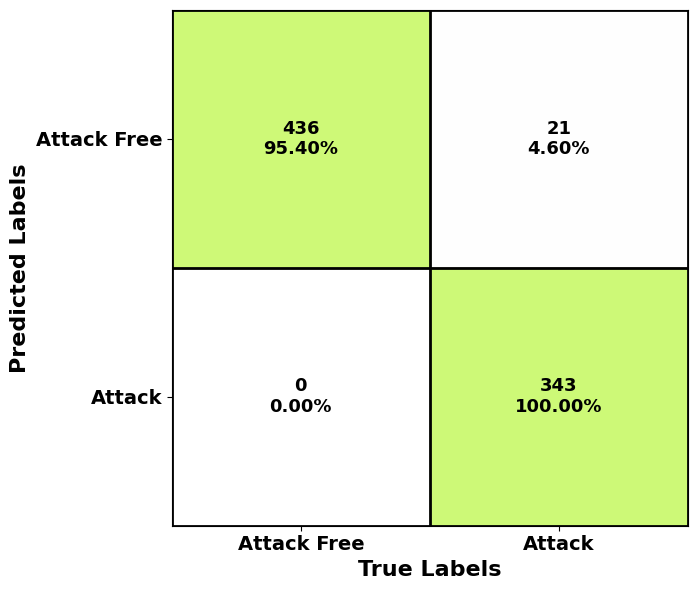

In [180]:
DATA_DIR = "Split_data/Test/Kia/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.96it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9568, 0.9825)


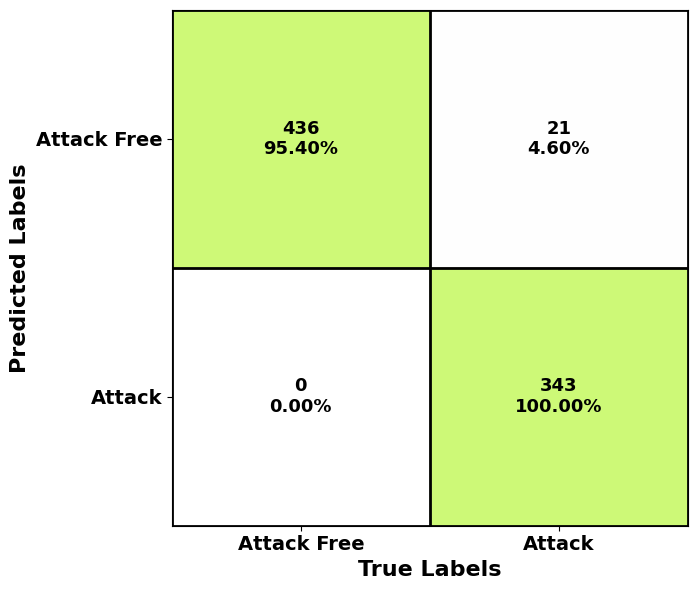

In [181]:
DATA_DIR = "Split_data/Test/Kia/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


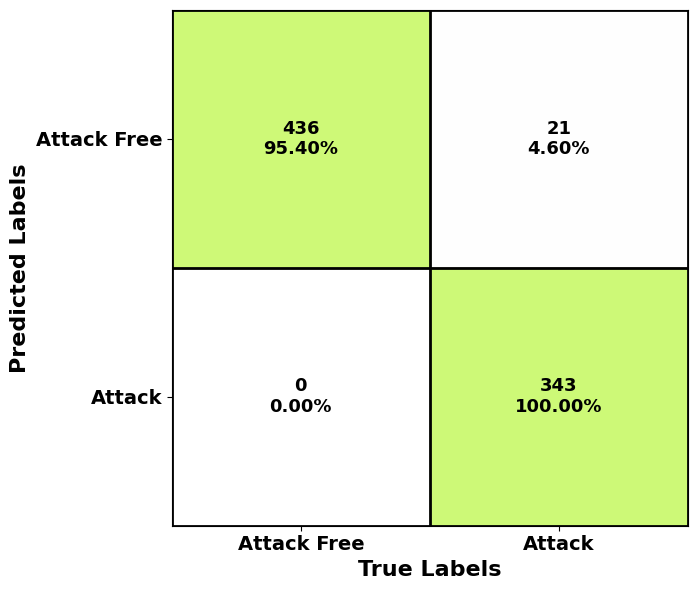

In [182]:
DATA_DIR = "Split_data/Test/Kia/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9816)


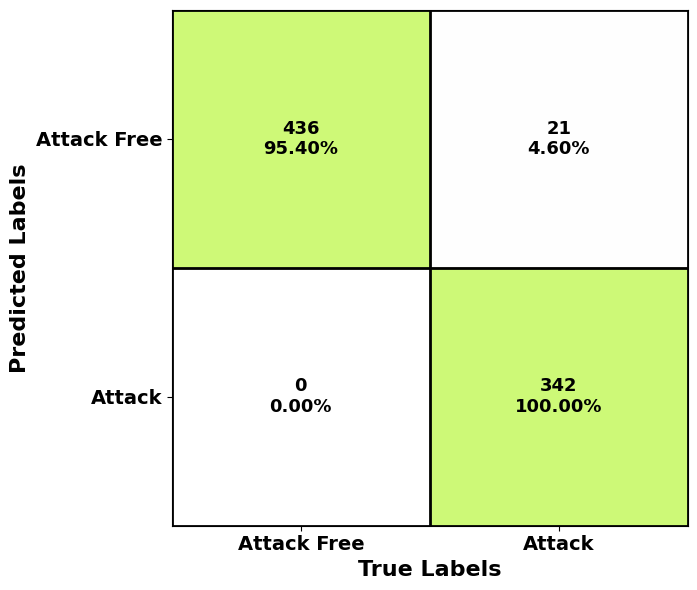

In [183]:
DATA_DIR = "Split_data/Test/Kia/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9513  (95% CI: 0.9341, 0.9641)
Precision: 0.9393  (95% CI: 0.9090, 0.9600)
Recall   : 0.9475  (95% CI: 0.9186, 0.9666)
F1-score : 0.9434  (95% CI: 0.9242, 0.9598)


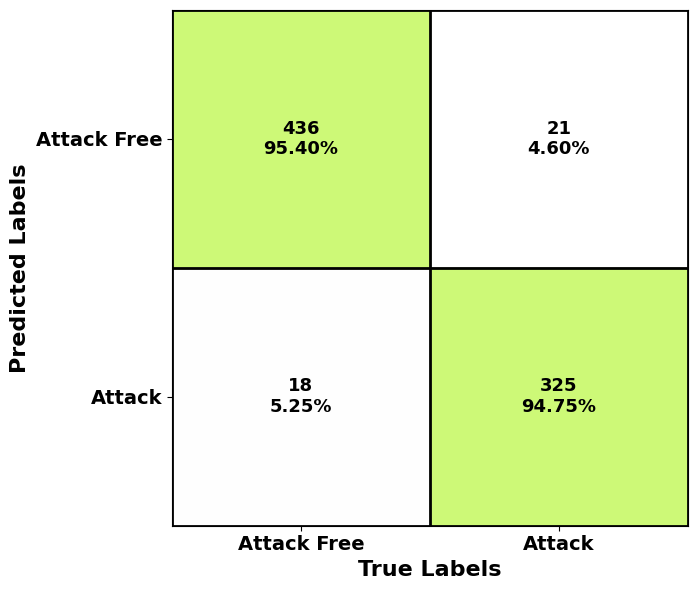

In [184]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.59it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9725  (95% CI: 0.9587, 0.9818)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 0.9971  (95% CI: 0.9837, 0.9995)
F1-score : 0.9688  (95% CI: 0.9551, 0.9811)


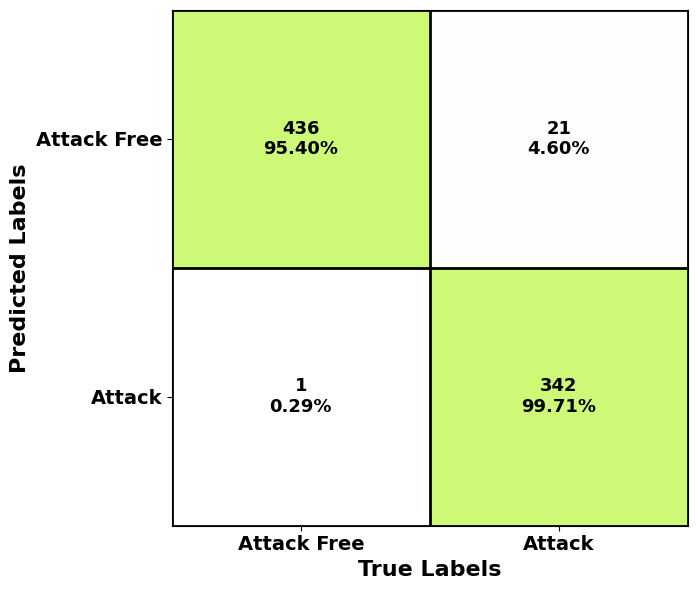

In [185]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


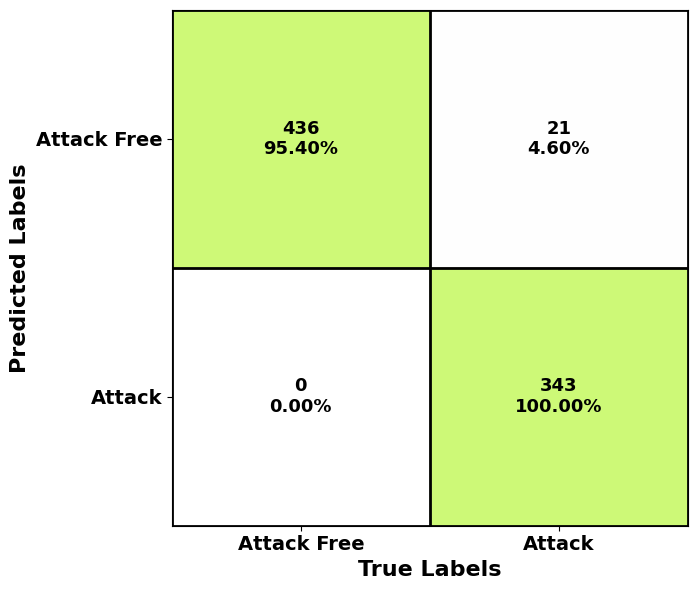

In [186]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.91it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


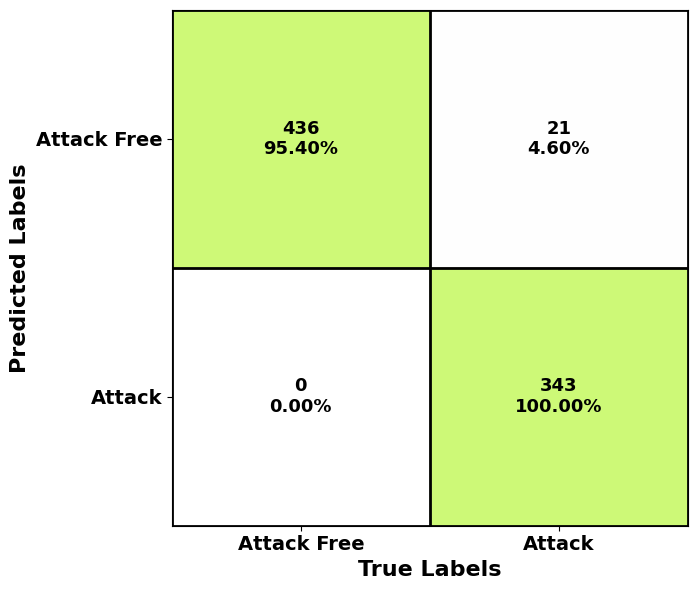

In [187]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.52it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.96it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9831)


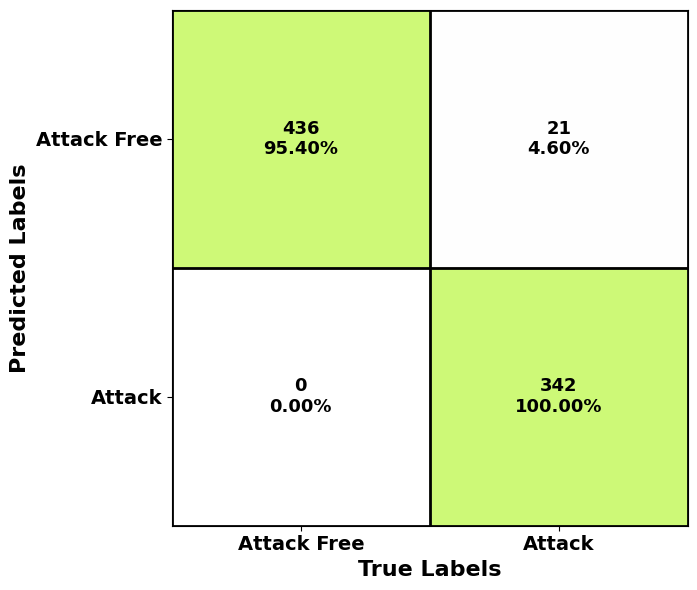

In [188]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.41it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9712  (95% CI: 0.9572, 0.9808)
Precision: 0.9420  (95% CI: 0.9129, 0.9617)
Recall   : 0.9942  (95% CI: 0.9790, 0.9984)
F1-score : 0.9674  (95% CI: 0.9532, 0.9795)


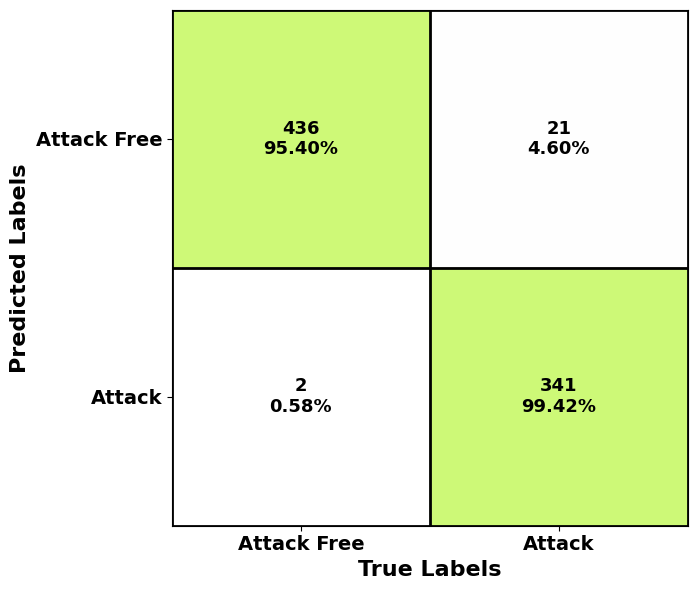

In [189]:
DATA_DIR = "Split_data/Test/Kia/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.59it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


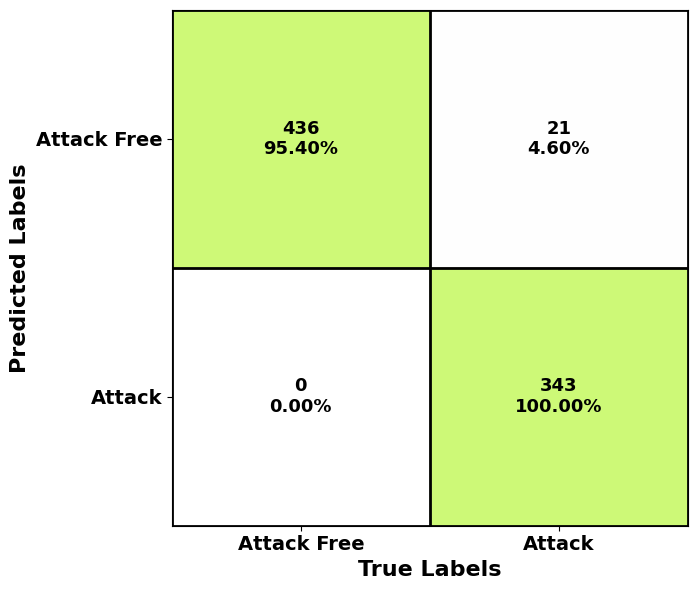

In [190]:
DATA_DIR = "Split_data/Test/Kia/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.97it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


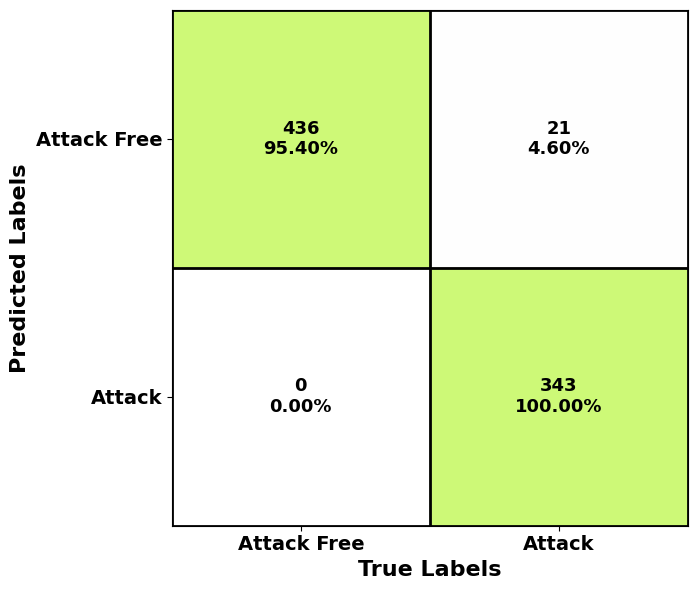

In [191]:
DATA_DIR = "Split_data/Test/Kia/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.95it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


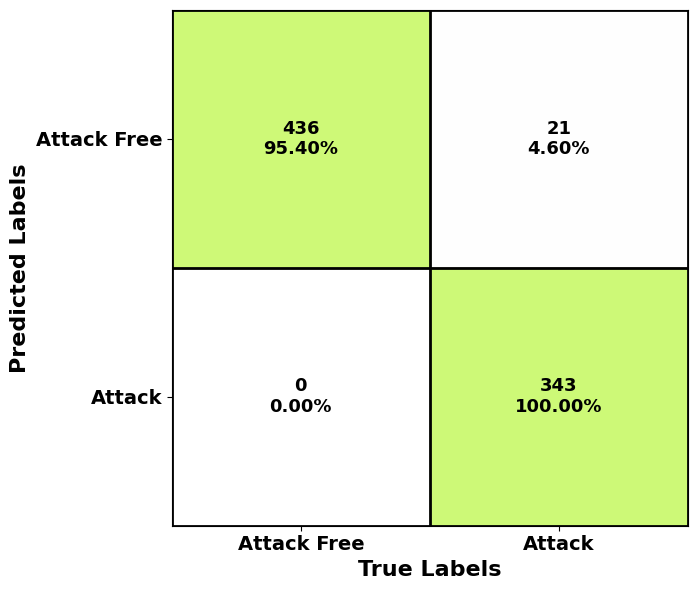

In [192]:
DATA_DIR = "Split_data/Test/Kia/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.56it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.96it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


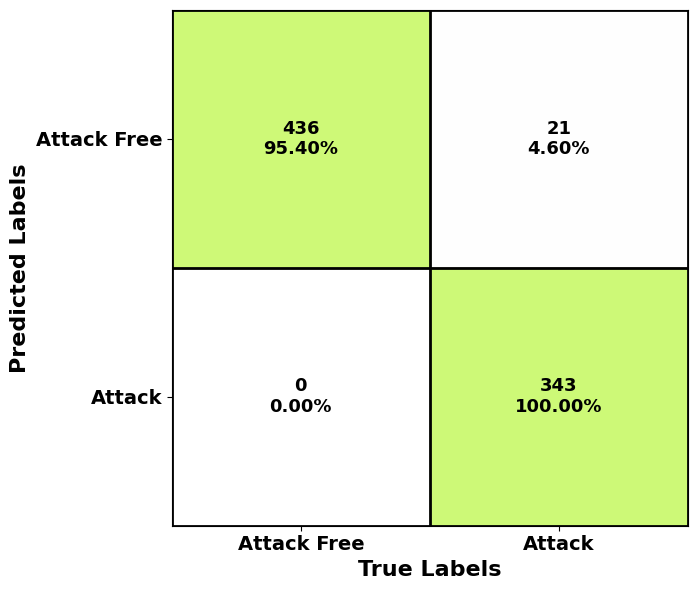

In [193]:
DATA_DIR = "Split_data/Test/Kia/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

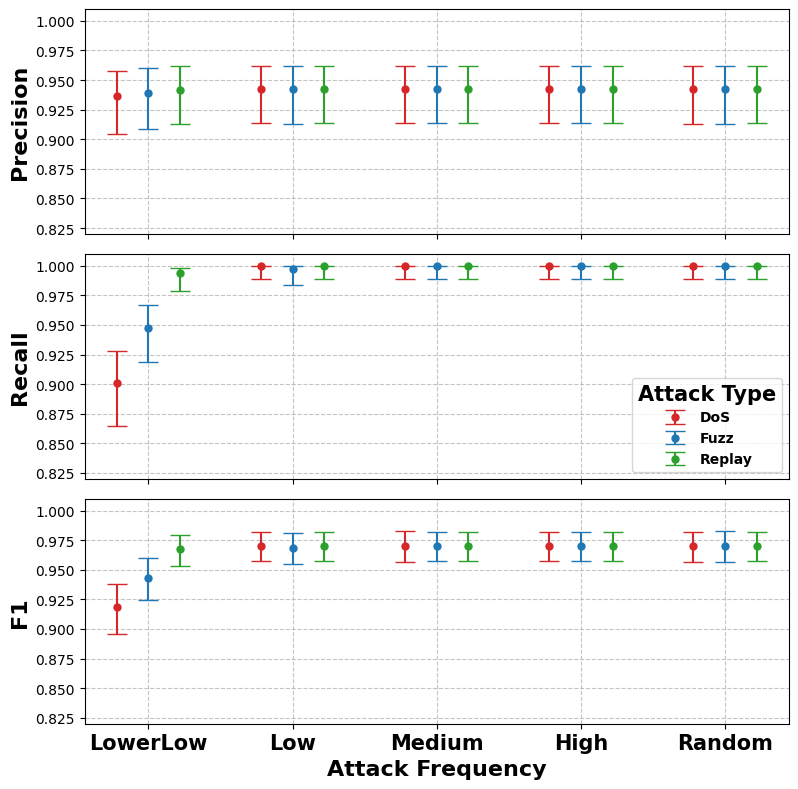

In [228]:
data = [
    # ---------------- DoS ----------------
    ("DoS","LowerLow","Precision",0.9364,0.9047,0.9580),
    ("DoS","LowerLow","Recall",   0.9009,0.8647,0.9282),
    ("DoS","LowerLow","F1",       0.9183,0.8954,0.9381),

    ("DoS","Low","Precision",0.9423,0.9134,0.9620),
    ("DoS","Low","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Low","F1",       0.9703,0.9574,0.9823),

    ("DoS","Medium","Precision",0.9423,0.9134,0.9620),
    ("DoS","Medium","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Medium","F1",       0.9703,0.9568,0.9825),

    ("DoS","High","Precision",0.9423,0.9134,0.9620),
    ("DoS","High","Recall",   1.0000,0.9889,1.0000),
    ("DoS","High","F1",       0.9703,0.9574,0.9823),

    ("DoS","Random","Precision",0.9421,0.9132,0.9619),
    ("DoS","Random","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Random","F1",       0.9702,0.9568,0.9816),

    # ---------------- Fuzz ----------------
    ("Fuzz","LowerLow","Precision",0.9393,0.9090,0.9600),
    ("Fuzz","LowerLow","Recall",   0.9475,0.9186,0.9666),
    ("Fuzz","LowerLow","F1",       0.9434,0.9242,0.9598),

    ("Fuzz","Low","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Low","Recall",   0.9971,0.9837,0.9995),
    ("Fuzz","Low","F1",       0.9688,0.9551,0.9811),

    ("Fuzz","Medium","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","Medium","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","Medium","F1",       0.9703,0.9574,0.9823),

    ("Fuzz","High","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","High","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","High","F1",       0.9703,0.9574,0.9823),

    ("Fuzz","Random","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Random","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","Random","F1",       0.9702,0.9568,0.9831),

    # ---------------- Replay ----------------
    ("Replay","LowerLow","Precision",0.9420,0.9129,0.9617),
    ("Replay","LowerLow","Recall",   0.9942,0.9790,0.9984),
    ("Replay","LowerLow","F1",       0.9674,0.9532,0.9795),

    ("Replay","Low","Precision",0.9423,0.9134,0.9620),
    ("Replay","Low","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Low","F1",       0.9703,0.9574,0.9823),

    ("Replay","Medium","Precision",0.9423,0.9134,0.9620),
    ("Replay","Medium","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Medium","F1",       0.9703,0.9574,0.9823),

    ("Replay","High","Precision",0.9423,0.9134,0.9620),
    ("Replay","High","Recall",   1.0000,0.9889,1.0000),
    ("Replay","High","F1",       0.9703,0.9574,0.9823),

    ("Replay","Random","Precision",0.9423,0.9134,0.9620),
    ("Replay","Random","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Random","F1",       0.9703,0.9574,0.9823),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)

## Test on Tesla

## DoS

In [194]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainGenOnnx"
TIME_GAP = 83.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.49it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.23it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9061  (95% CI: 0.8840, 0.9243)
Precision: 0.8689  (95% CI: 0.8304, 0.8996)
Recall   : 0.9191  (95% CI: 0.8855, 0.9434)
F1-score : 0.8933  (95% CI: 0.8679, 0.9163)


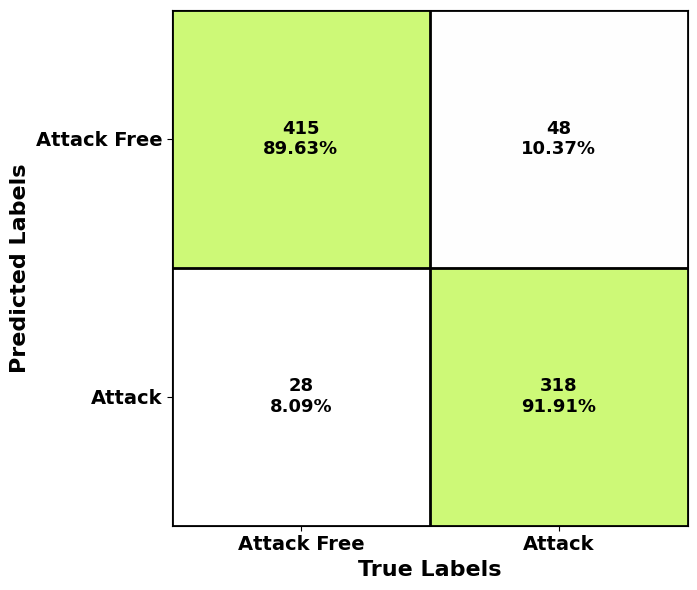

In [195]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9170, 0.9542)


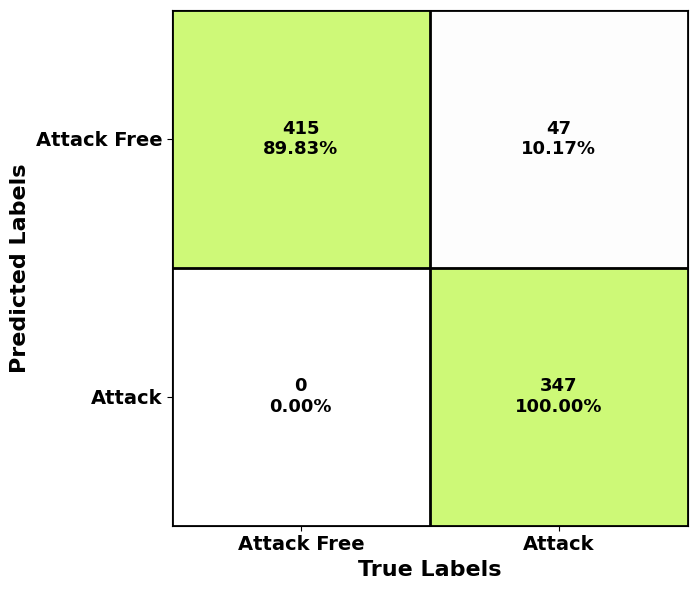

In [196]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.18it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


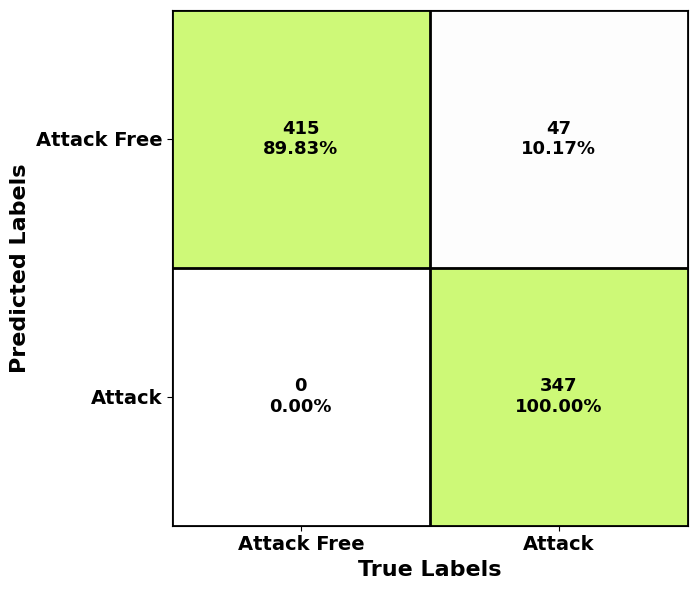

In [197]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9170, 0.9542)


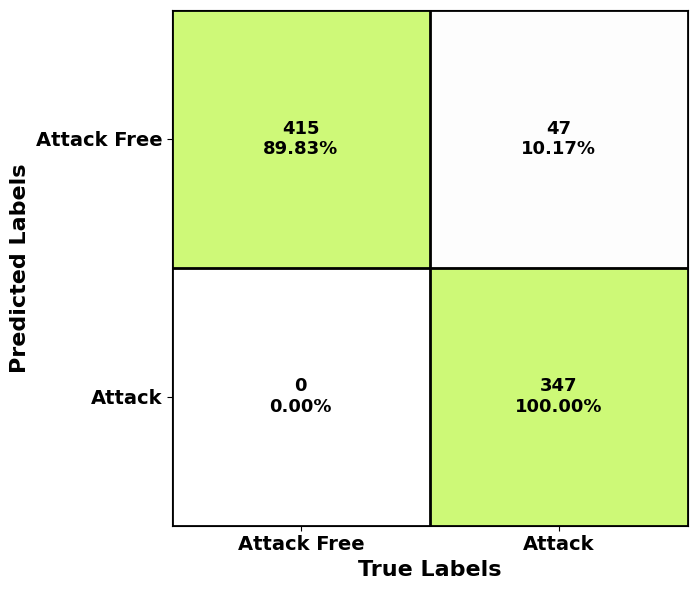

In [198]:
DATA_DIR = "Split_data/Test/Tesla/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.18it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9170, 0.9542)


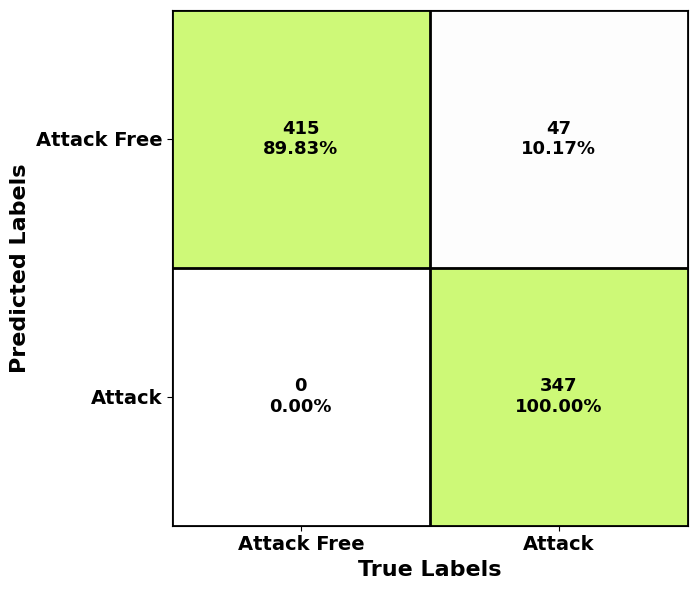

In [199]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.23it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9382  (95% CI: 0.9194, 0.9528)
Precision: 0.8795  (95% CI: 0.8434, 0.9082)
Recall   : 0.9913  (95% CI: 0.9748, 0.9970)
F1-score : 0.9321  (95% CI: 0.9135, 0.9499)


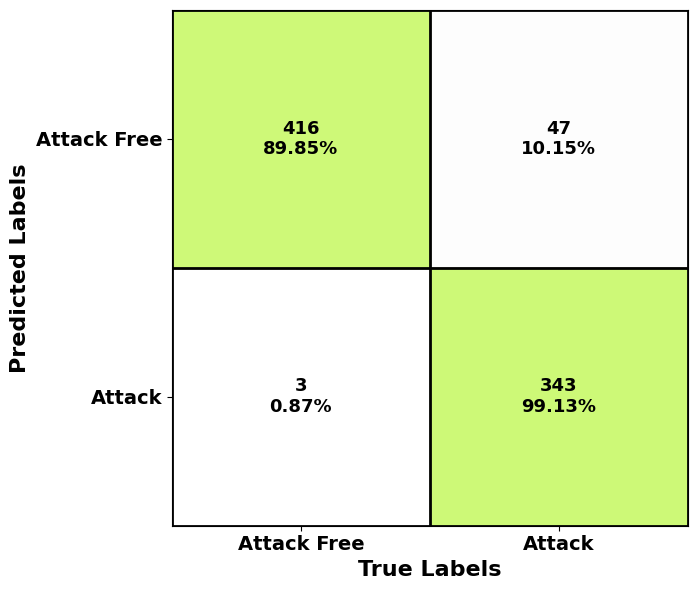

In [200]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.51it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.17it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9407  (95% CI: 0.9222, 0.9550)
Precision: 0.8804  (95% CI: 0.8446, 0.9089)
Recall   : 0.9971  (95% CI: 0.9839, 0.9995)
F1-score : 0.9351  (95% CI: 0.9167, 0.9529)


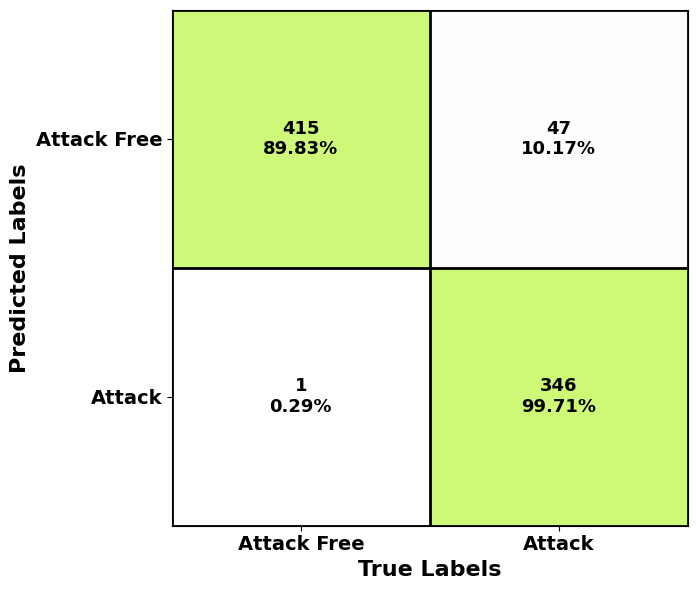

In [201]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.16it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


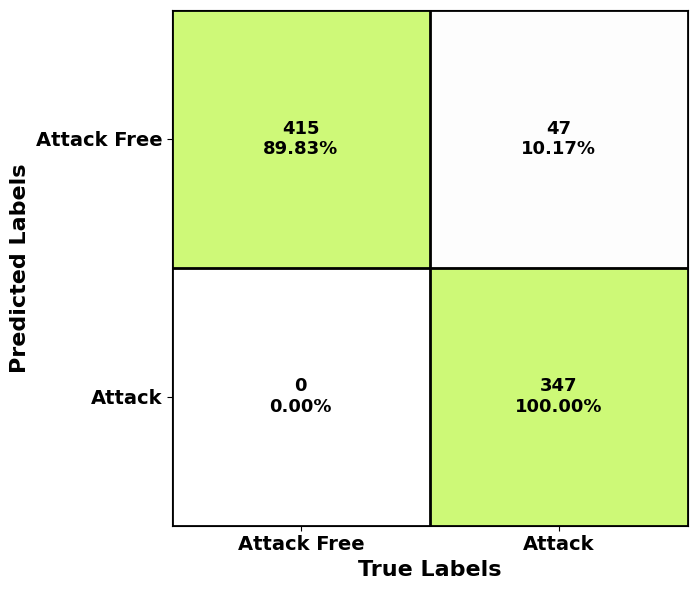

In [202]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.49it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


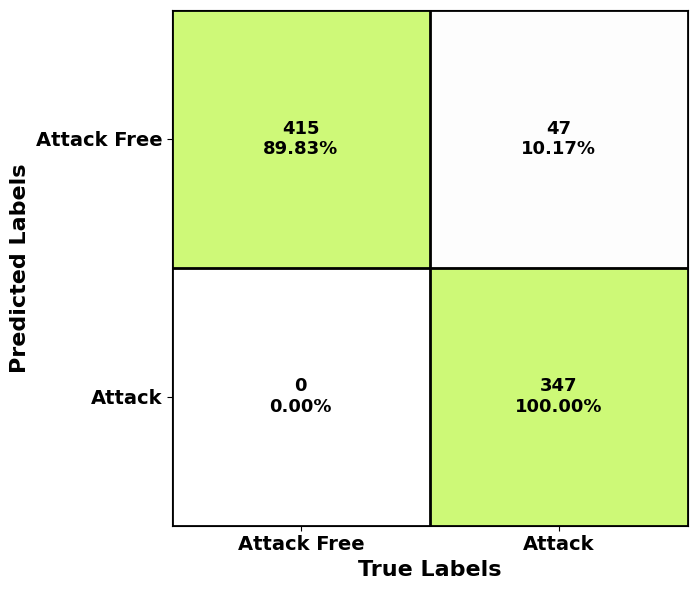

In [203]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.38it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.10it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


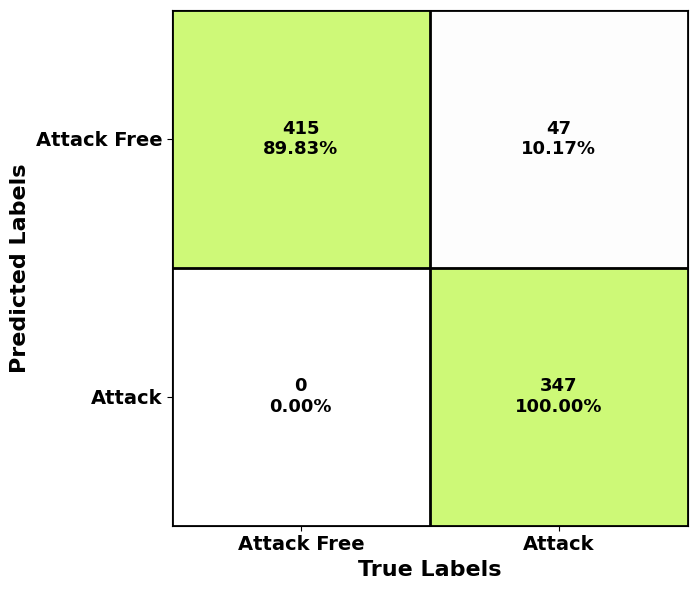

In [204]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.44it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8804  (95% CI: 0.8446, 0.9089)
Recall   : 1.0000  (95% CI: 0.9890, 1.0000)
F1-score : 0.9364  (95% CI: 0.9183, 0.9540)


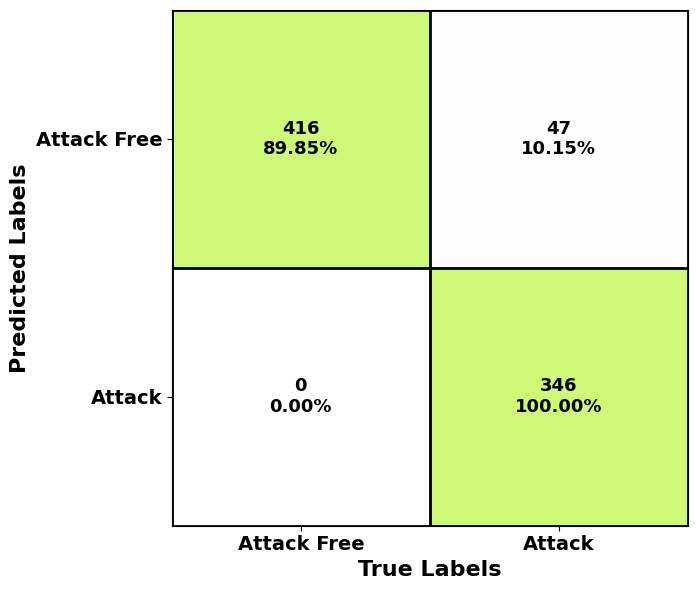

In [205]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.52it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


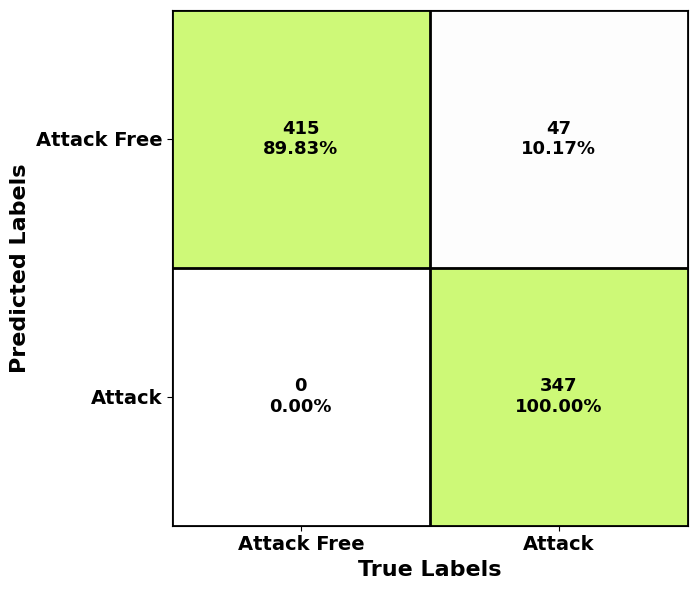

In [206]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.40it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.13it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


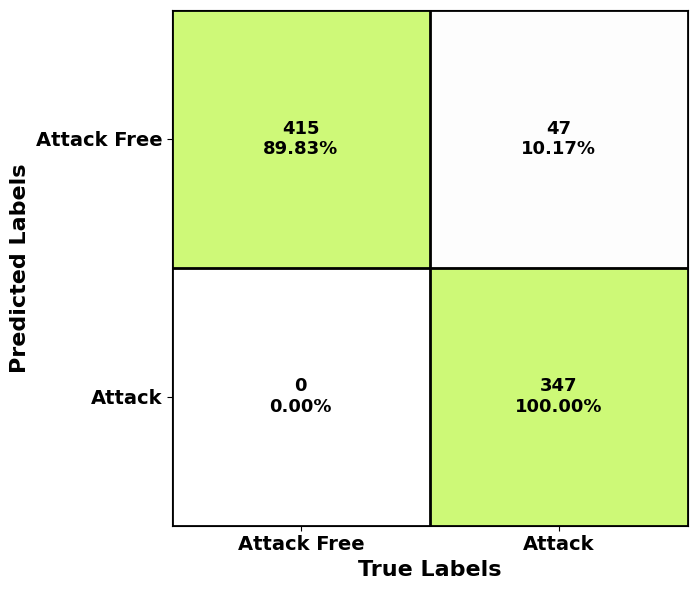

In [207]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


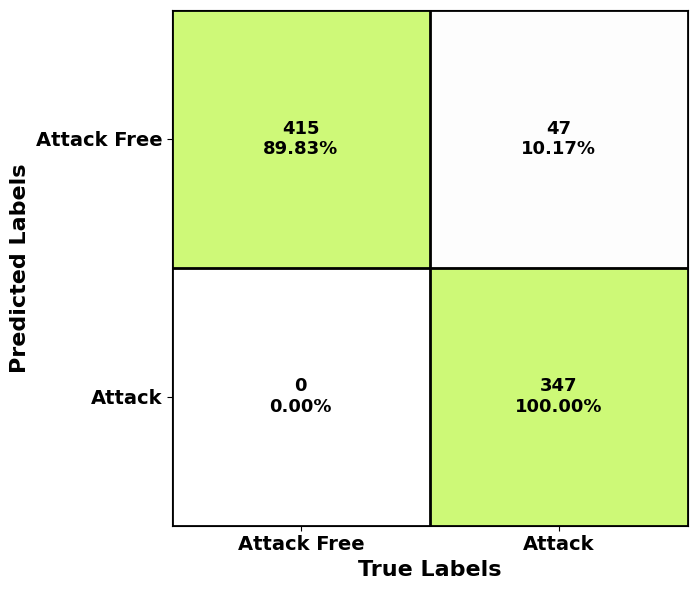

In [208]:
DATA_DIR = "Split_data/Test/Tesla/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


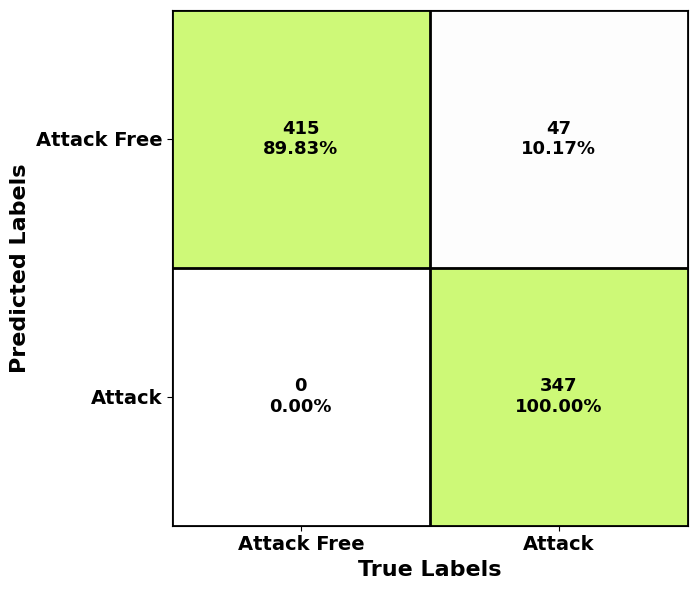

In [209]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

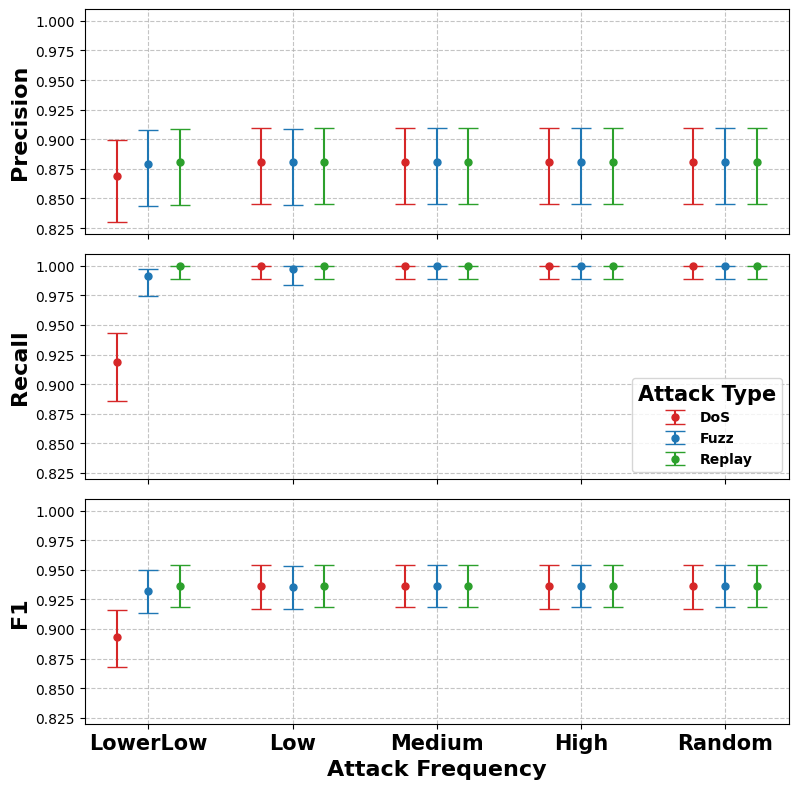

In [229]:
data = [
    # ================= DoS =================
    ("DoS","LowerLow","Precision",0.8689,0.8304,0.8996),
    ("DoS","LowerLow","Recall",   0.9191,0.8855,0.9434),
    ("DoS","LowerLow","F1",       0.8933,0.8679,0.9163),

    ("DoS","Low","Precision",0.8807,0.8450,0.9091),
    ("DoS","Low","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Low","F1",       0.9366,0.9170,0.9542),

    ("DoS","Medium","Precision",0.8807,0.8450,0.9091),
    ("DoS","Medium","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Medium","F1",       0.9366,0.9186,0.9541),

    ("DoS","High","Precision",0.8807,0.8450,0.9091),
    ("DoS","High","Recall",   1.0000,0.9891,1.0000),
    ("DoS","High","F1",       0.9366,0.9170,0.9542),

    ("DoS","Random","Precision",0.8807,0.8450,0.9091),
    ("DoS","Random","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Random","F1",       0.9366,0.9170,0.9542),

    # ================= Fuzz =================
    ("Fuzz","LowerLow","Precision",0.8795,0.8434,0.9082),
    ("Fuzz","LowerLow","Recall",   0.9913,0.9748,0.9970),
    ("Fuzz","LowerLow","F1",       0.9321,0.9135,0.9499),

    ("Fuzz","Low","Precision",0.8804,0.8446,0.9089),
    ("Fuzz","Low","Recall",   0.9971,0.9839,0.9995),
    ("Fuzz","Low","F1",       0.9351,0.9167,0.9529),

    ("Fuzz","Medium","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","Medium","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","Medium","F1",       0.9366,0.9186,0.9541),

    ("Fuzz","High","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","High","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","High","F1",       0.9366,0.9186,0.9541),

    ("Fuzz","Random","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","Random","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","Random","F1",       0.9366,0.9186,0.9541),

    # ================= Replay =================
    ("Replay","LowerLow","Precision",0.8804,0.8446,0.9089),
    ("Replay","LowerLow","Recall",   1.0000,0.9890,1.0000),
    ("Replay","LowerLow","F1",       0.9364,0.9183,0.9540),

    ("Replay","Low","Precision",0.8807,0.8450,0.9091),
    ("Replay","Low","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Low","F1",       0.9366,0.9186,0.9541),

    ("Replay","Medium","Precision",0.8807,0.8450,0.9091),
    ("Replay","Medium","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Medium","F1",       0.9366,0.9186,0.9541),

    ("Replay","High","Precision",0.8807,0.8450,0.9091),
    ("Replay","High","Recall",   1.0000,0.9891,1.0000),
    ("Replay","High","F1",       0.9366,0.9186,0.9541),

    ("Replay","Random","Precision",0.8807,0.8450,0.9091),
    ("Replay","Random","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Random","F1",       0.9366,0.9186,0.9541),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)

## Test on Silverado

## DoS

In [210]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainGenOnnx"
TIME_GAP = 90.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.25it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.28it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9295  (95% CI: 0.9110, 0.9444)
Precision: 0.9073  (95% CI: 0.8748, 0.9320)
Recall   : 0.9306  (95% CI: 0.9009, 0.9519)
F1-score : 0.9188  (95% CI: 0.8985, 0.9377)


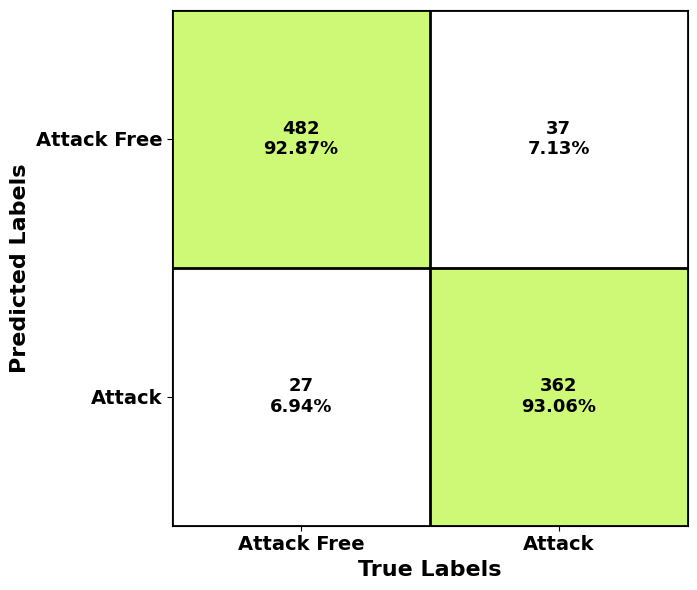

In [211]:
DATA_DIR = "Split_data/Test/Sil/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.25it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.25it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9401, 0.9697)


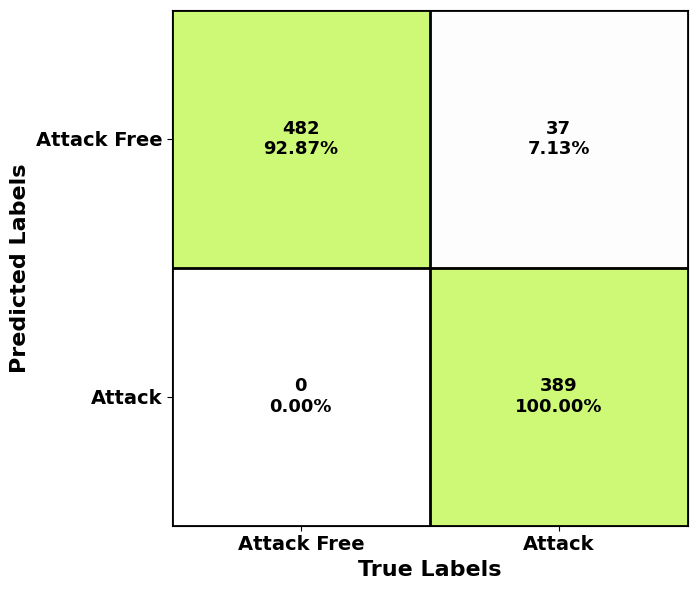

In [212]:
DATA_DIR = "Split_data/Test/Sil/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.19it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9385, 0.9681)


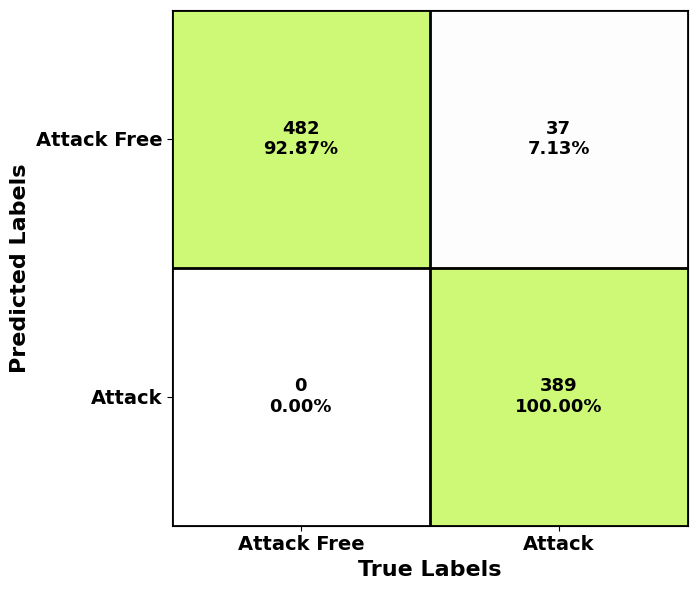

In [213]:
DATA_DIR = "Split_data/Test/Sil/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.28it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9385, 0.9681)


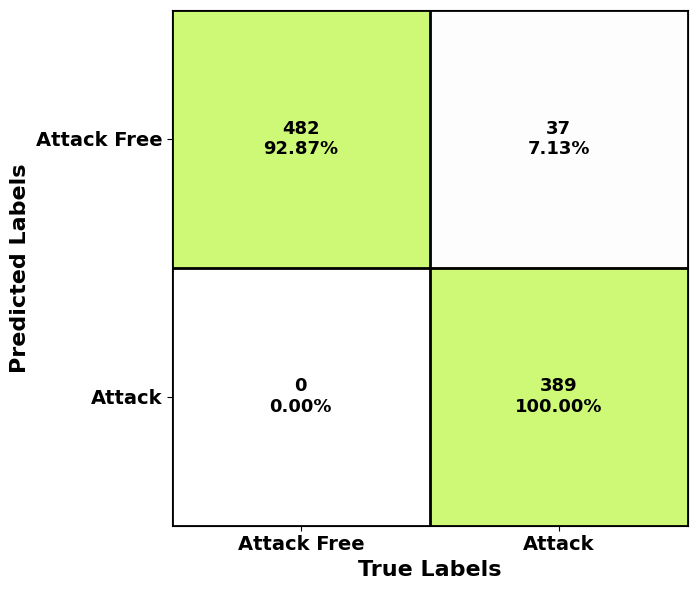

In [214]:
DATA_DIR = "Split_data/Test/Sil/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.17it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9401, 0.9697)


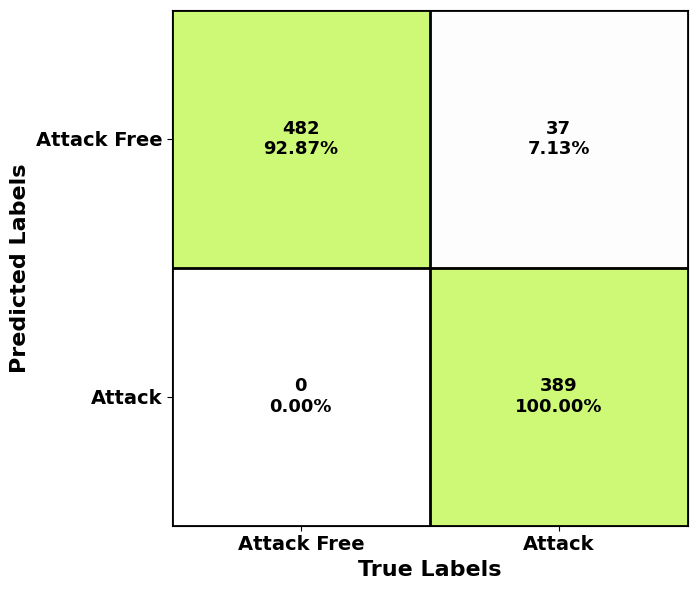

In [215]:
DATA_DIR = "Split_data/Test/Sil/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.35it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9438  (95% CI: 0.9269, 0.9570)
Precision: 0.9102  (95% CI: 0.8787, 0.9341)
Recall   : 0.9640  (95% CI: 0.9405, 0.9784)
F1-score : 0.9363  (95% CI: 0.9173, 0.9533)


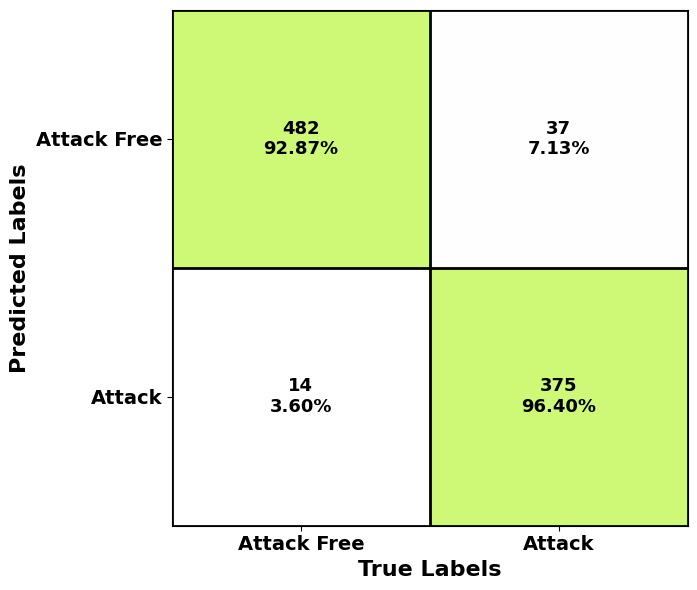

In [218]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9401, 0.9697)


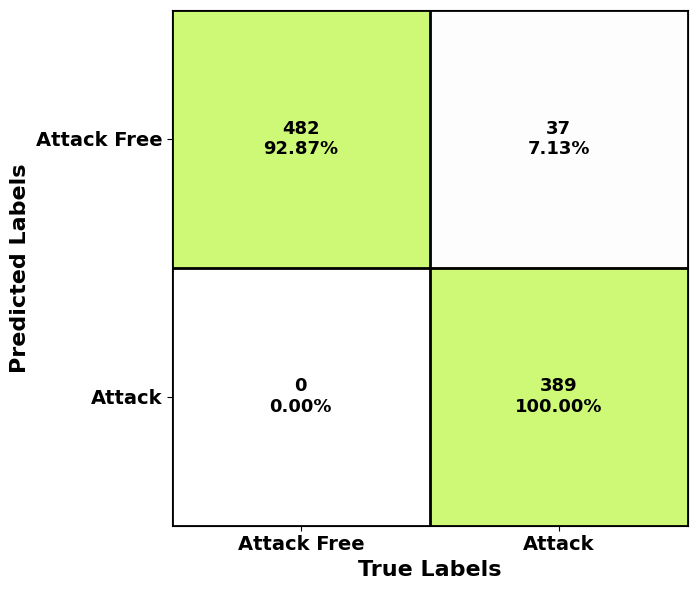

In [219]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.24it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9385, 0.9681)


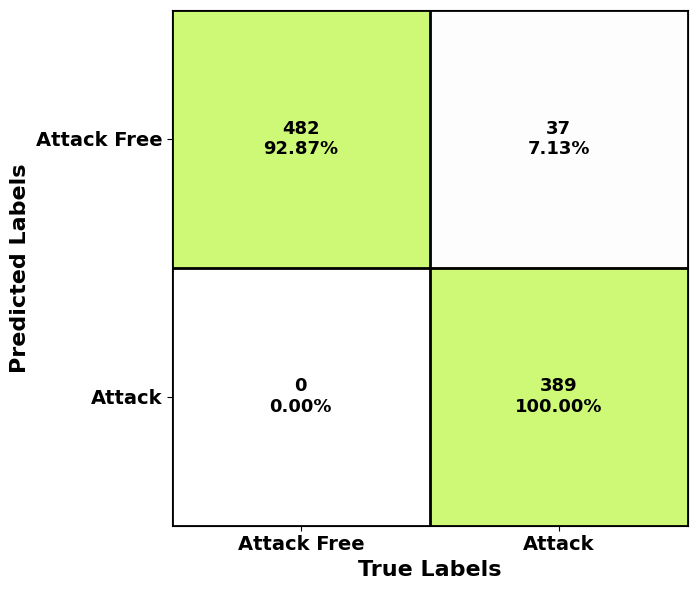

In [220]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.19it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.11it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9401, 0.9697)


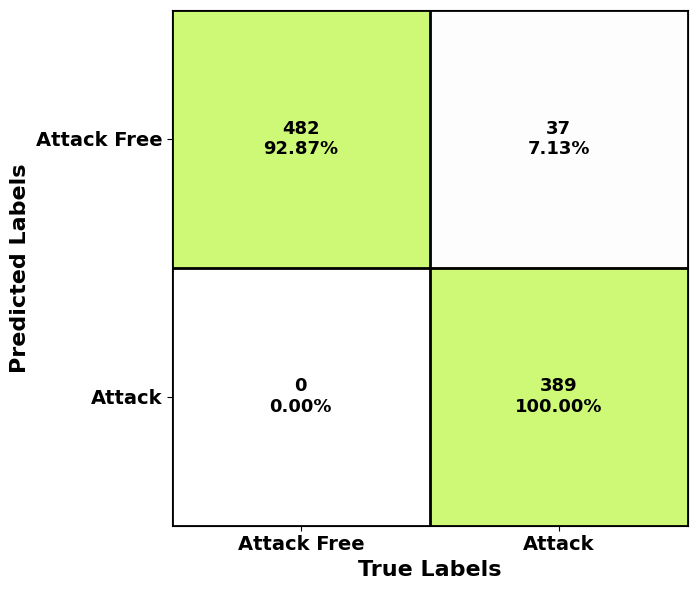

In [221]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.31it/s]


Total validation samples: 909


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.20it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9444, 0.9703)
Precision: 0.9133  (95% CI: 0.8828, 0.9365)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9547  (95% CI: 0.9393, 0.9684)


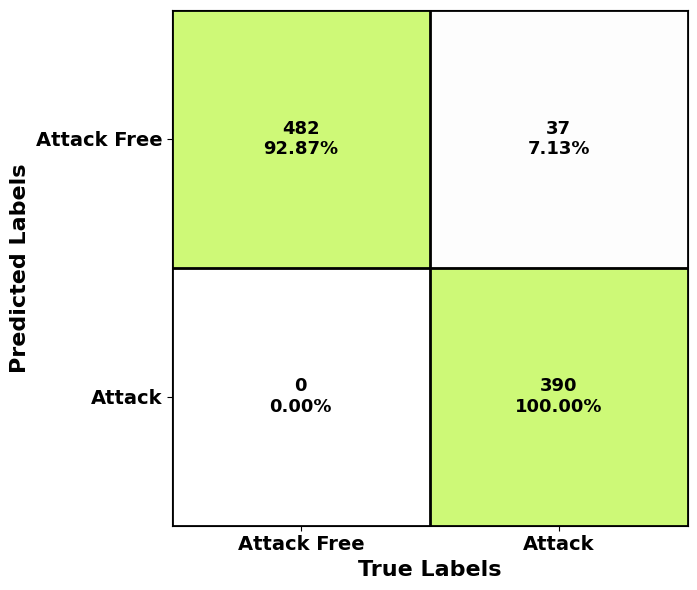

In [222]:
DATA_DIR = "Split_data/Test/Sil/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.21it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.22it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9570  (95% CI: 0.9418, 0.9684)
Precision: 0.9127  (95% CI: 0.8820, 0.9360)
Recall   : 0.9949  (95% CI: 0.9815, 0.9986)
F1-score : 0.9520  (95% CI: 0.9364, 0.9669)


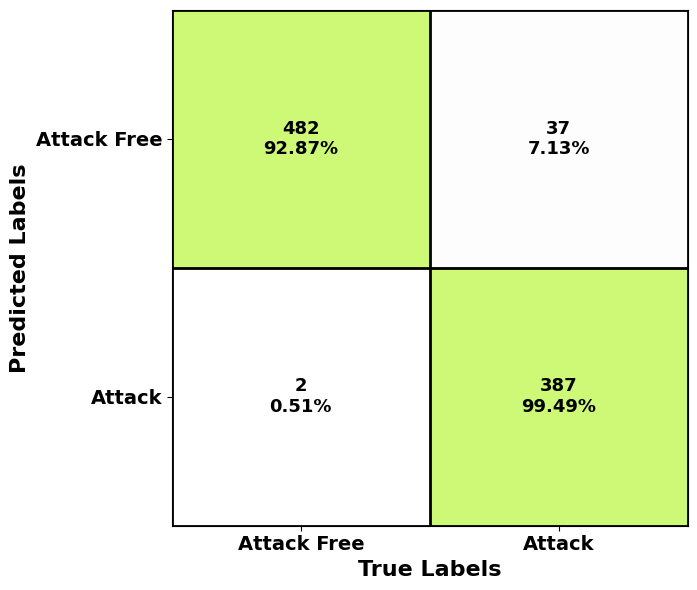

In [223]:
DATA_DIR = "Split_data/Test/Sil/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.27it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.21it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9401, 0.9697)


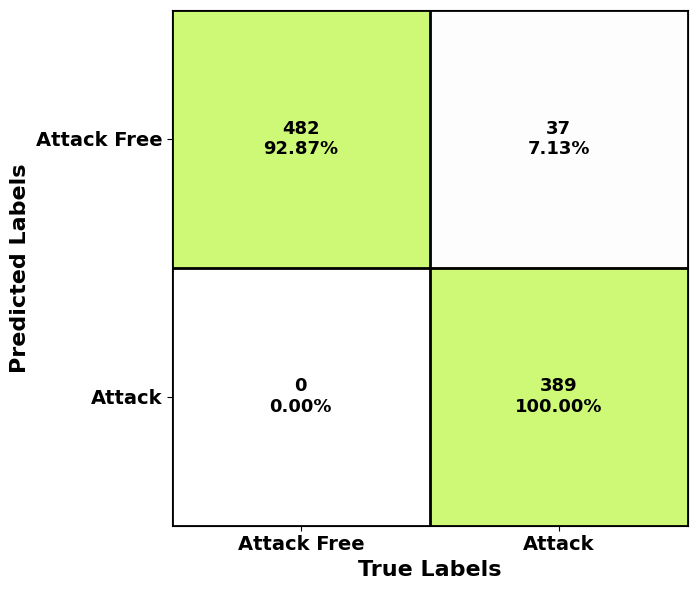

In [224]:
DATA_DIR = "Split_data/Test/Sil/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.33it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.18it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9385, 0.9681)


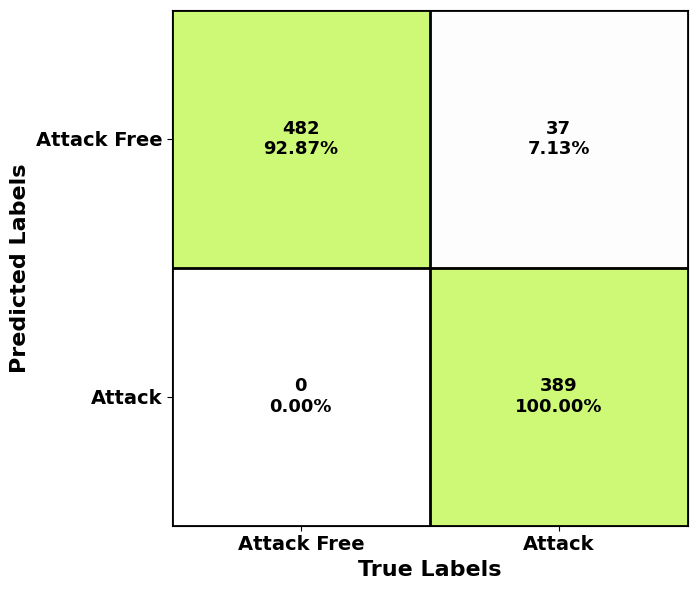

In [225]:
DATA_DIR = "Split_data/Test/Sil/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.22it/s]


Total validation samples: 908


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9443, 0.9703)
Precision: 0.9131  (95% CI: 0.8826, 0.9363)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9546  (95% CI: 0.9385, 0.9681)


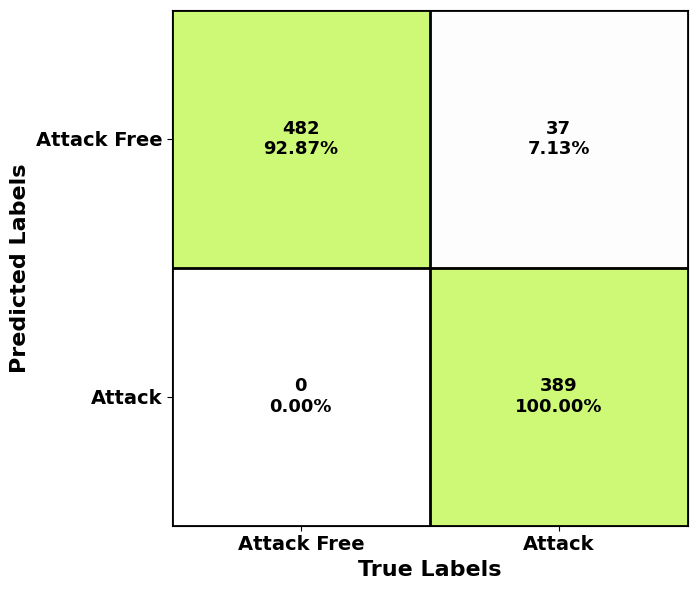

In [226]:
DATA_DIR = "Split_data/Test/Sil/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainGenOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.25it/s]


Total validation samples: 909


ONNX Inference: 100%|██████████| 57/57 [00:03<00:00, 17.15it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9593  (95% CI: 0.9444, 0.9703)
Precision: 0.9133  (95% CI: 0.8828, 0.9365)
Recall   : 1.0000  (95% CI: 0.9902, 1.0000)
F1-score : 0.9547  (95% CI: 0.9393, 0.9684)


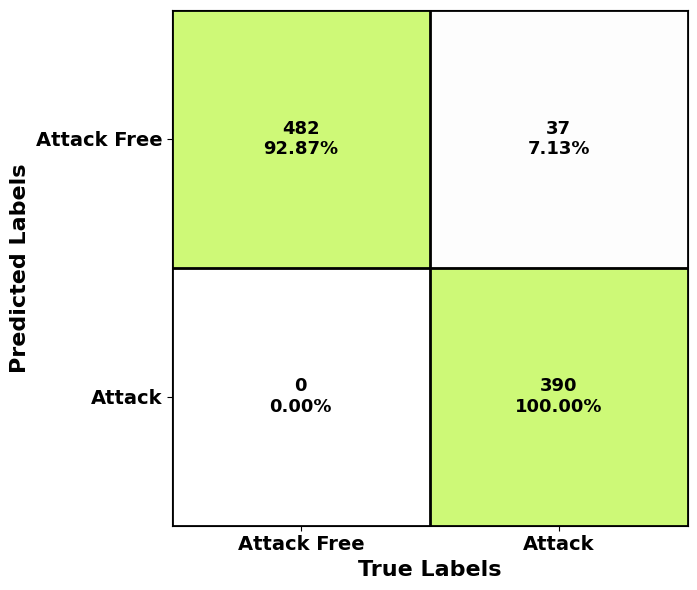

In [227]:
DATA_DIR = "Split_data/Test/Sil/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

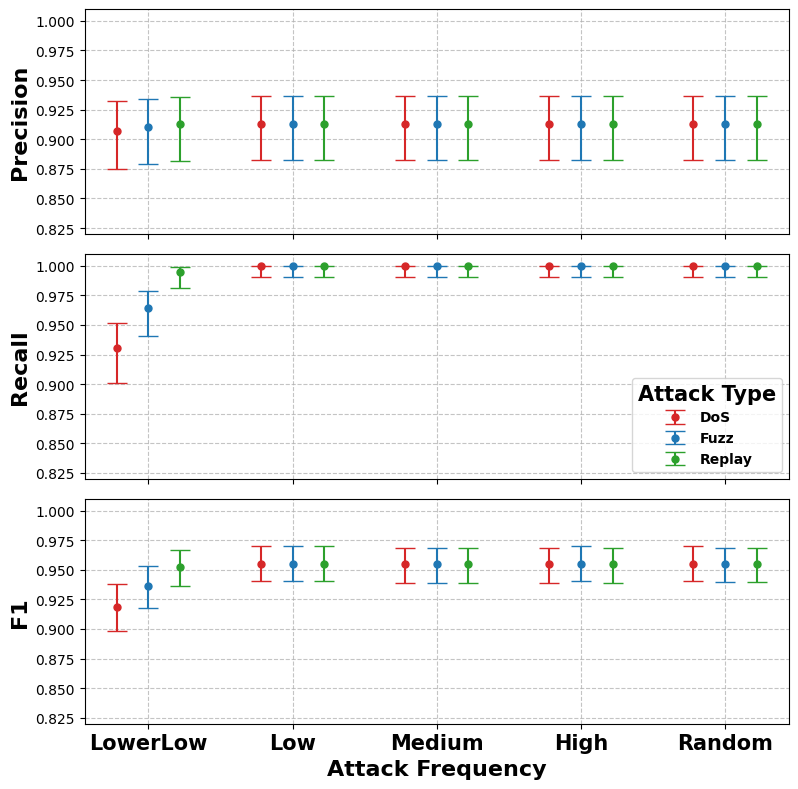

In [230]:
data = [
    # ================= DoS =================
    ("DoS","LowerLow","Precision",0.9073,0.8748,0.9320),
    ("DoS","LowerLow","Recall",   0.9306,0.9009,0.9519),
    ("DoS","LowerLow","F1",       0.9188,0.8985,0.9377),

    ("DoS","Low","Precision",0.9131,0.8826,0.9363),
    ("DoS","Low","Recall",   1.0000,0.9902,1.0000),
    ("DoS","Low","F1",       0.9546,0.9401,0.9697),

    ("DoS","Medium","Precision",0.9131,0.8826,0.9363),
    ("DoS","Medium","Recall",   1.0000,0.9902,1.0000),
    ("DoS","Medium","F1",       0.9546,0.9385,0.9681),

    ("DoS","High","Precision",0.9131,0.8826,0.9363),
    ("DoS","High","Recall",   1.0000,0.9902,1.0000),
    ("DoS","High","F1",       0.9546,0.9385,0.9681),

    ("DoS","Random","Precision",0.9131,0.8826,0.9363),
    ("DoS","Random","Recall",   1.0000,0.9902,1.0000),
    ("DoS","Random","F1",       0.9546,0.9401,0.9697),

    # ================= Fuzz =================
    ("Fuzz","LowerLow","Precision",0.9102,0.8787,0.9341),
    ("Fuzz","LowerLow","Recall",   0.9640,0.9405,0.9784),
    ("Fuzz","LowerLow","F1",       0.9363,0.9173,0.9533),

    ("Fuzz","Low","Precision",0.9131,0.8826,0.9363),
    ("Fuzz","Low","Recall",   1.0000,0.9902,1.0000),
    ("Fuzz","Low","F1",       0.9546,0.9401,0.9697),

    ("Fuzz","Medium","Precision",0.9131,0.8826,0.9363),
    ("Fuzz","Medium","Recall",   1.0000,0.9902,1.0000),
    ("Fuzz","Medium","F1",       0.9546,0.9385,0.9681),

    ("Fuzz","High","Precision",0.9131,0.8826,0.9363),
    ("Fuzz","High","Recall",   1.0000,0.9902,1.0000),
    ("Fuzz","High","F1",       0.9546,0.9401,0.9697),

    ("Fuzz","Random","Precision",0.9133,0.8828,0.9365),
    ("Fuzz","Random","Recall",   1.0000,0.9902,1.0000),
    ("Fuzz","Random","F1",       0.9547,0.9393,0.9684),

    # ================= Replay =================
    ("Replay","LowerLow","Precision",0.9127,0.8820,0.9360),
    ("Replay","LowerLow","Recall",   0.9949,0.9815,0.9986),
    ("Replay","LowerLow","F1",       0.9520,0.9364,0.9669),

    ("Replay","Low","Precision",0.9131,0.8826,0.9363),
    ("Replay","Low","Recall",   1.0000,0.9902,1.0000),
    ("Replay","Low","F1",       0.9546,0.9401,0.9697),

    ("Replay","Medium","Precision",0.9131,0.8826,0.9363),
    ("Replay","Medium","Recall",   1.0000,0.9902,1.0000),
    ("Replay","Medium","F1",       0.9546,0.9385,0.9681),

    ("Replay","High","Precision",0.9131,0.8826,0.9363),
    ("Replay","High","Recall",   1.0000,0.9902,1.0000),
    ("Replay","High","F1",       0.9546,0.9385,0.9681),

    ("Replay","Random","Precision",0.9133,0.8828,0.9365),
    ("Replay","Random","Recall",   1.0000,0.9902,1.0000),
    ("Replay","Random","F1",       0.9547,0.9393,0.9684),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)

## Tran on Silverado

## Test on Kia

## DoS

In [248]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainSilOnnx"
TIME_GAP = 100.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.41it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9313  (95% CI: 0.9116, 0.9468)
Precision: 0.9364  (95% CI: 0.9047, 0.9580)
Recall   : 0.9009  (95% CI: 0.8647, 0.9282)
F1-score : 0.9183  (95% CI: 0.8954, 0.9381)


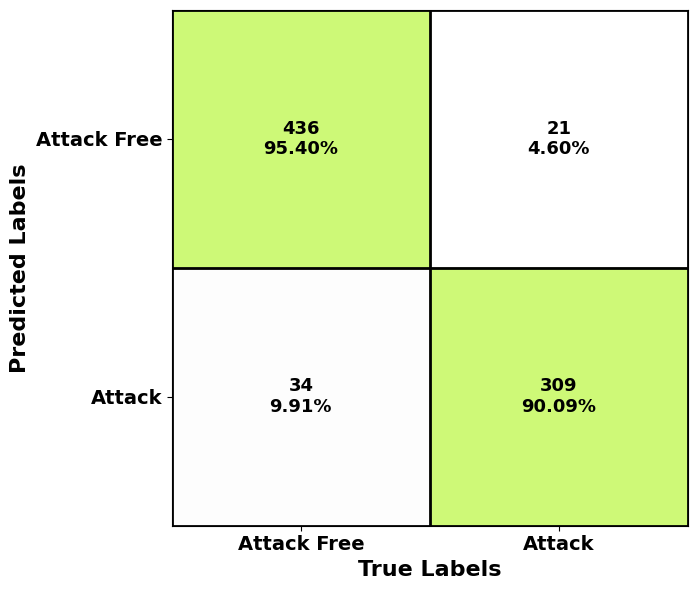

In [249]:
DATA_DIR = "Split_data/Test/Kia/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


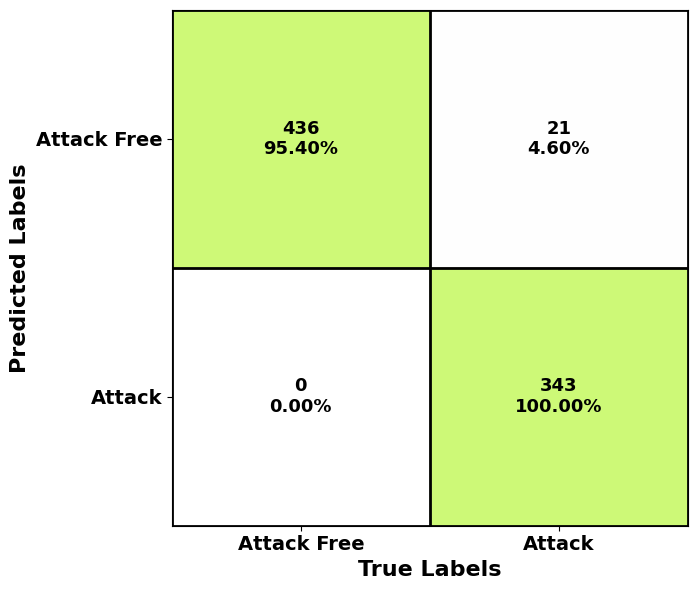

In [250]:
DATA_DIR = "Split_data/Test/Kia/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9568, 0.9825)


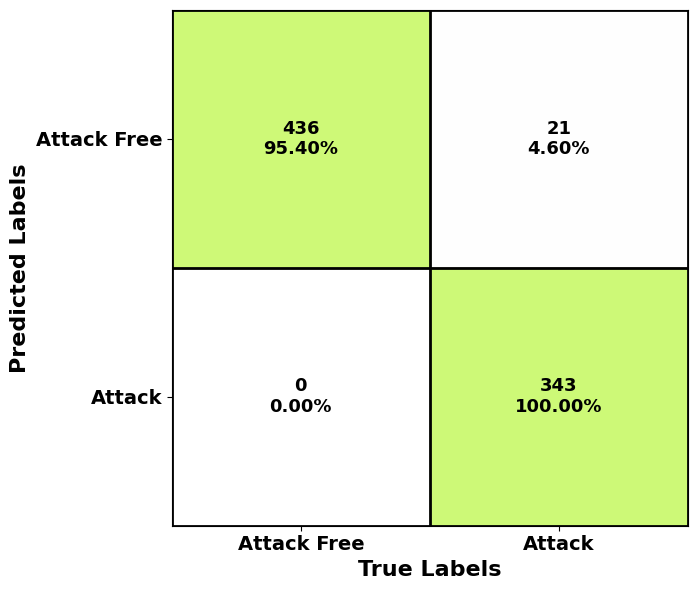

In [251]:
DATA_DIR = "Split_data/Test/Kia/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.42it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.07it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


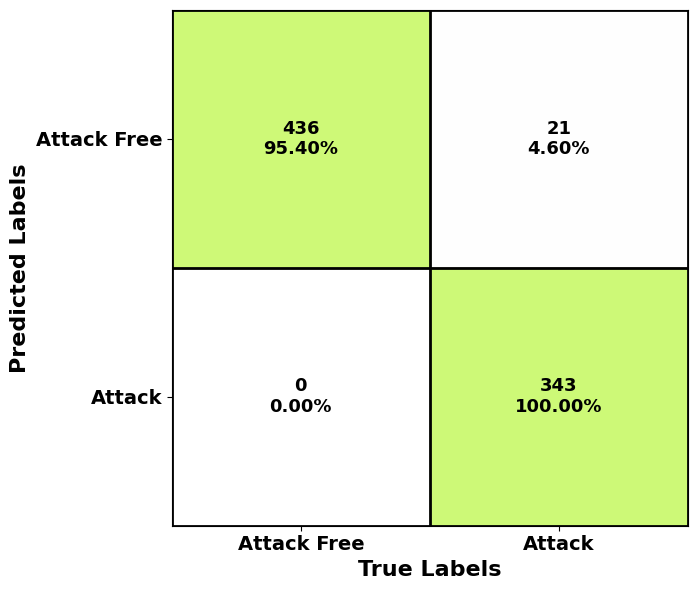

In [252]:
DATA_DIR = "Split_data/Test/Kia/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.55it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.10it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9816)


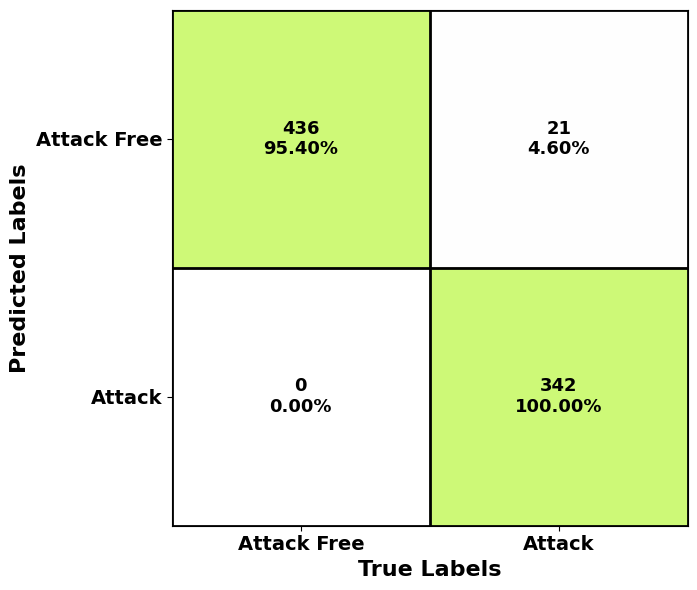

In [253]:
DATA_DIR = "Split_data/Test/Kia/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.49it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.09it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9513  (95% CI: 0.9341, 0.9641)
Precision: 0.9393  (95% CI: 0.9090, 0.9600)
Recall   : 0.9475  (95% CI: 0.9186, 0.9666)
F1-score : 0.9434  (95% CI: 0.9242, 0.9598)


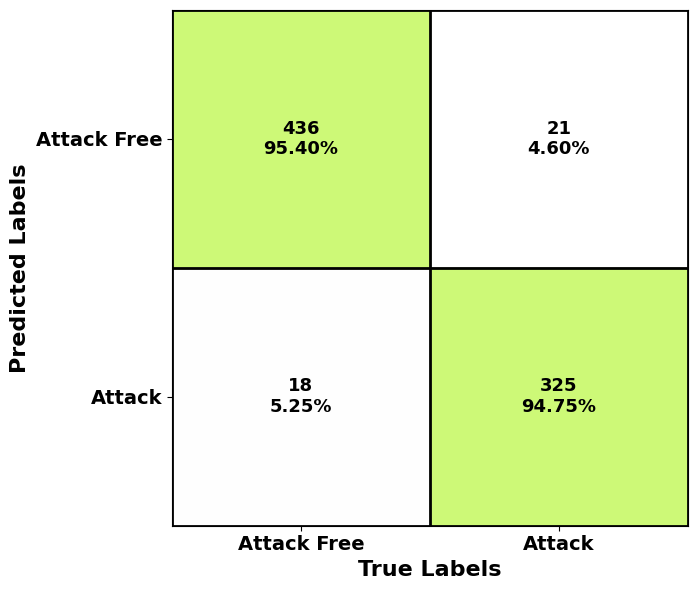

In [254]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.59it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.05it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9725  (95% CI: 0.9587, 0.9818)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 0.9971  (95% CI: 0.9837, 0.9995)
F1-score : 0.9688  (95% CI: 0.9551, 0.9811)


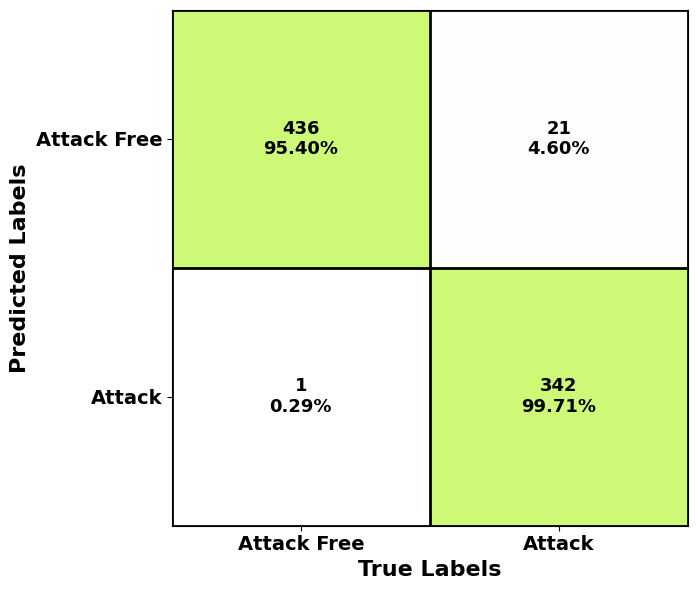

In [255]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


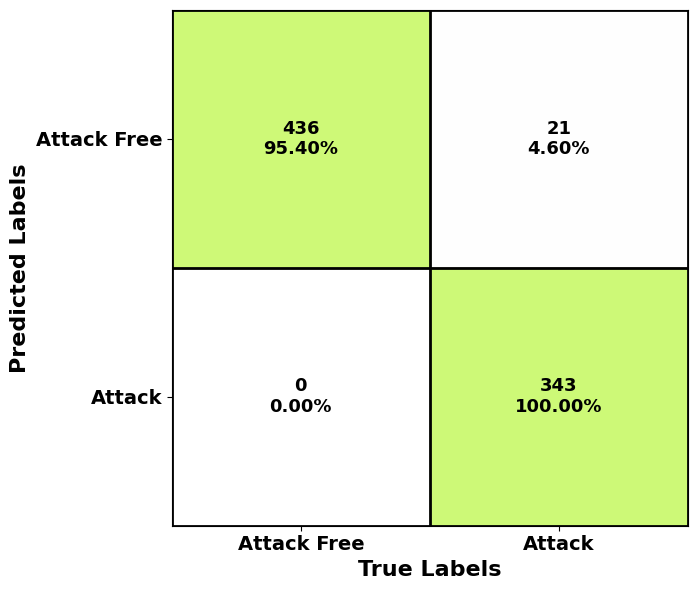

In [256]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.58it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.96it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


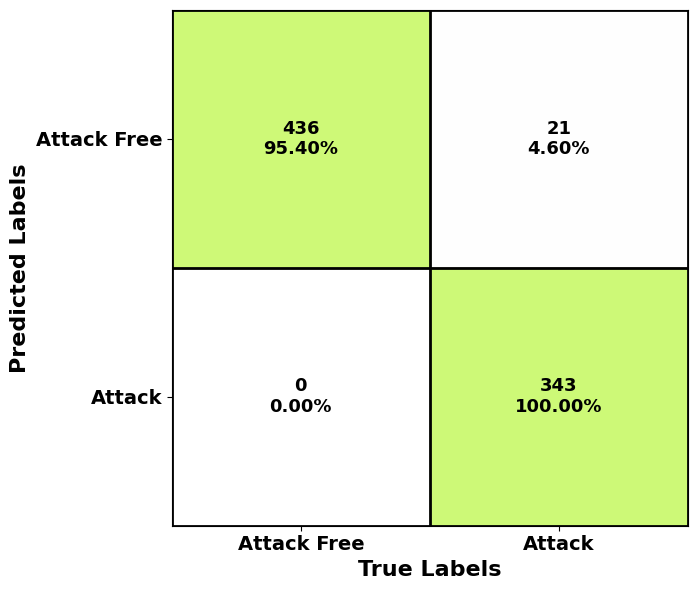

In [257]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


Total validation samples: 799


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.95it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9737  (95% CI: 0.9602, 0.9827)
Precision: 0.9421  (95% CI: 0.9132, 0.9619)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9702  (95% CI: 0.9568, 0.9831)


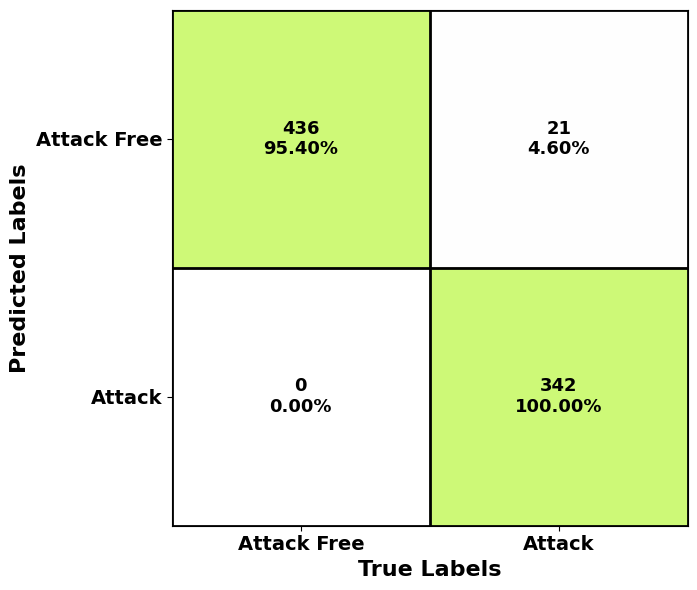

In [258]:
DATA_DIR = "Split_data/Test/Kia/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 17.02it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9712  (95% CI: 0.9572, 0.9808)
Precision: 0.9420  (95% CI: 0.9129, 0.9617)
Recall   : 0.9942  (95% CI: 0.9790, 0.9984)
F1-score : 0.9674  (95% CI: 0.9532, 0.9795)


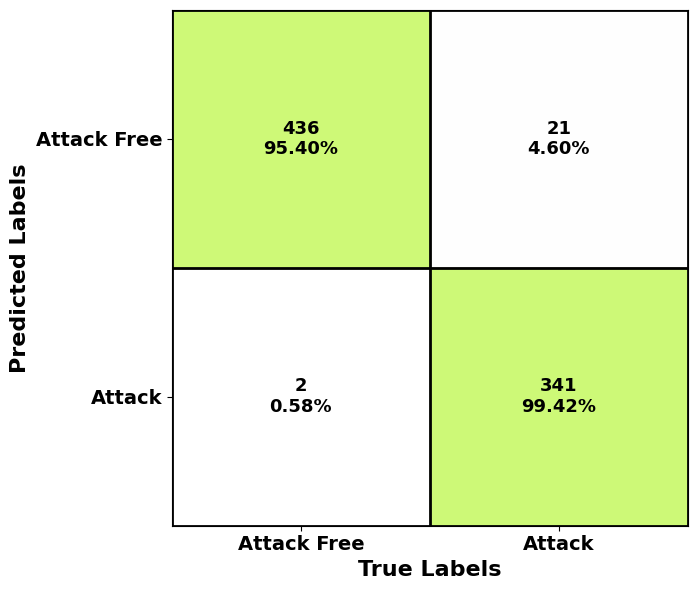

In [259]:
DATA_DIR = "Split_data/Test/Kia/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.56it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.93it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


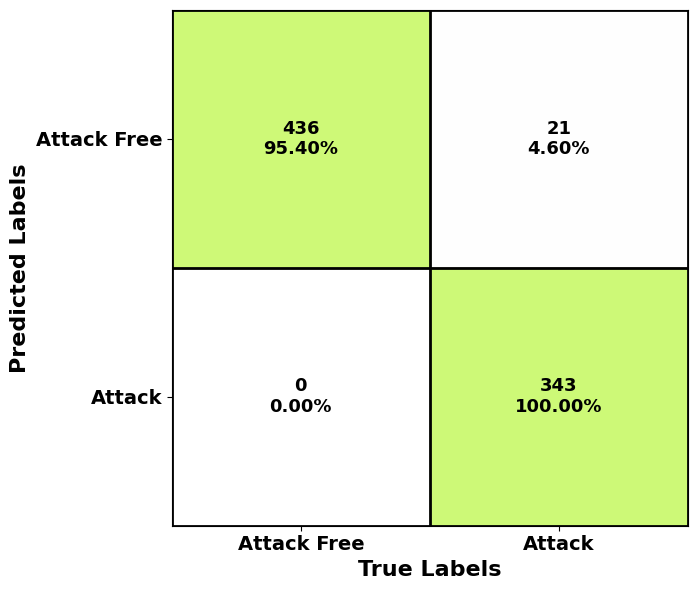

In [260]:
DATA_DIR = "Split_data/Test/Kia/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.57it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.93it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


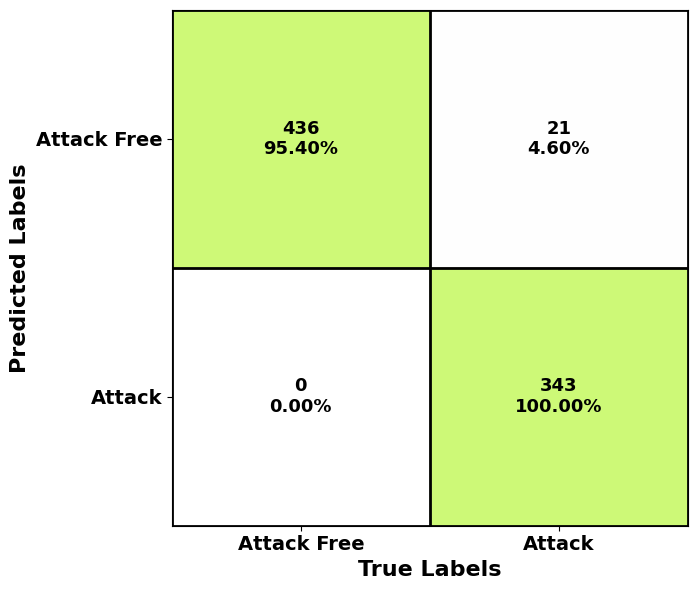

In [261]:
DATA_DIR = "Split_data/Test/Kia/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.38it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.90it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


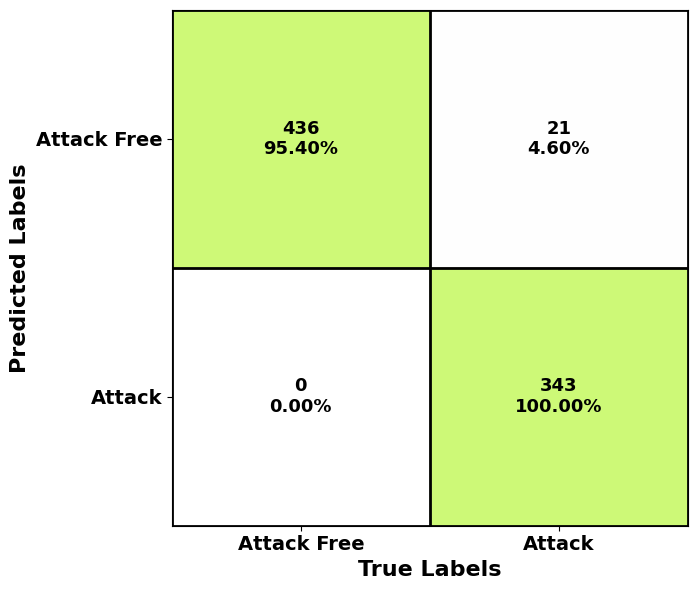

In [262]:
DATA_DIR = "Split_data/Test/Kia/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.58it/s]


Total validation samples: 800


ONNX Inference: 100%|██████████| 50/50 [00:02<00:00, 16.72it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9738  (95% CI: 0.9602, 0.9828)
Precision: 0.9423  (95% CI: 0.9134, 0.9620)
Recall   : 1.0000  (95% CI: 0.9889, 1.0000)
F1-score : 0.9703  (95% CI: 0.9574, 0.9823)


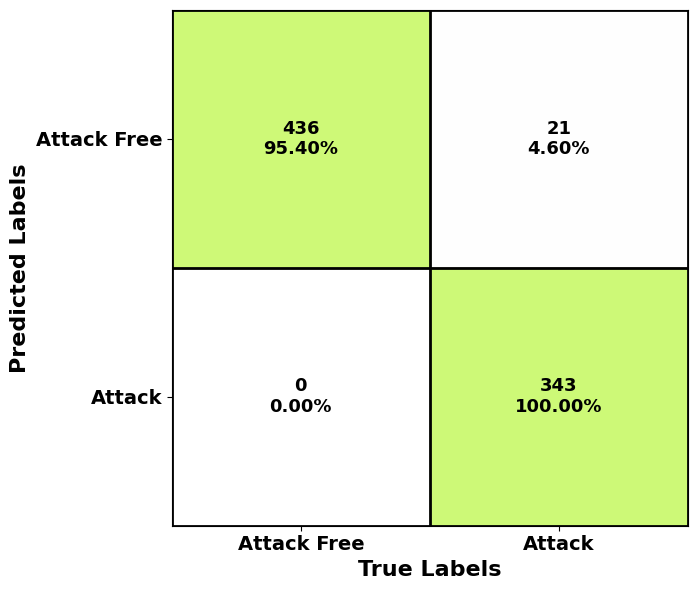

In [263]:
DATA_DIR = "Split_data/Test/Kia/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

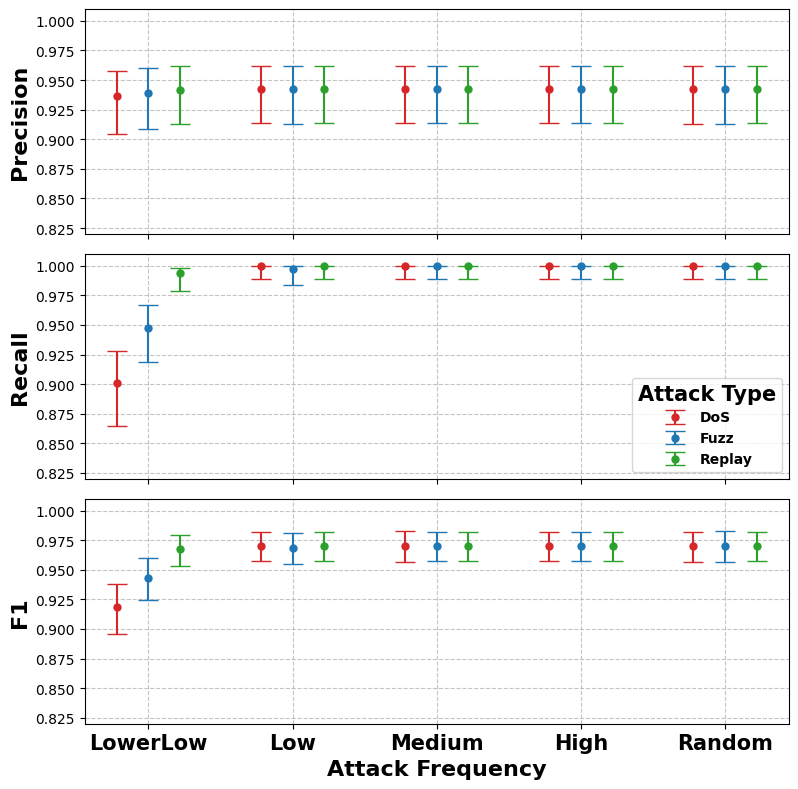

In [270]:
import pandas as pd

data = [
    # ================= DoS =================
    ("DoS","LowerLow","Precision",0.9364,0.9047,0.9580),
    ("DoS","LowerLow","Recall",   0.9009,0.8647,0.9282),
    ("DoS","LowerLow","F1",       0.9183,0.8954,0.9381),

    ("DoS","Low","Precision",0.9423,0.9134,0.9620),
    ("DoS","Low","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Low","F1",       0.9703,0.9574,0.9823),

    ("DoS","Medium","Precision",0.9423,0.9134,0.9620),
    ("DoS","Medium","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Medium","F1",       0.9703,0.9568,0.9825),

    ("DoS","High","Precision",0.9423,0.9134,0.9620),
    ("DoS","High","Recall",   1.0000,0.9889,1.0000),
    ("DoS","High","F1",       0.9703,0.9574,0.9823),

    ("DoS","Random","Precision",0.9421,0.9132,0.9619),
    ("DoS","Random","Recall",   1.0000,0.9889,1.0000),
    ("DoS","Random","F1",       0.9702,0.9568,0.9816),

    # ================= Fuzz =================
    ("Fuzz","LowerLow","Precision",0.9393,0.9090,0.9600),
    ("Fuzz","LowerLow","Recall",   0.9475,0.9186,0.9666),
    ("Fuzz","LowerLow","F1",       0.9434,0.9242,0.9598),

    ("Fuzz","Low","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Low","Recall",   0.9971,0.9837,0.9995),
    ("Fuzz","Low","F1",       0.9688,0.9551,0.9811),

    ("Fuzz","Medium","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","Medium","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","Medium","F1",       0.9703,0.9574,0.9823),

    ("Fuzz","High","Precision",0.9423,0.9134,0.9620),
    ("Fuzz","High","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","High","F1",       0.9703,0.9574,0.9823),

    ("Fuzz","Random","Precision",0.9421,0.9132,0.9619),
    ("Fuzz","Random","Recall",   1.0000,0.9889,1.0000),
    ("Fuzz","Random","F1",       0.9702,0.9568,0.9831),

    # ================= Replay =================
    ("Replay","LowerLow","Precision",0.9420,0.9129,0.9617),
    ("Replay","LowerLow","Recall",   0.9942,0.9790,0.9984),
    ("Replay","LowerLow","F1",       0.9674,0.9532,0.9795),

    ("Replay","Low","Precision",0.9423,0.9134,0.9620),
    ("Replay","Low","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Low","F1",       0.9703,0.9574,0.9823),

    ("Replay","Medium","Precision",0.9423,0.9134,0.9620),
    ("Replay","Medium","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Medium","F1",       0.9703,0.9574,0.9823),

    ("Replay","High","Precision",0.9423,0.9134,0.9620),
    ("Replay","High","Recall",   1.0000,0.9889,1.0000),
    ("Replay","High","F1",       0.9703,0.9574,0.9823),

    ("Replay","Random","Precision",0.9423,0.9134,0.9620),
    ("Replay","Random","Recall",   1.0000,0.9889,1.0000),
    ("Replay","Random","F1",       0.9703,0.9574,0.9823),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)

## Test on Tesla

# DoS

In [264]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainSilOnnx"
TIME_GAP = 83.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.43it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.16it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9407  (95% CI: 0.9222, 0.9550)
Precision: 0.8782  (95% CI: 0.8422, 0.9069)
Recall   : 1.0000  (95% CI: 0.9890, 1.0000)
F1-score : 0.9351  (95% CI: 0.9163, 0.9527)


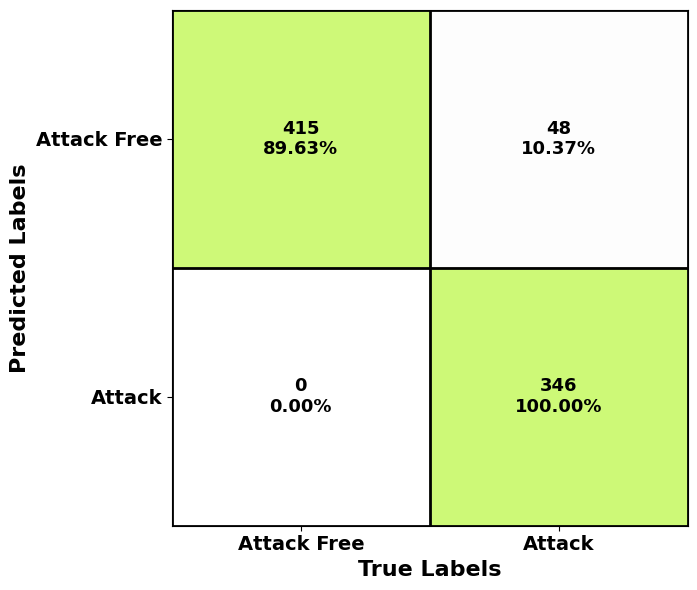

In [ ]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.52it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.17it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


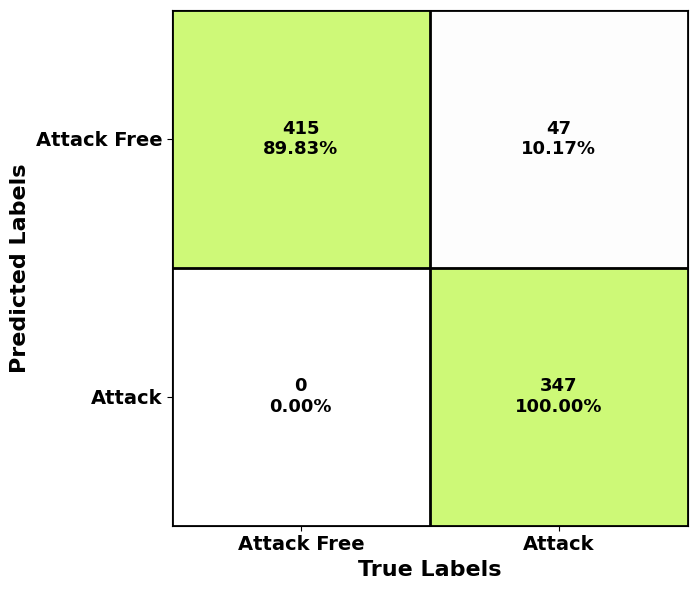

In [ ]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.09it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


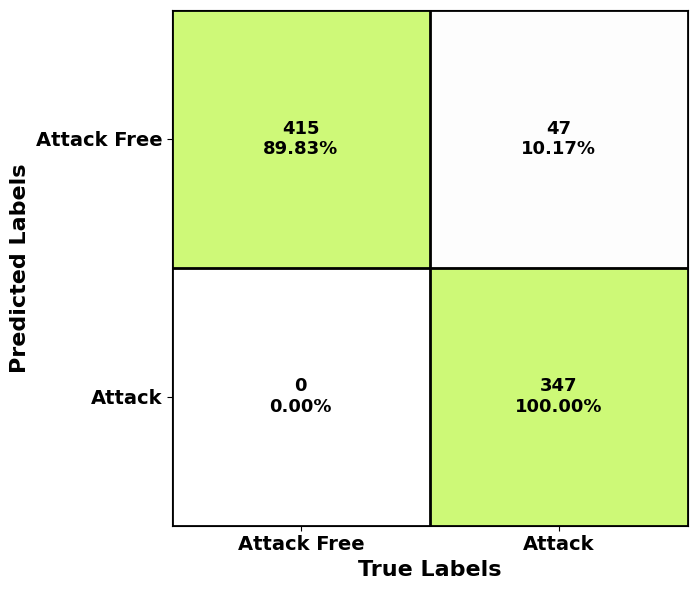

In [ ]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


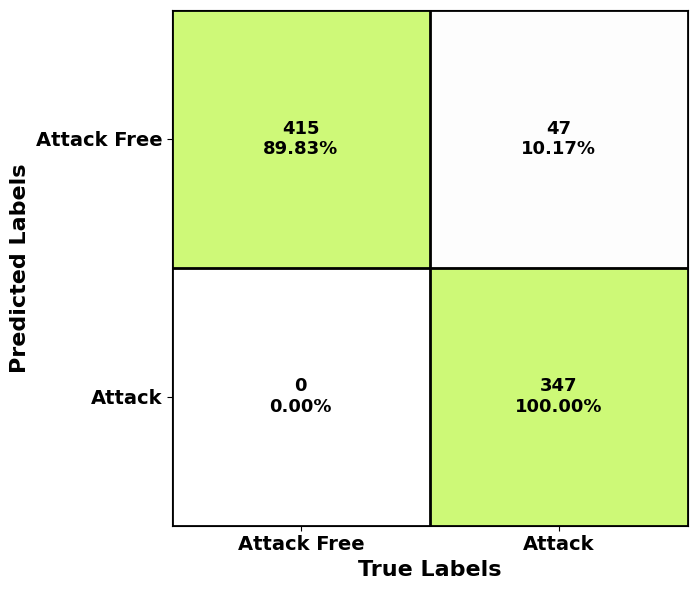

In [ ]:
DATA_DIR = "Split_data/Test/Tesla/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.49it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


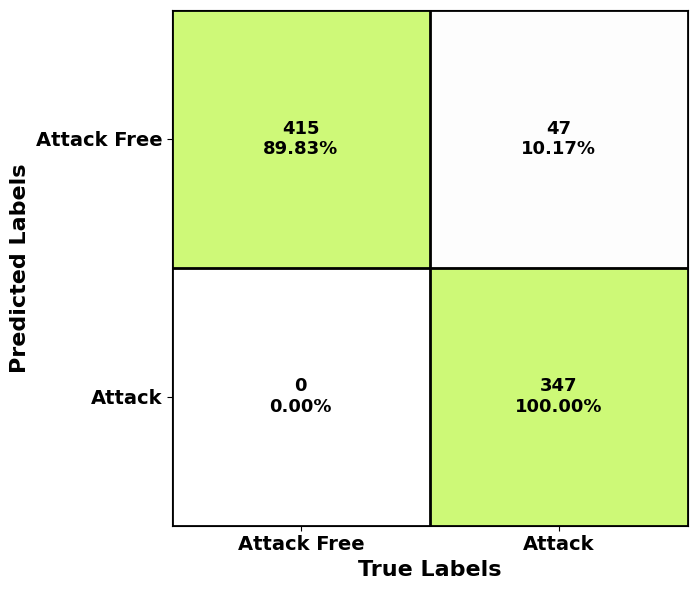

In [ ]:
DATA_DIR = "Split_data/Test/Tesla/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.39it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.10it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9370  (95% CI: 0.9181, 0.9517)
Precision: 0.8772  (95% CI: 0.8410, 0.9061)
Recall   : 0.9913  (95% CI: 0.9748, 0.9970)
F1-score : 0.9308  (95% CI: 0.9111, 0.9488)


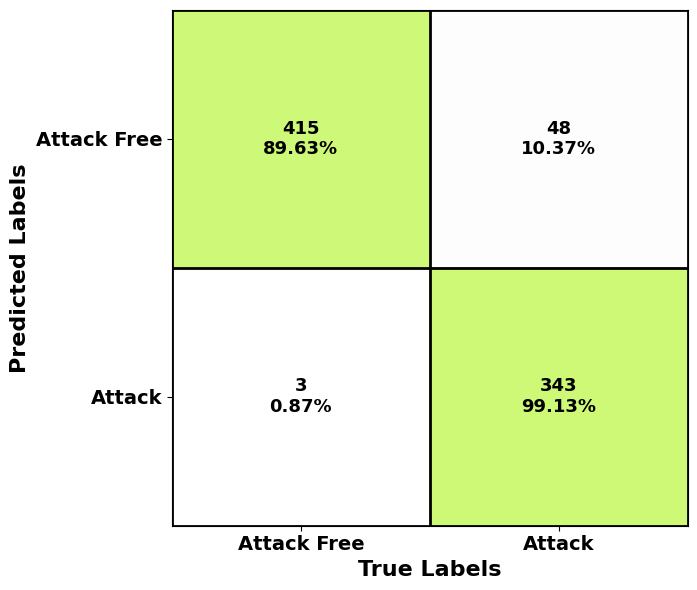

In [271]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.52it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9407  (95% CI: 0.9222, 0.9550)
Precision: 0.8804  (95% CI: 0.8446, 0.9089)
Recall   : 0.9971  (95% CI: 0.9839, 0.9995)
F1-score : 0.9351  (95% CI: 0.9167, 0.9529)


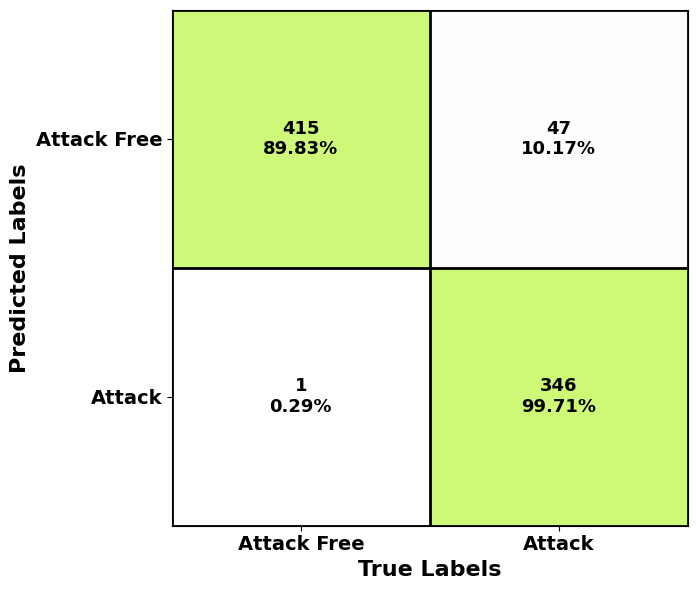

In [272]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.14it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


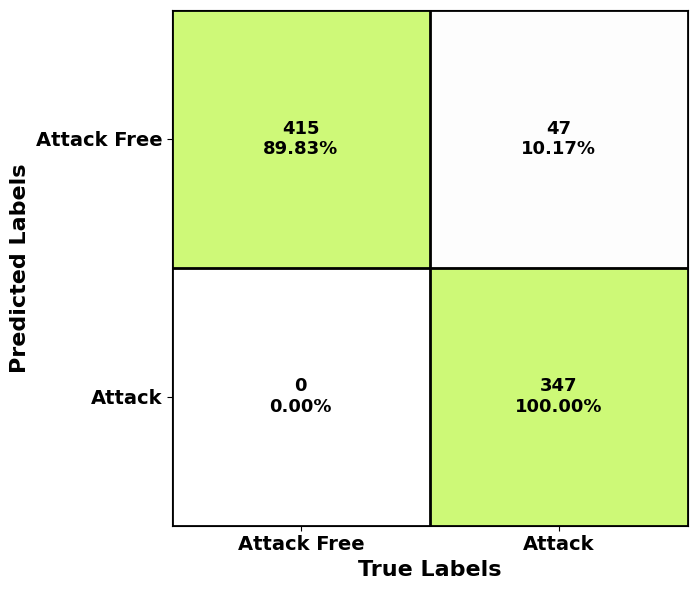

In [273]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.48it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.11it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


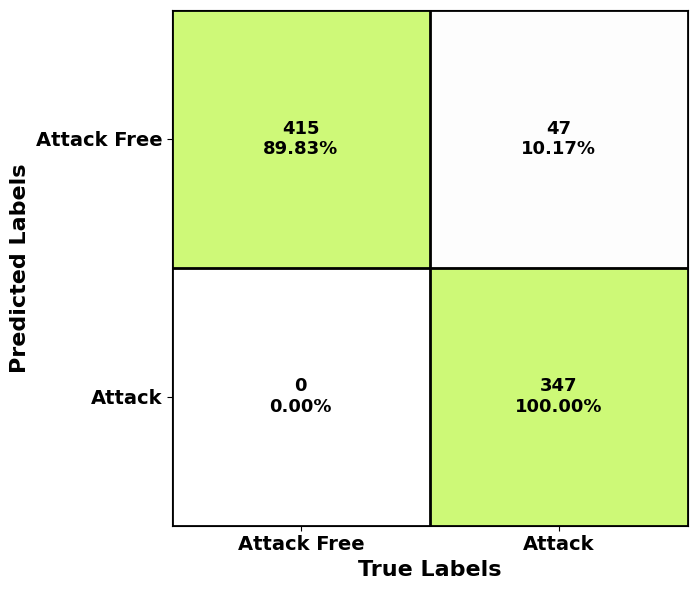

In [274]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.17it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


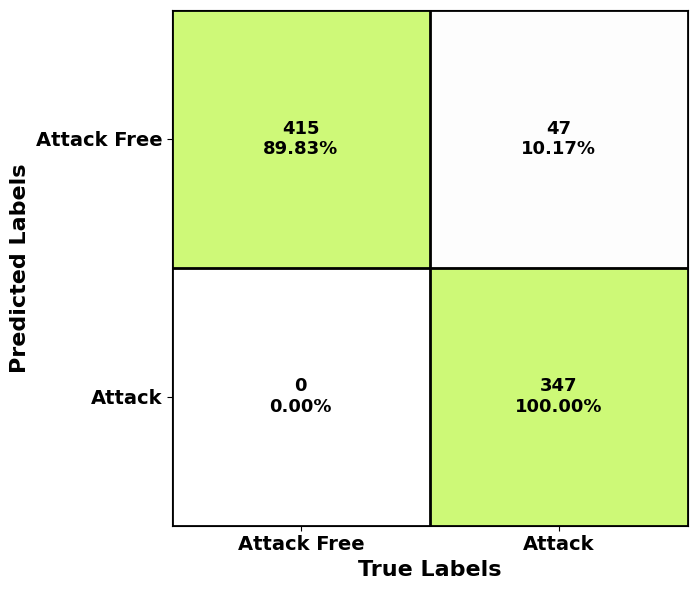

In [275]:
DATA_DIR = "Split_data/Test/Tesla/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.35it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:03<00:00, 16.80it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9407  (95% CI: 0.9222, 0.9550)
Precision: 0.8782  (95% CI: 0.8422, 0.9069)
Recall   : 1.0000  (95% CI: 0.9890, 1.0000)
F1-score : 0.9351  (95% CI: 0.9163, 0.9527)


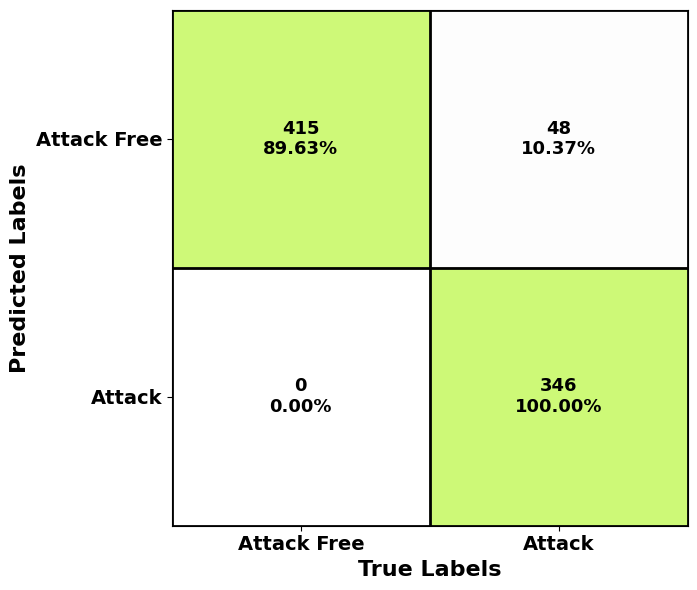

In [276]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.03it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


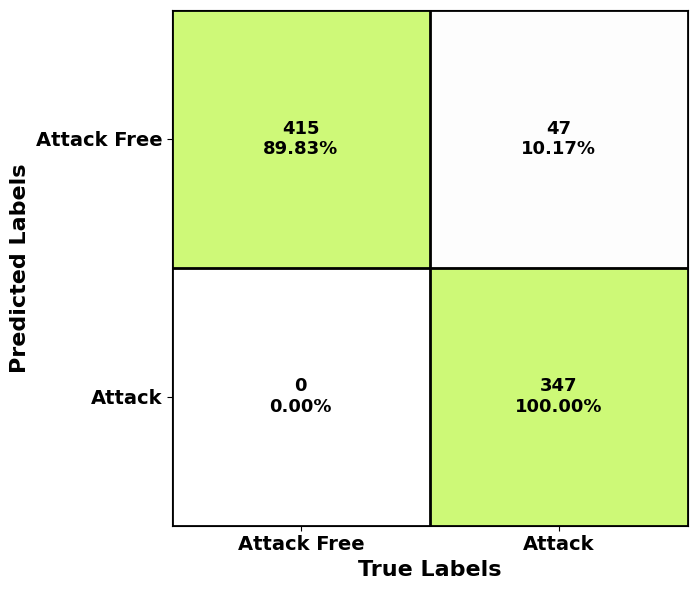

In [277]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:02<00:00, 17.04it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


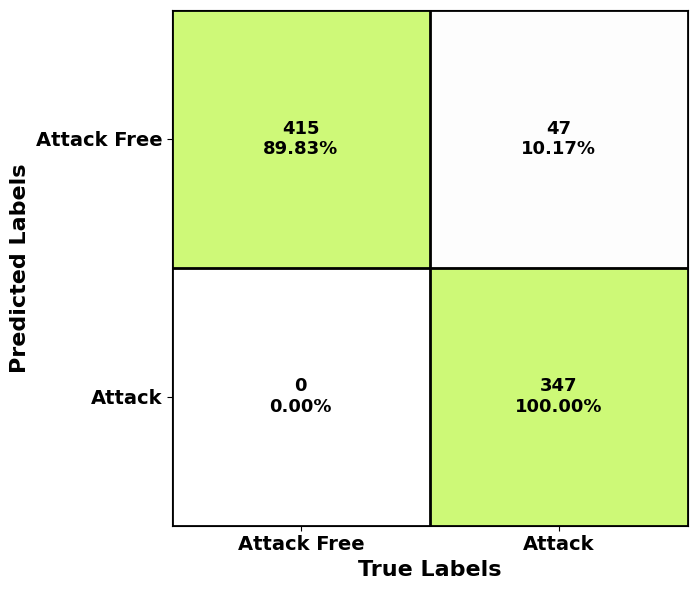

In [278]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.47it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:03<00:00, 14.47it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


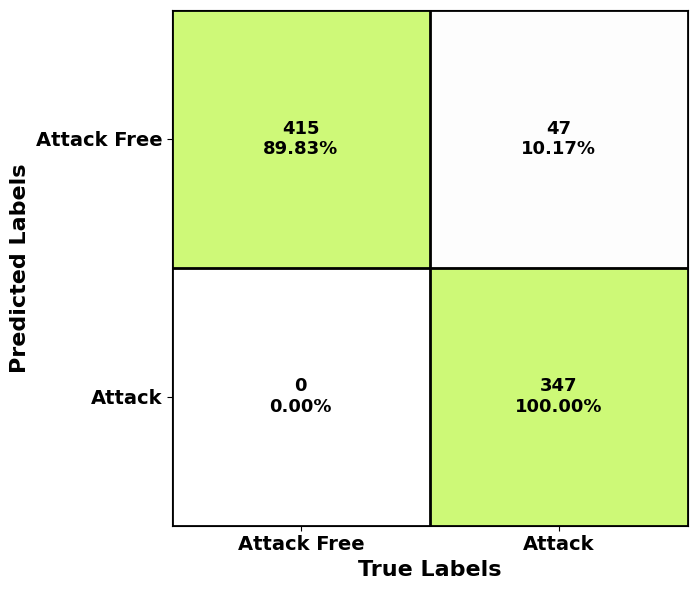

In [279]:
DATA_DIR = "Split_data/Test/Tesla/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Total validation samples: 809


ONNX Inference: 100%|██████████| 51/51 [00:05<00:00,  8.98it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9419  (95% CI: 0.9236, 0.9560)
Precision: 0.8807  (95% CI: 0.8450, 0.9091)
Recall   : 1.0000  (95% CI: 0.9891, 1.0000)
F1-score : 0.9366  (95% CI: 0.9186, 0.9541)


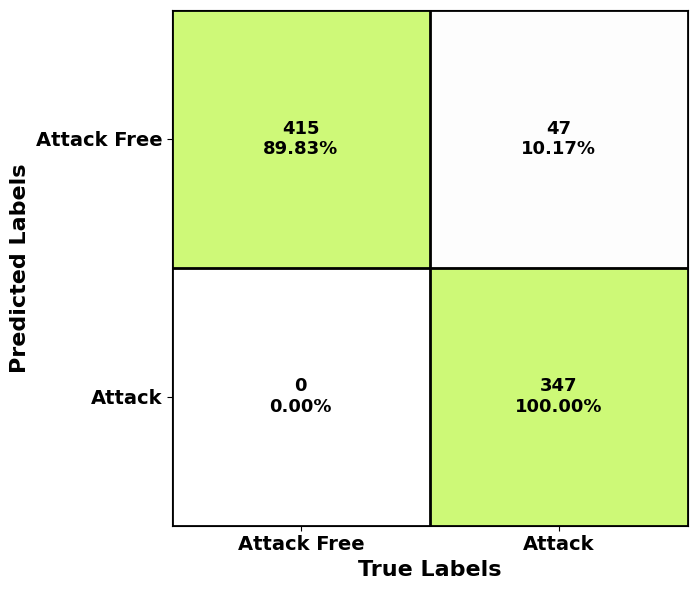

In [280]:
DATA_DIR = "Split_data/Test/Tesla/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

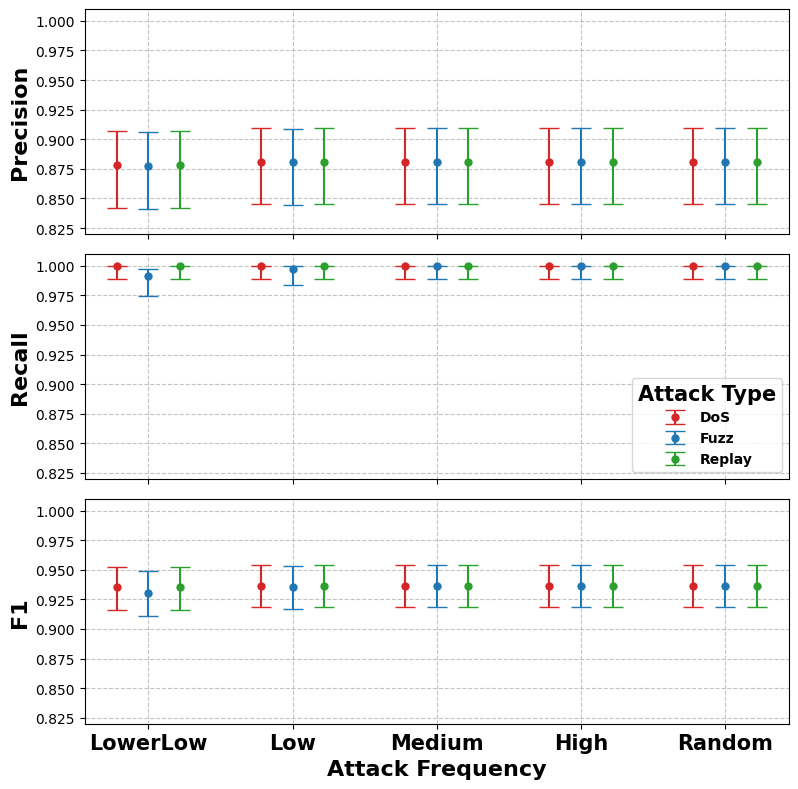

In [297]:
data = [
    # ================= DoS =================
    ("DoS","LowerLow","Precision",0.8782,0.8422,0.9069),
    ("DoS","LowerLow","Recall",   1.0000,0.9890,1.0000),
    ("DoS","LowerLow","F1",       0.9351,0.9163,0.9527),

    ("DoS","Low","Precision",0.8807,0.8450,0.9091),
    ("DoS","Low","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Low","F1",       0.9366,0.9186,0.9541),

    ("DoS","Medium","Precision",0.8807,0.8450,0.9091),
    ("DoS","Medium","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Medium","F1",       0.9366,0.9186,0.9541),

    ("DoS","High","Precision",0.8807,0.8450,0.9091),
    ("DoS","High","Recall",   1.0000,0.9891,1.0000),
    ("DoS","High","F1",       0.9366,0.9186,0.9541),

    ("DoS","Random","Precision",0.8807,0.8450,0.9091),
    ("DoS","Random","Recall",   1.0000,0.9891,1.0000),
    ("DoS","Random","F1",       0.9366,0.9186,0.9541),

    # ================= Fuzz =================
    ("Fuzz","LowerLow","Precision",0.8772,0.8410,0.9061),
    ("Fuzz","LowerLow","Recall",   0.9913,0.9748,0.9970),
    ("Fuzz","LowerLow","F1",       0.9308,0.9111,0.9488),

    ("Fuzz","Low","Precision",0.8804,0.8446,0.9089),
    ("Fuzz","Low","Recall",   0.9971,0.9839,0.9995),
    ("Fuzz","Low","F1",       0.9351,0.9167,0.9529),

    ("Fuzz","Medium","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","Medium","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","Medium","F1",       0.9366,0.9186,0.9541),

    ("Fuzz","High","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","High","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","High","F1",       0.9366,0.9186,0.9541),

    ("Fuzz","Random","Precision",0.8807,0.8450,0.9091),
    ("Fuzz","Random","Recall",   1.0000,0.9891,1.0000),
    ("Fuzz","Random","F1",       0.9366,0.9186,0.9541),

    # ================= Replay =================
    ("Replay","LowerLow","Precision",0.8782,0.8422,0.9069),
    ("Replay","LowerLow","Recall",   1.0000,0.9890,1.0000),
    ("Replay","LowerLow","F1",       0.9351,0.9163,0.9527),

    ("Replay","Low","Precision",0.8807,0.8450,0.9091),
    ("Replay","Low","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Low","F1",       0.9366,0.9186,0.9541),

    ("Replay","Medium","Precision",0.8807,0.8450,0.9091),
    ("Replay","Medium","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Medium","F1",       0.9366,0.9186,0.9541),

    ("Replay","High","Precision",0.8807,0.8450,0.9091),
    ("Replay","High","Recall",   1.0000,0.9891,1.0000),
    ("Replay","High","F1",       0.9366,0.9186,0.9541),

    ("Replay","Random","Precision",0.8807,0.8450,0.9091),
    ("Replay","Random","Recall",   1.0000,0.9891,1.0000),
    ("Replay","Random","F1",       0.9366,0.9186,0.9541),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)

## Test on Gennesis

## DoS

In [ ]:
MODEL_DIR = "SFTSrc/bert/OnnxModels/TrainSilOnnx"
TIME_GAP = 105.0


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.62it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.55it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  9.07it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9736  (95% CI: 0.9604, 0.9825)
Precision: 1.0000  (95% CI: 0.9887, 1.0000)
Recall   : 0.9384  (95% CI: 0.9085, 0.9590)
F1-score : 0.9682  (95% CI: 0.9543, 0.9813)


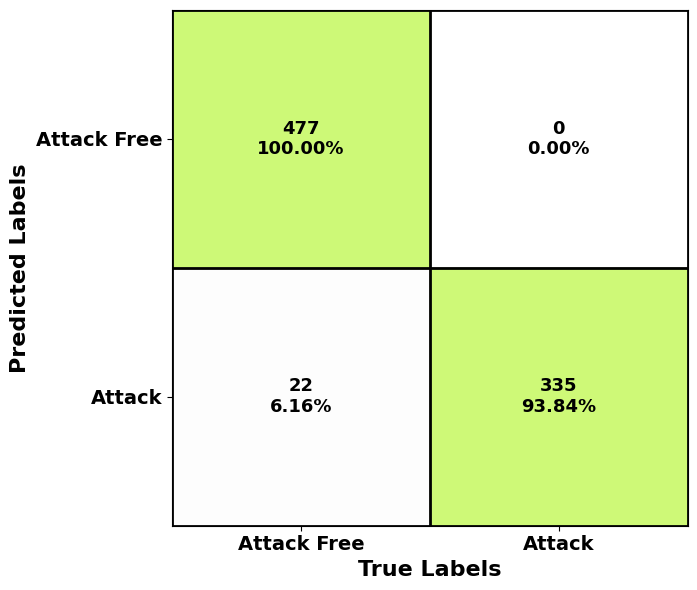

In [282]:
DATA_DIR = "Split_data/Test/Gen/DoS/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.40it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.98it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


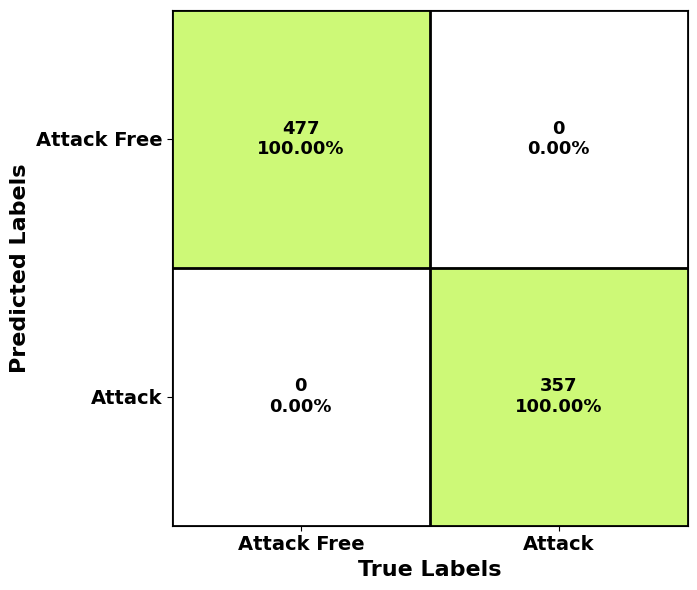

In [283]:
DATA_DIR = "Split_data/Test/Gen/DoS/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.23it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.95it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


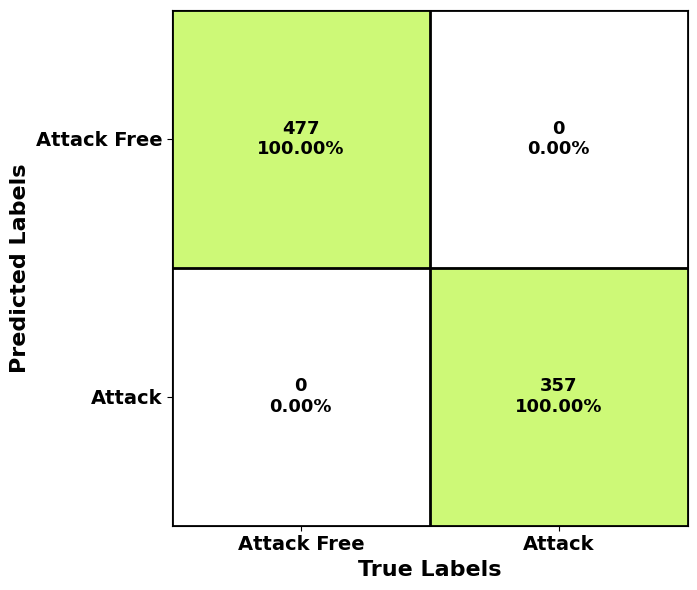

In [284]:
DATA_DIR = "Split_data/Test/Gen/DoS/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.22it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


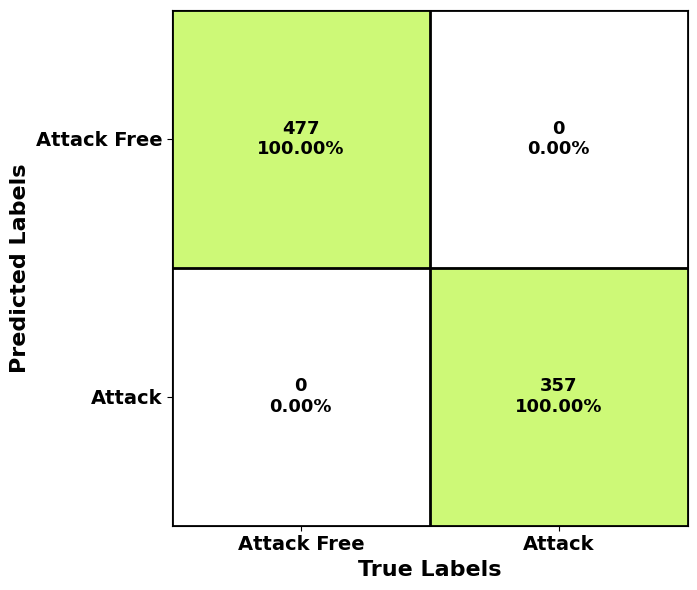

In [285]:
DATA_DIR = "Split_data/Test/Gen/DoS/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.49it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.46it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  9.12it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


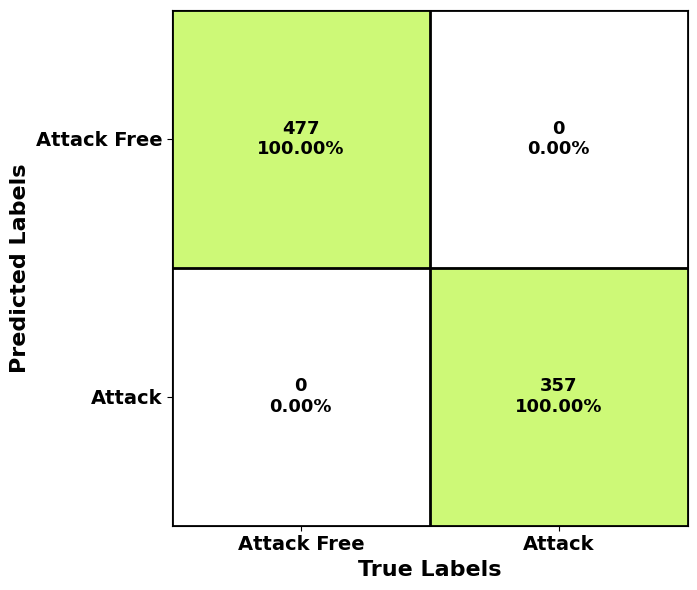

In [286]:
DATA_DIR = "Split_data/Test/Gen/DoS/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Fuzz


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.35it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.40it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  9.00it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9880  (95% CI: 0.9781, 0.9935)
Precision: 1.0000  (95% CI: 0.9891, 1.0000)
Recall   : 0.9720  (95% CI: 0.9492, 0.9847)
F1-score : 0.9858  (95% CI: 0.9762, 0.9941)


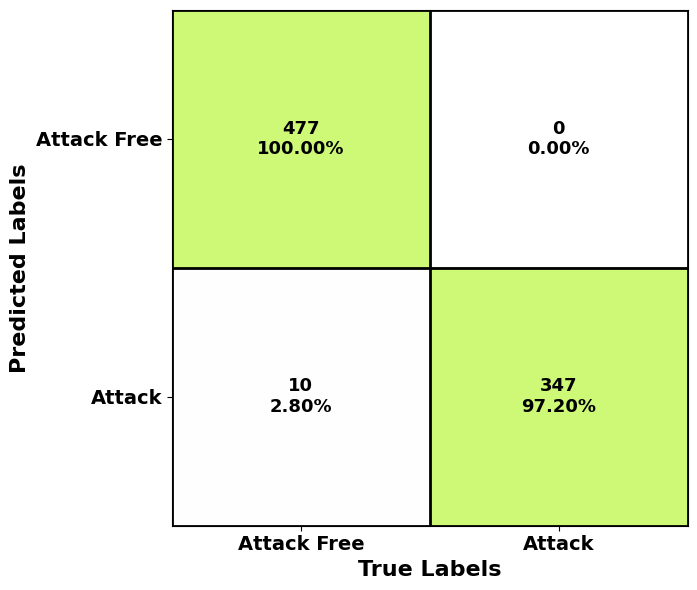

In [287]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.28it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.40it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.98it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


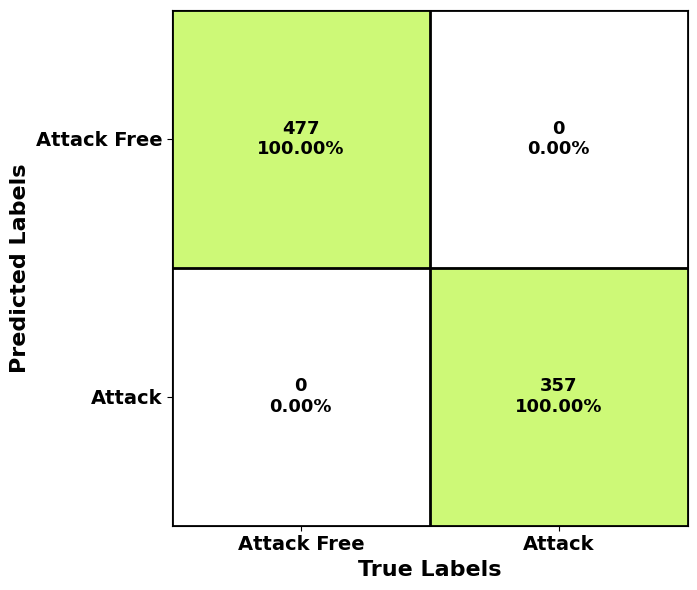

In [288]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.14it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.85it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


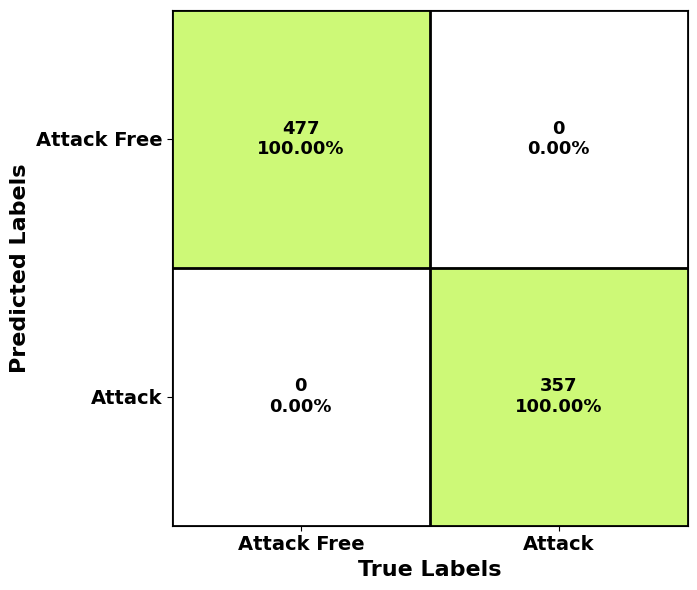

In [289]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.07it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.23it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.94it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


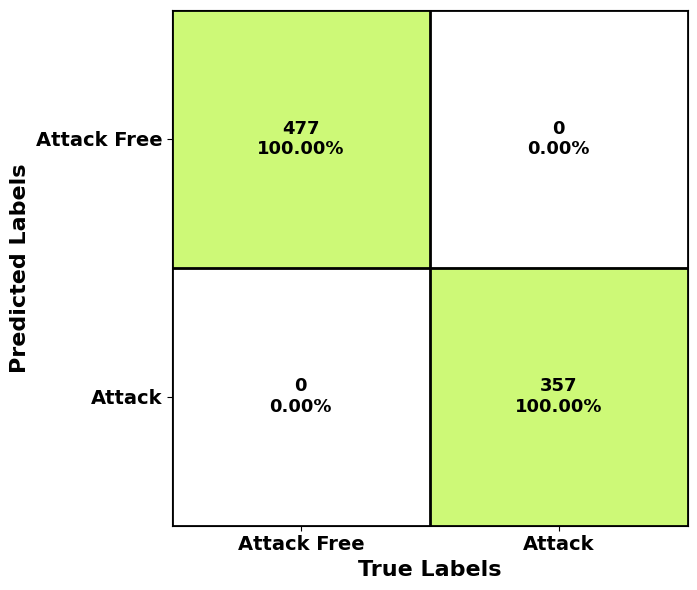

In [290]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.27it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.34it/s]


Total validation samples: 835


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  9.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9988  (95% CI: 0.9932, 0.9998)
Precision: 0.9972  (95% CI: 0.9843, 0.9995)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 0.9986  (95% CI: 0.9957, 1.0000)


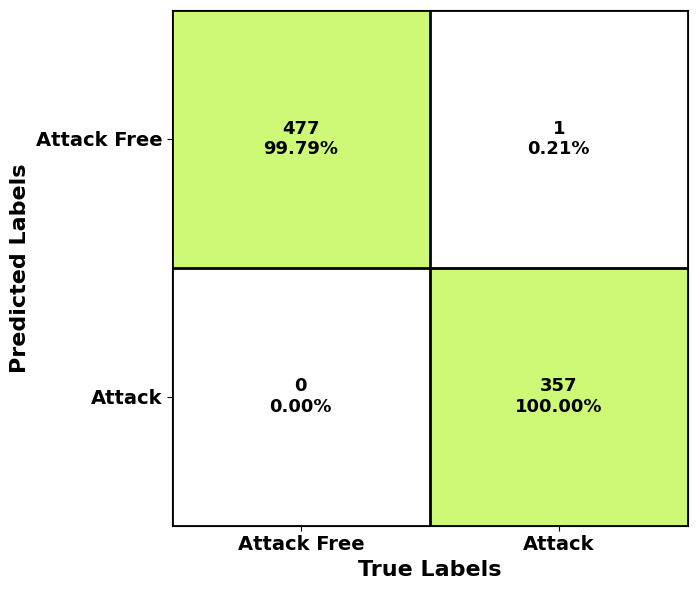

In [291]:
DATA_DIR = "Split_data/Test/Gen/Fuzz/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

## Replay


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  9.06it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 0.9988  (95% CI: 0.9932, 0.9998)
Precision: 1.0000  (95% CI: 0.9893, 1.0000)
Recall   : 0.9972  (95% CI: 0.9843, 0.9995)
F1-score : 0.9986  (95% CI: 0.9955, 1.0000)


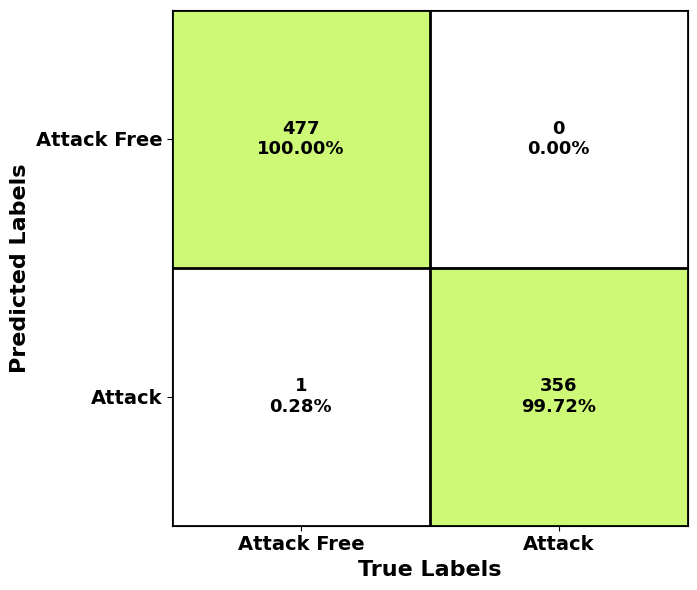

In [292]:
DATA_DIR = "Split_data/Test/Gen/Replay/Lower Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.78it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.98it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


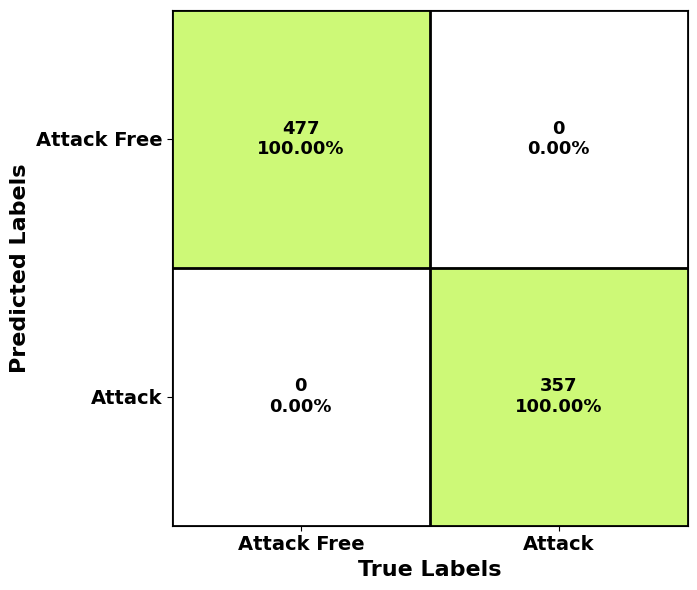

In [293]:
DATA_DIR = "Split_data/Test/Gen/Replay/Low"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.69it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.58it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.89it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


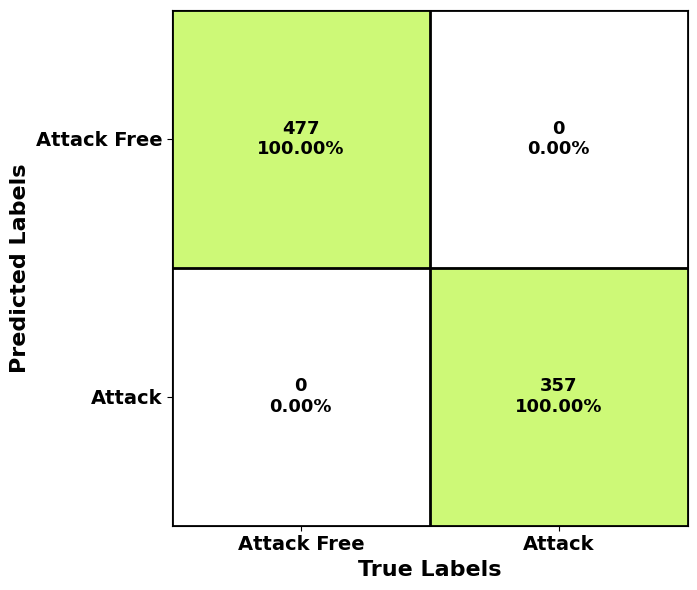

In [294]:
DATA_DIR = "Split_data/Test/Gen/Replay/Medium"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:  50%|█████     | 1/2 [00:00<00:00,  1.52it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.51it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.88it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


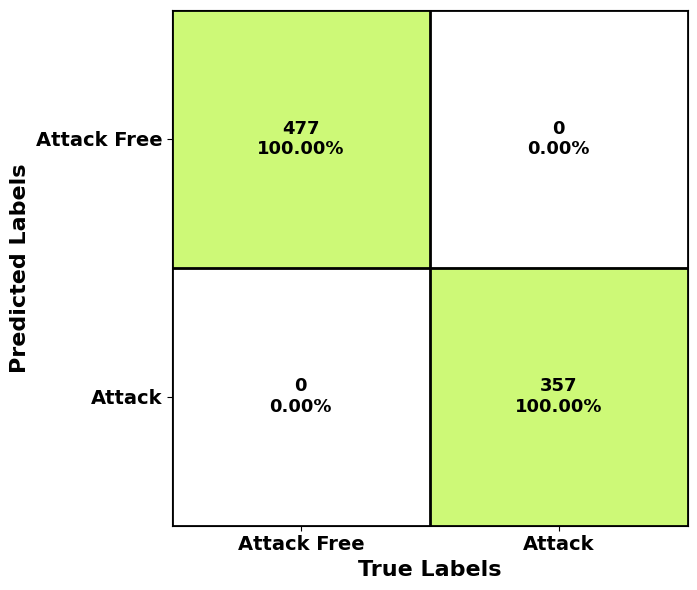

In [295]:
DATA_DIR = "Split_data/Test/Gen/Replay/High"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)


--- Evaluating ONNX Model: SFTSrc/bert/OnnxModels/TrainSilOnnx/model.onnx ---


Loading validation data:   0%|          | 0/2 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS/UIDS-II/utils.py:30: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path)
Loading validation data: 100%|██████████| 2/2 [00:01<00:00,  1.70it/s]


Total validation samples: 834


ONNX Inference: 100%|██████████| 53/53 [00:05<00:00,  8.99it/s]



=== Binary IDS Metrics (ONNX) with 95% CI ===
Accuracy : 1.0000  (95% CI: 0.9954, 1.0000)
Precision: 1.0000  (95% CI: 0.9894, 1.0000)
Recall   : 1.0000  (95% CI: 0.9894, 1.0000)
F1-score : 1.0000  (95% CI: 1.0000, 1.0000)


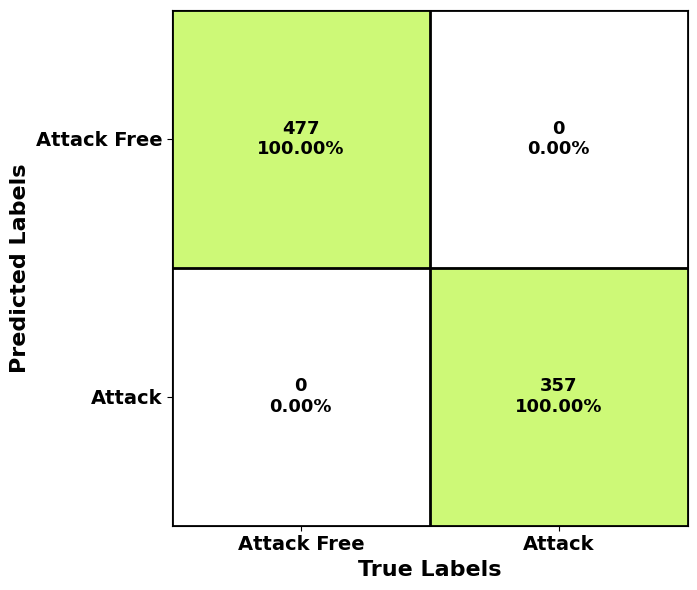

In [296]:
DATA_DIR = "Split_data/Test/Gen/Replay/Random"

results = EvaluateModelOnnx(
    model_path=MODEL_DIR,
    validation_data_directory=DATA_DIR,
    time_gap=TIME_GAP,
    #device=device_to_use,
    batch_size=16
)

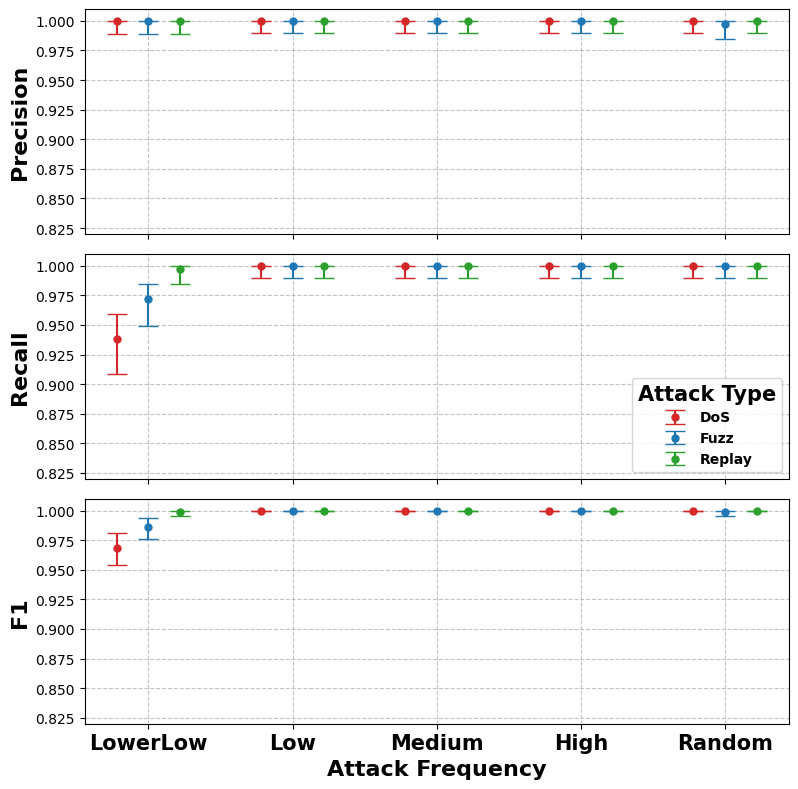

In [298]:
import pandas as pd

data = [
    # ================= DoS =================
    ("DoS","LowerLow","Precision",1.0000,0.9887,1.0000),
    ("DoS","LowerLow","Recall",   0.9384,0.9085,0.9590),
    ("DoS","LowerLow","F1",       0.9682,0.9543,0.9813),

    ("DoS","Low","Precision",1.0000,0.9894,1.0000),
    ("DoS","Low","Recall",   1.0000,0.9894,1.0000),
    ("DoS","Low","F1",       1.0000,1.0000,1.0000),

    ("DoS","Medium","Precision",1.0000,0.9894,1.0000),
    ("DoS","Medium","Recall",   1.0000,0.9894,1.0000),
    ("DoS","Medium","F1",       1.0000,1.0000,1.0000),

    ("DoS","High","Precision",1.0000,0.9894,1.0000),
    ("DoS","High","Recall",   1.0000,0.9894,1.0000),
    ("DoS","High","F1",       1.0000,1.0000,1.0000),

    ("DoS","Random","Precision",1.0000,0.9894,1.0000),
    ("DoS","Random","Recall",   1.0000,0.9894,1.0000),
    ("DoS","Random","F1",       1.0000,1.0000,1.0000),

    # ================= Fuzz =================
    ("Fuzz","LowerLow","Precision",1.0000,0.9891,1.0000),
    ("Fuzz","LowerLow","Recall",   0.9720,0.9492,0.9847),
    ("Fuzz","LowerLow","F1",       0.9858,0.9762,0.9941),

    ("Fuzz","Low","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","Low","Recall",   1.0000,0.9894,1.0000),
    ("Fuzz","Low","F1",       1.0000,1.0000,1.0000),

    ("Fuzz","Medium","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","Medium","Recall",   1.0000,0.9894,1.0000),
    ("Fuzz","Medium","F1",       1.0000,1.0000,1.0000),

    ("Fuzz","High","Precision",1.0000,0.9894,1.0000),
    ("Fuzz","High","Recall",   1.0000,0.9894,1.0000),
    ("Fuzz","High","F1",       1.0000,1.0000,1.0000),

    ("Fuzz","Random","Precision",0.9972,0.9843,0.9995),
    ("Fuzz","Random","Recall",   1.0000,0.9894,1.0000),
    ("Fuzz","Random","F1",       0.9986,0.9957,1.0000),

    # ================= Replay =================
    ("Replay","LowerLow","Precision",1.0000,0.9893,1.0000),
    ("Replay","LowerLow","Recall",   0.9972,0.9843,0.9995),
    ("Replay","LowerLow","F1",       0.9986,0.9955,1.0000),

    ("Replay","Low","Precision",1.0000,0.9894,1.0000),
    ("Replay","Low","Recall",   1.0000,0.9894,1.0000),
    ("Replay","Low","F1",       1.0000,1.0000,1.0000),

    ("Replay","Medium","Precision",1.0000,0.9894,1.0000),
    ("Replay","Medium","Recall",   1.0000,0.9894,1.0000),
    ("Replay","Medium","F1",       1.0000,1.0000,1.0000),

    ("Replay","High","Precision",1.0000,0.9894,1.0000),
    ("Replay","High","Recall",   1.0000,0.9894,1.0000),
    ("Replay","High","F1",       1.0000,1.0000,1.0000),

    ("Replay","Random","Precision",1.0000,0.9894,1.0000),
    ("Replay","Random","Recall",   1.0000,0.9894,1.0000),
    ("Replay","Random","F1",       1.0000,1.0000,1.0000),
]

df = pd.DataFrame(
    data,
    columns=["Attack","Frequency","Metric","Value","CI_L","CI_H"]
)
plot_all_metrics_single_figure(df)